In [56]:
import sys
from pathlib import Path

# Path to the parent folder (where util.py is)
parent_path = Path().resolve().parent.parent  # notebook's parent directory
sys.path.append(str(parent_path))
import util
import pandas as pd
import numpy as np
# import matplotlib.pyplot as plt
import plotting.plotting_style as plt

plt.set_column("half")

file_version = "v2"
data = util.load_data(path_file=f'/Users/maxwernz/development/Data Literacy/data_csv/final_Data_iaaf_scores_neu_{file_version}.csv')  
# data = util.load_data()

# data_adults = data[(data["altersklasse"] == "Frauen") | (data["altersklasse"] == "Maenner")]

In [57]:

disciplines = data['disziplin'].unique()

years = np.sort(data['jahr'].unique())

counts = {}

for d in disciplines:
    counts[d] = []
    for y in years:
        count = len(data[(data['disziplin'] == d) & (data['jahr'] == y)])
        counts[d].append(count)

table = pd.DataFrame(counts, index=years).T  # transpose to have disciplines as rows
table.columns.name = 'jahr'

table

jahr,2001,2002,2003,2004,2005,2006,2007,2008,2009,2010,...,2016,2017,2018,2019,2020,2021,2022,2023,2024,2025
100 m,336,322,327,327,330,303,314,311,355,325,...,341,342,360,360,324,401,402,398,398,404
200 m,298,286,303,307,311,327,278,296,325,316,...,314,331,361,355,323,397,402,401,386,399
400 m,356,355,353,355,353,358,364,363,360,363,...,360,360,357,362,352,391,392,396,390,391
800 m,348,349,344,344,353,350,358,359,356,360,...,357,361,355,363,356,390,391,397,371,381
1500 m,353,352,354,352,352,356,359,358,356,359,...,348,361,351,362,361,401,394,388,375,361
5000 m,237,211,245,236,235,243,251,245,254,247,...,243,259,246,260,254,300,289,293,298,292
10 000 m,127,118,129,131,117,123,128,121,146,132,...,120,152,140,143,120,163,151,153,163,162
10 km,158,159,156,160,157,160,163,159,160,157,...,146,169,158,163,161,199,197,196,201,173
Marathon,98,99,100,99,99,98,101,96,97,98,...,90,105,97,99,89,98,98,77,100,67
100 m Huerden,157,159,140,142,154,165,129,130,152,164,...,160,161,179,179,154,193,194,191,199,196


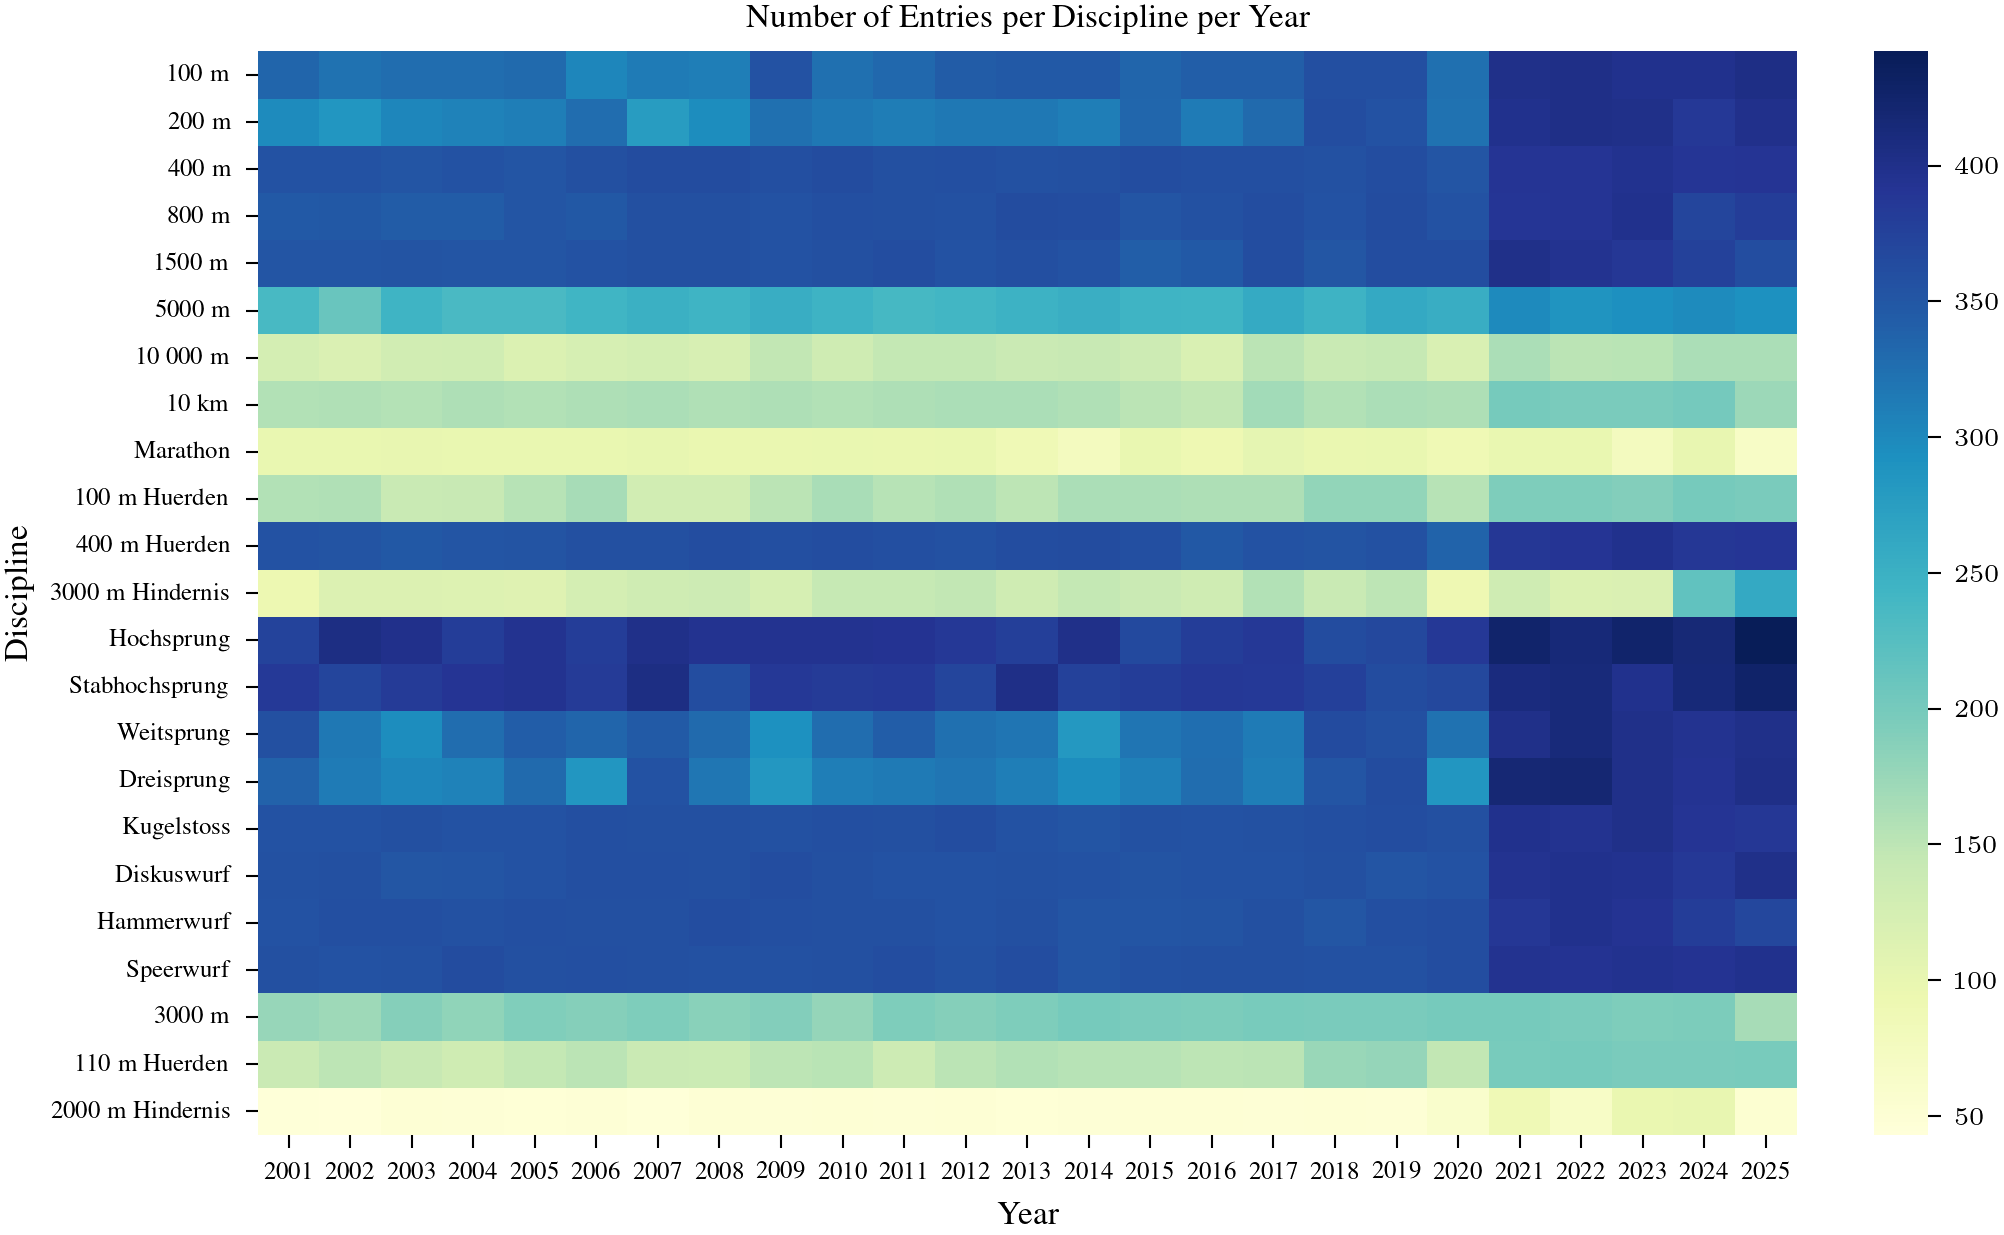

In [58]:
import seaborn as sns
# import matplotlib.pyplot as plt
with plt.rc_context(plt.bundles.icml2024(column="full")):

# plt.figure(figsize=(10, 8))

# Draw heatmap
    ax = ax = sns.heatmap(table, fmt="d", cmap="YlGnBu")
    ax.set_yticks(np.arange(len(table.index)) + 0.5)  # Position der Labels korrigieren
    ax.set_yticklabels(table.index, rotation=0)       # Namen anzeigen, horizontal

    plt.title("Number of Entries per Discipline per Year")
    plt.ylabel("Discipline")
    plt.xlabel("Year")
    plt.savefig(f"performance_counts_all_years_{file_version}", category="Performance Counts")
    plt.show()

In [34]:
def plot_heatmap_counts(target_year, df, save=False):
    # 1. Daten filtern
    df_year = df[df['jahr'] == target_year].copy()
    
    if df_year.empty:
        print(f"Keine Daten für das Jahr {target_year} gefunden.")
        return

    # 2. Pivot Tabelle erstellen (Zählen der Einträge)
    # Zeilen: Disziplin, Spalten: Altersklasse
    pivot_table = df_year.groupby(['altersklasse', 'geschlecht', 'disziplin']).size().unstack(fill_value=0)
    
    # Daten extrahieren
    data = pivot_table.values
    disciplines = pivot_table.index.tolist()
    age_groups = pivot_table.columns.tolist()

    # 3. Plotten
    # Höhe dynamisch anpassen, damit nichts gequetscht wird
    with plt.rc_context(plt.increase_figsize(0.75)):
        fig, ax = plt.subplots()
        
        # Die Heatmap
        im = ax.imshow(data, cmap='YlOrRd', aspect='auto', interpolation='nearest')

        # Colorbar hinzufügen
        cbar = ax.figure.colorbar(im, ax=ax)
        cbar.ax.set_ylabel("Anzahl der Einträge", rotation=-90, va="bottom")

        # Achsenbeschriftungen setzen
        ax.set_xticks(np.arange(len(age_groups)))
        ax.set_yticks(np.arange(len(disciplines)))
        ax.set_xticklabels(age_groups)
        ax.set_yticklabels(disciplines)

        # X-Achsen Labels rotieren für bessere Lesbarkeit
        plt.setp(ax.get_xticklabels(), rotation=45, ha="right", rotation_mode="anchor")

        # 4. Zahlen in die Kästchen schreiben
        # Schwellenwert für Textfarbe (weiß auf dunkel, schwarz auf hell)
        threshold = data.max() / 2.
        
        for i in range(len(disciplines)):
            for j in range(len(age_groups)):
                val = data[i, j]
                # Farbe anpassen je nach Hintergrund
                color = "white" if val > threshold else "black"
                # Text einfügen
                text = ax.text(j, i, val,
                            ha="center", va="center", color=color, fontweight='bold')

        ax.set_title(f"{target_year}")
        # ax.set_xlabel("Altersklasse")
        # ax.set_ylabel("Disziplin")
        
        if save:
            plt.savefig(f"performance_counts_{target_year}", category="Performance Counts")
        plt.show()

In [ ]:
data = util.load_data(path_file='../../data_csv/final_Data_iaaf_scores_neu_v3.csv')

for year in data['jahr'].unique():
    plot_heatmap_counts(year, data, save=True) 

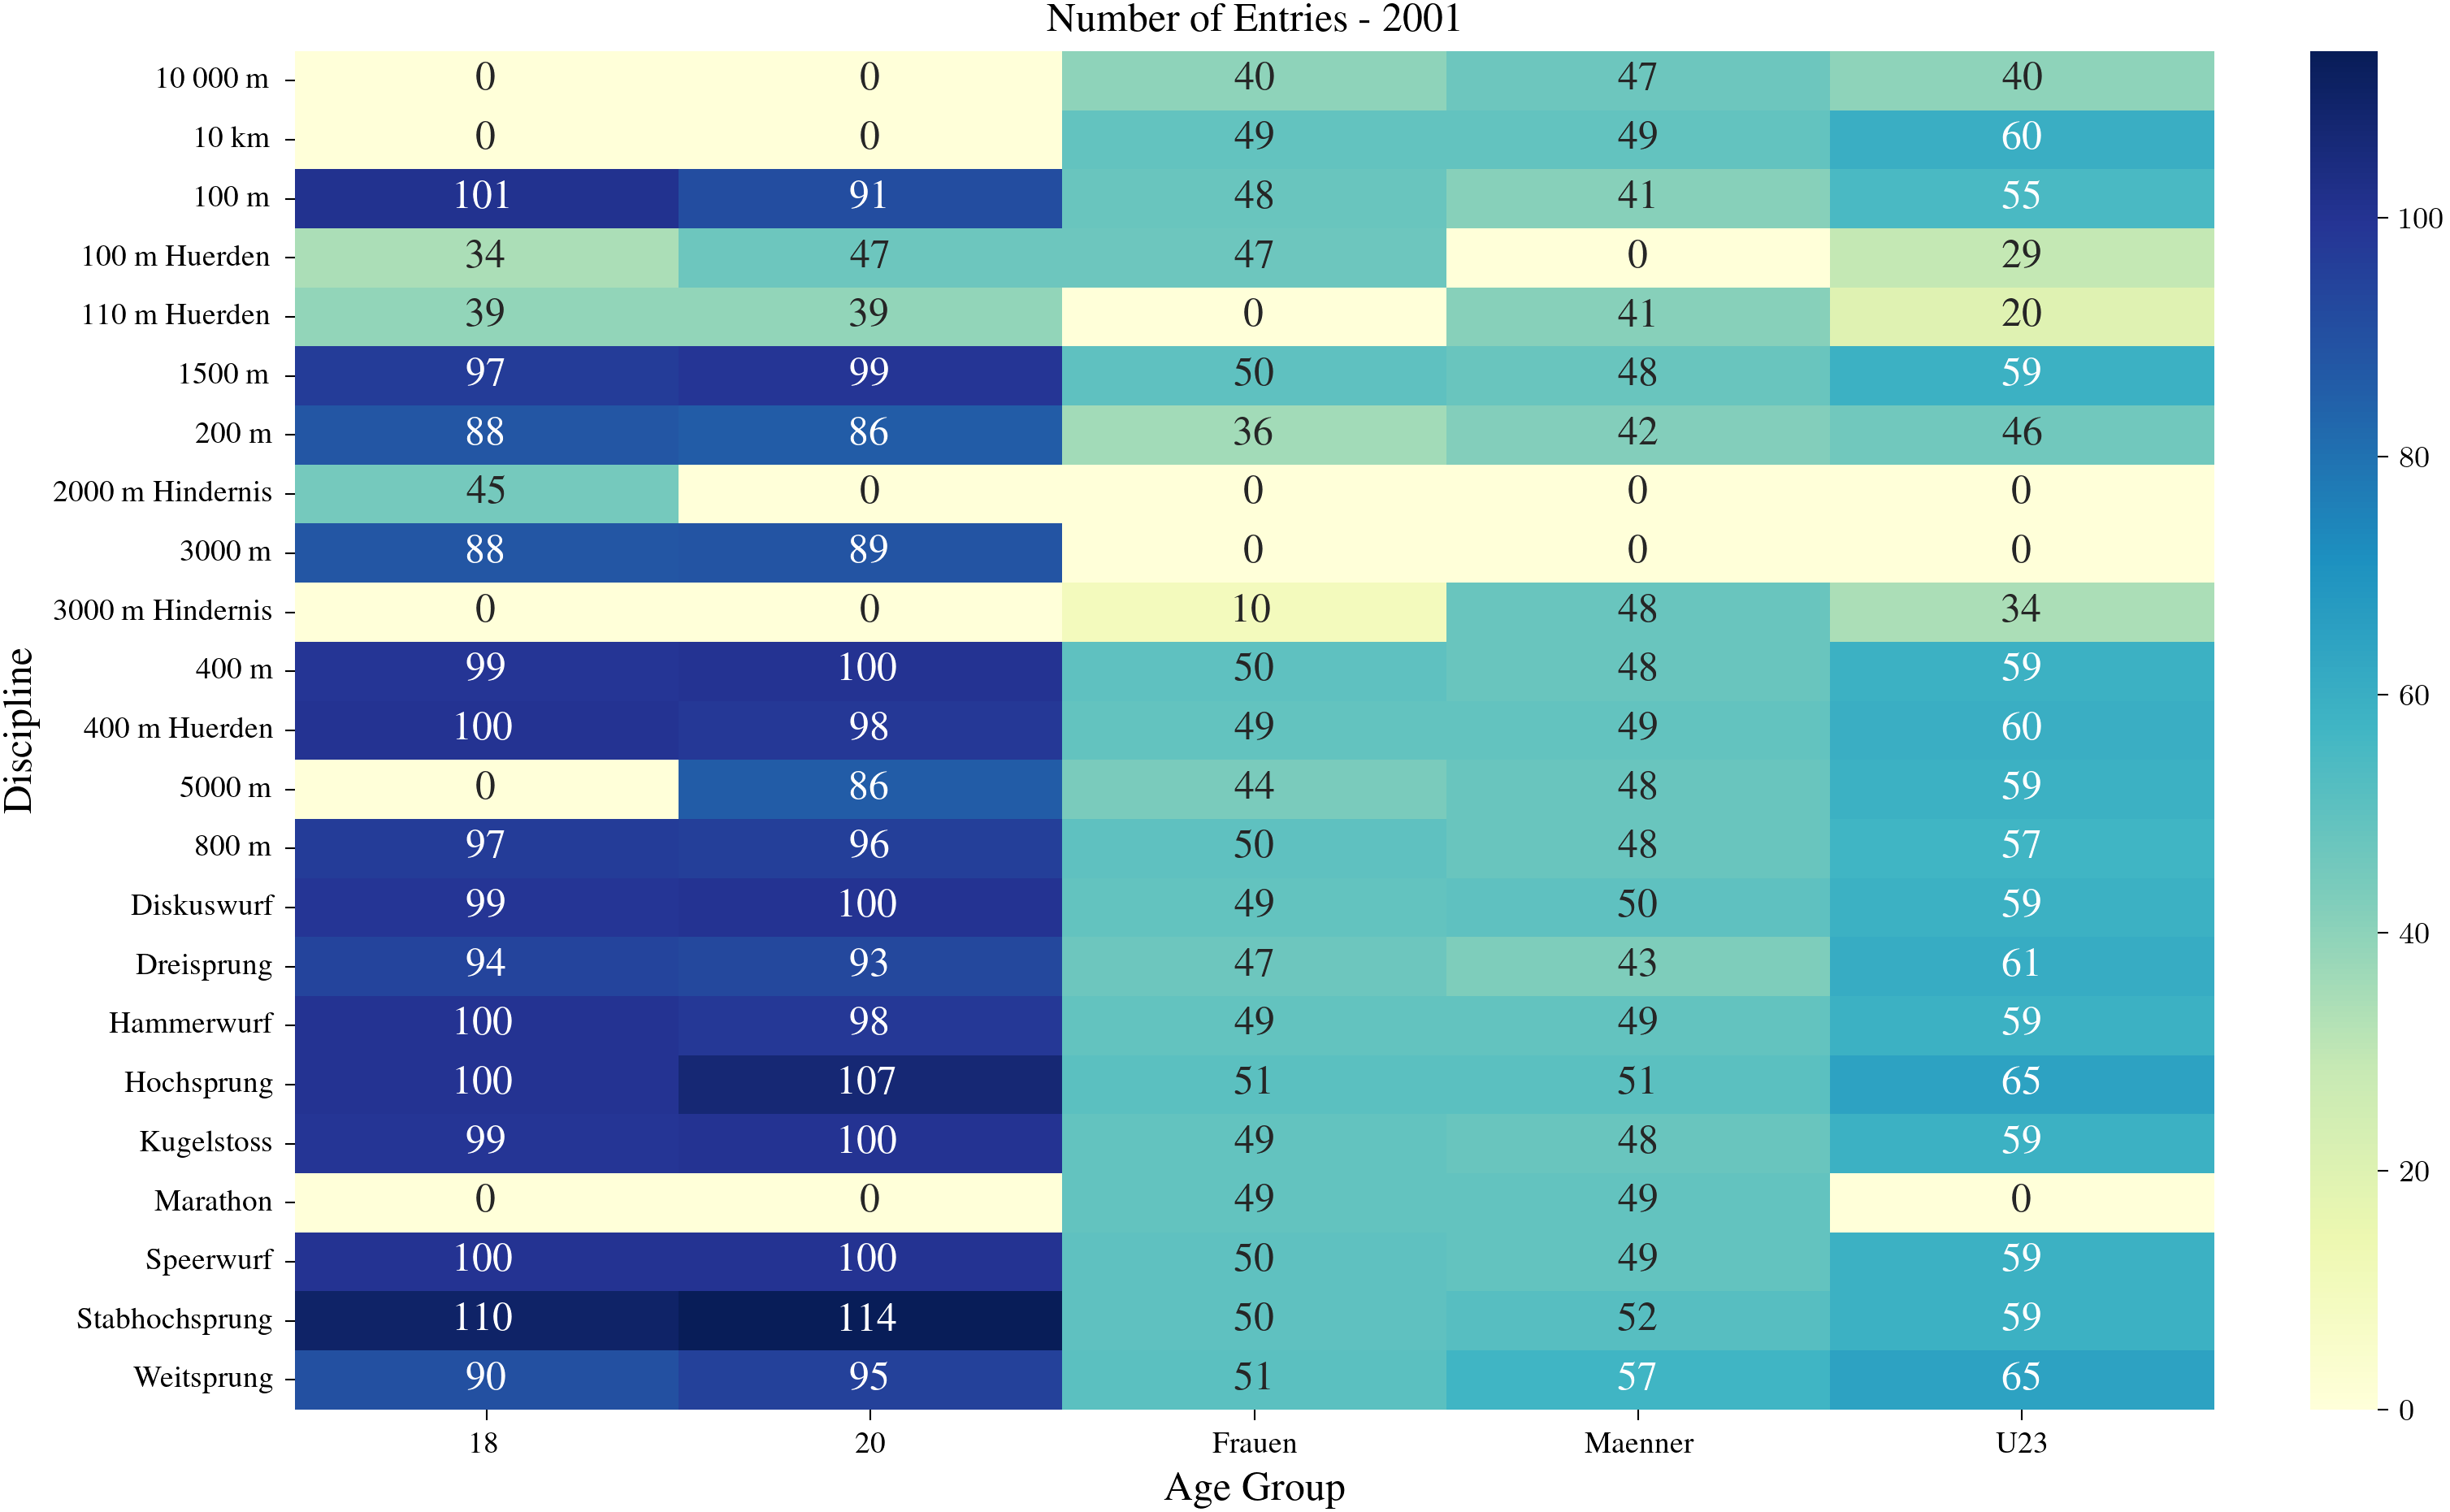

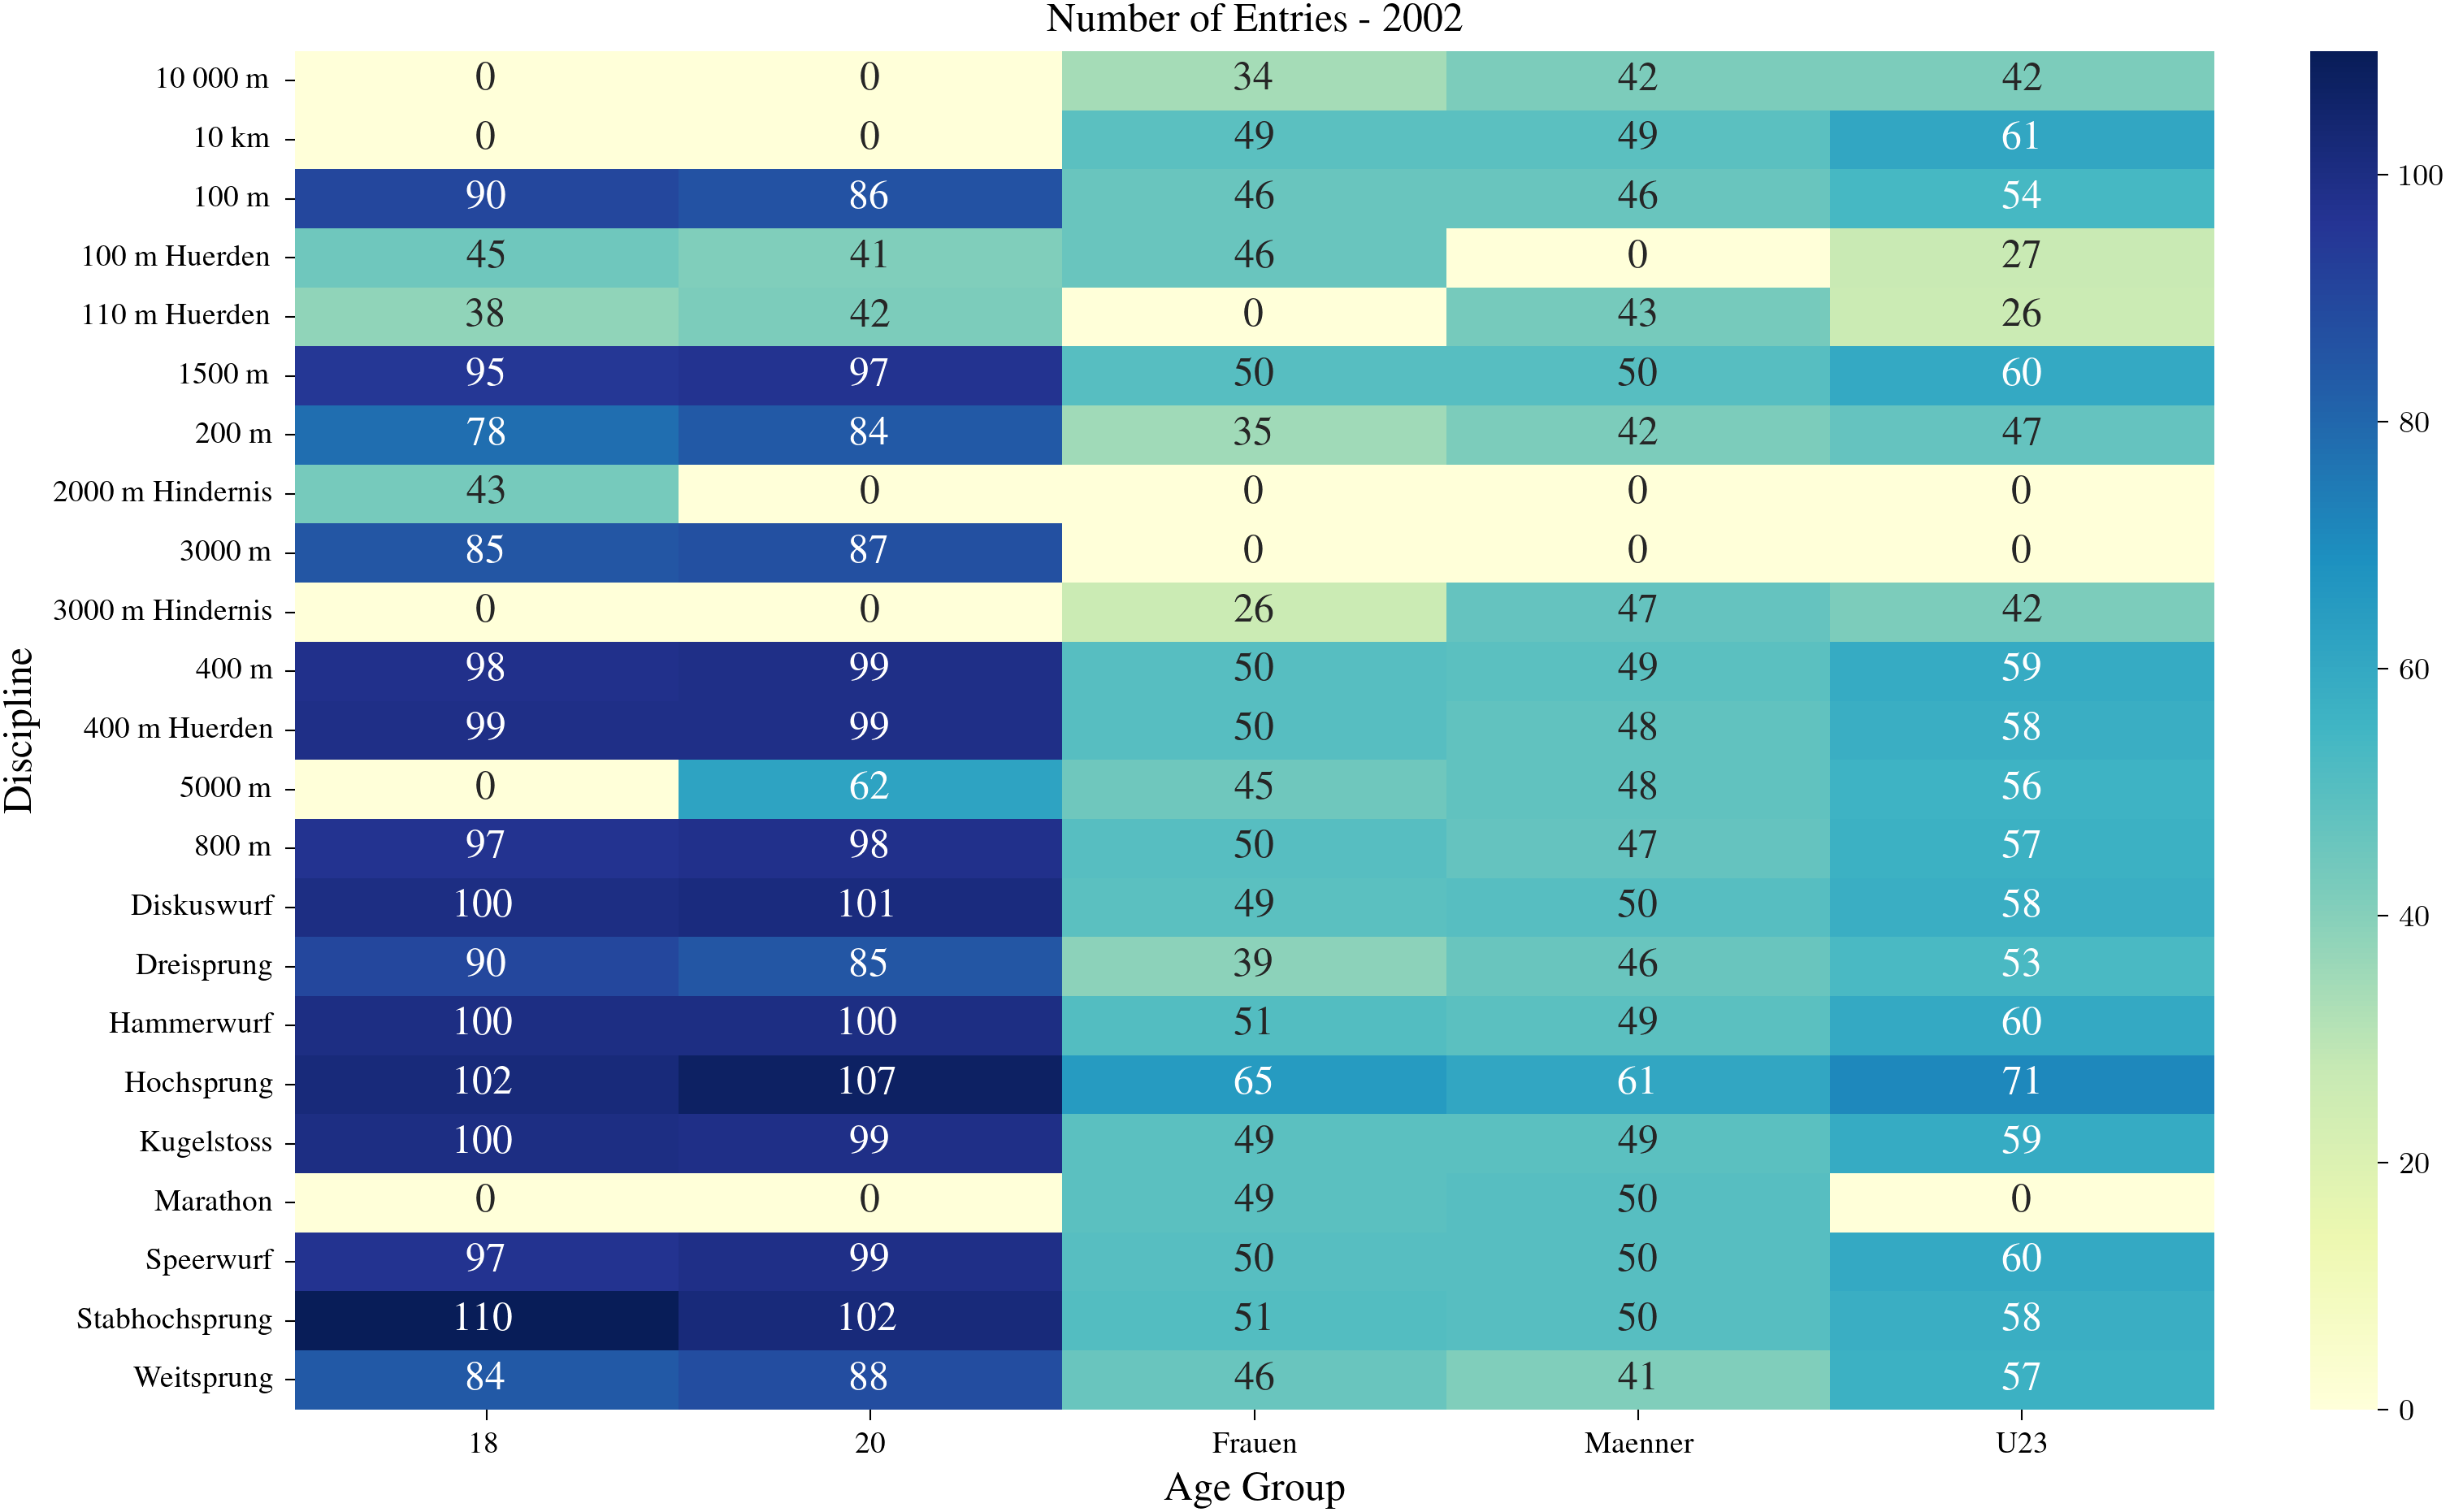

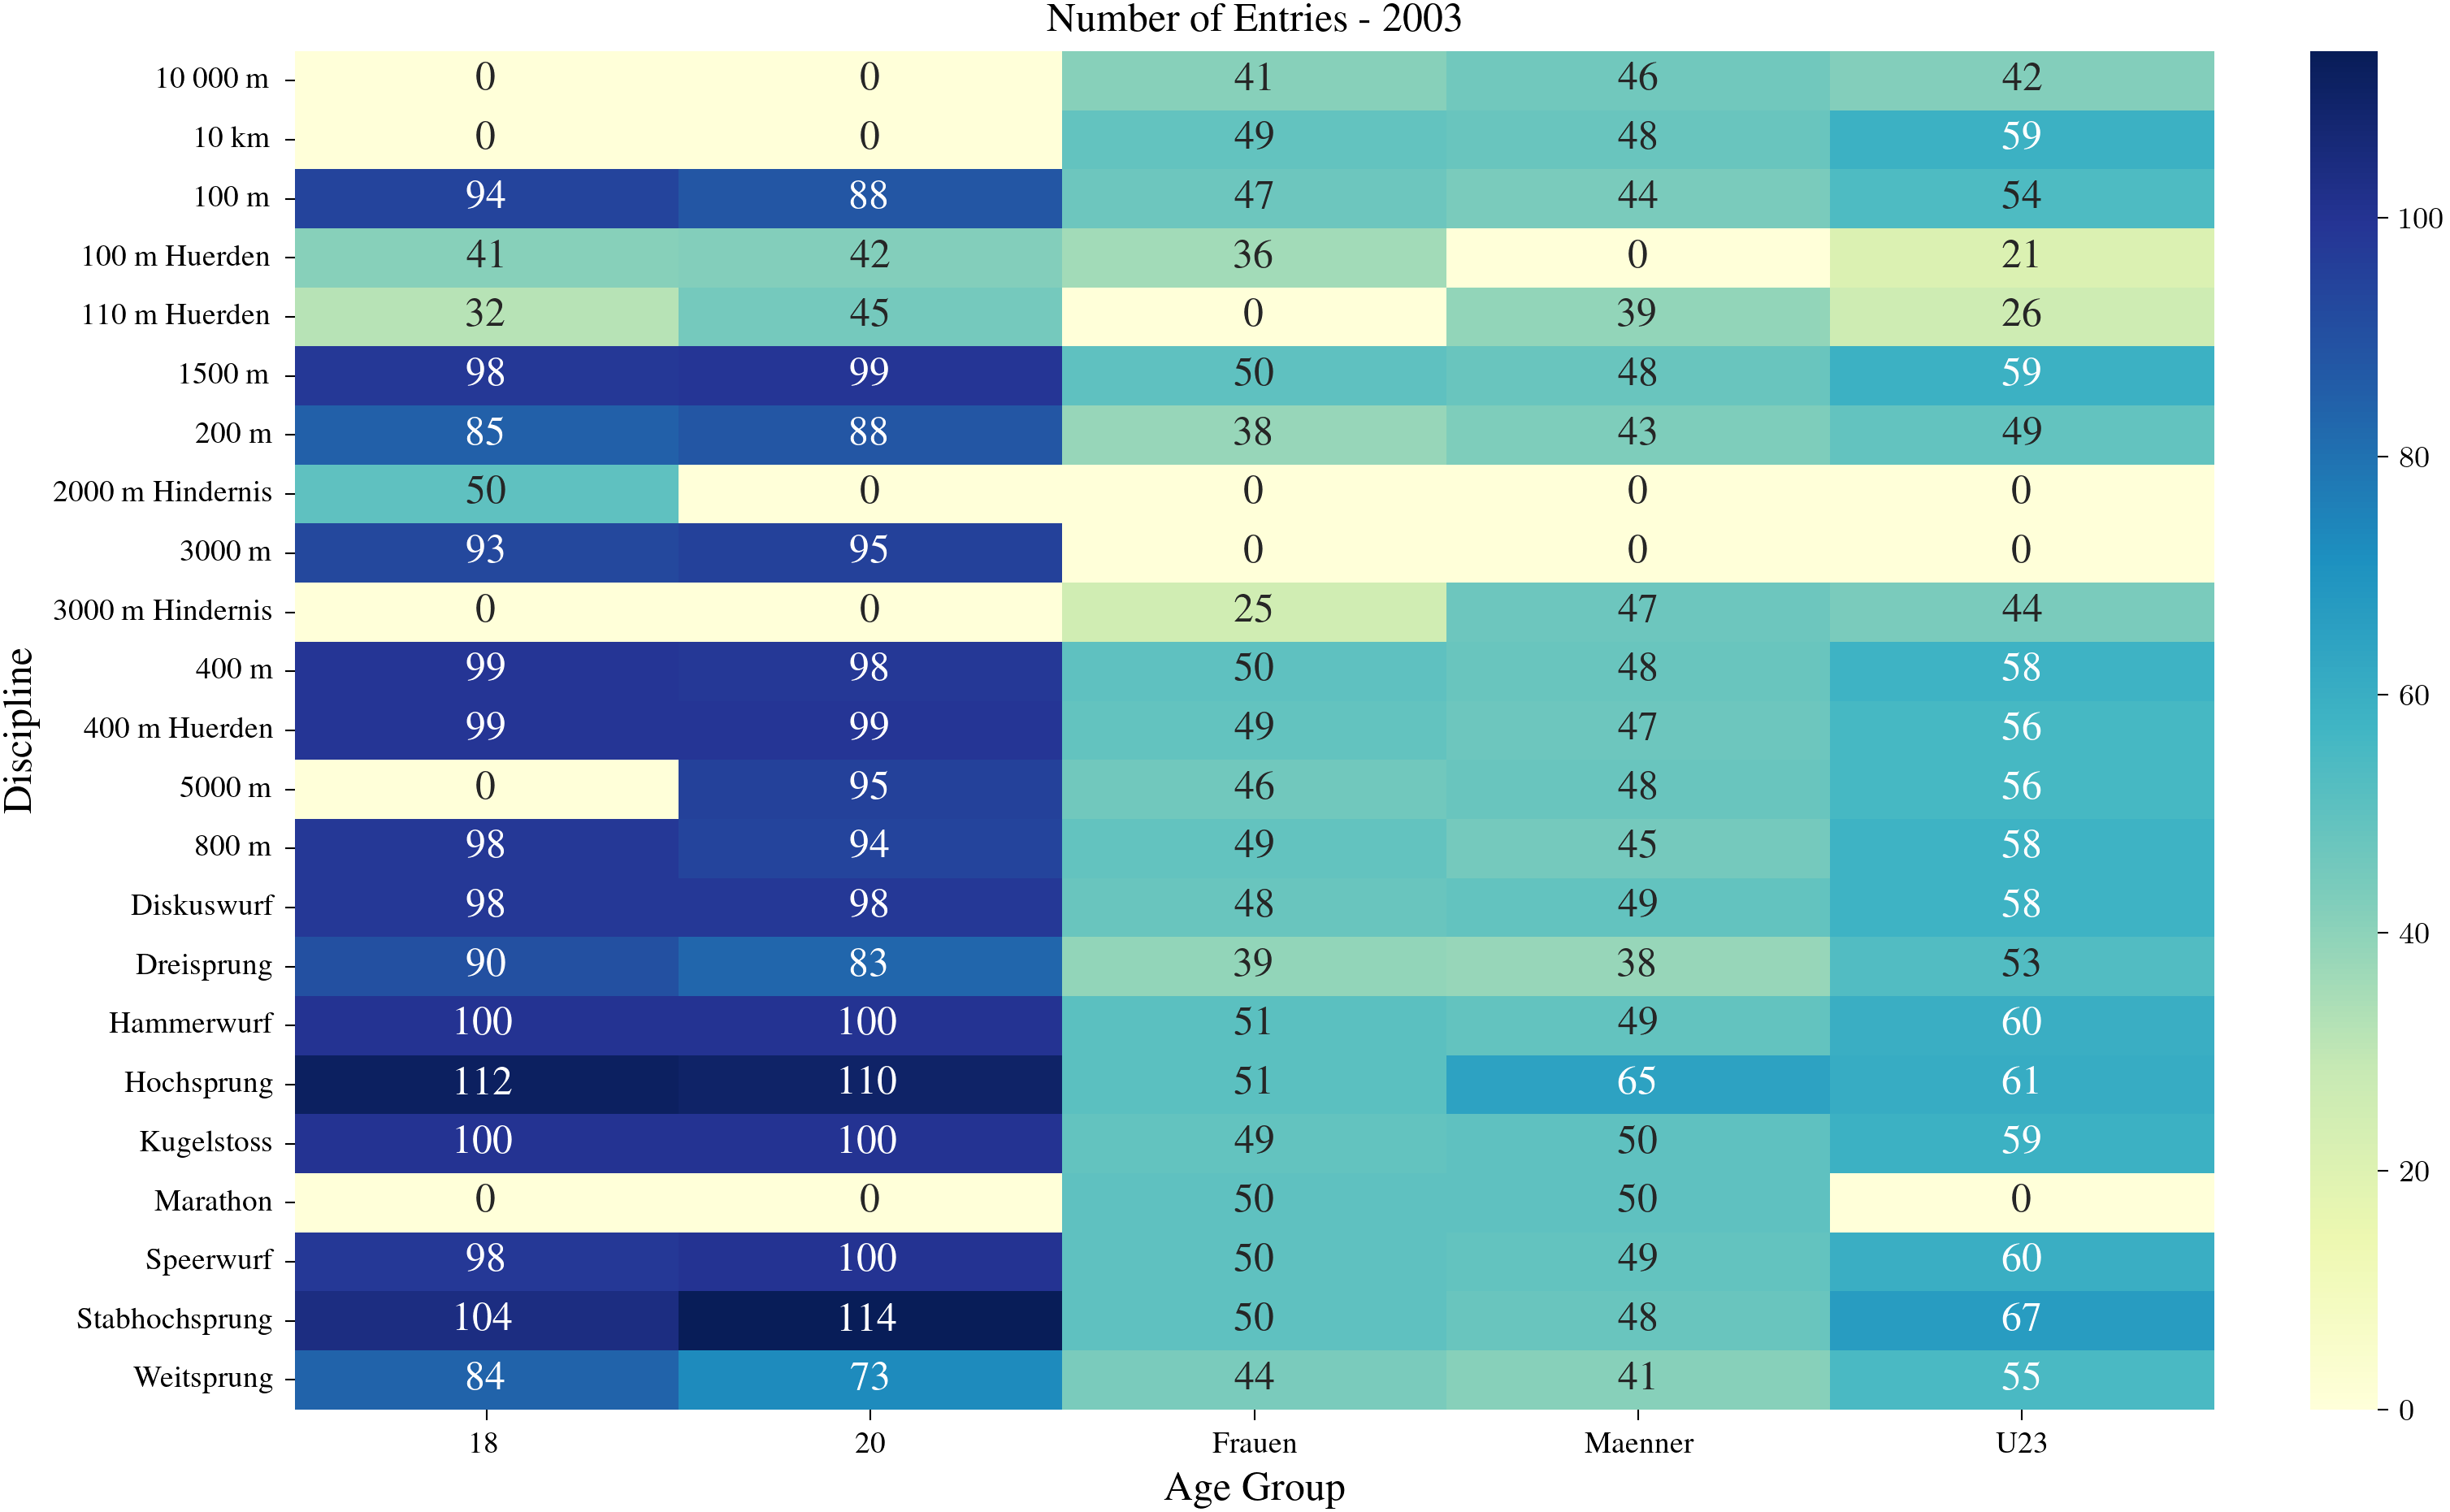

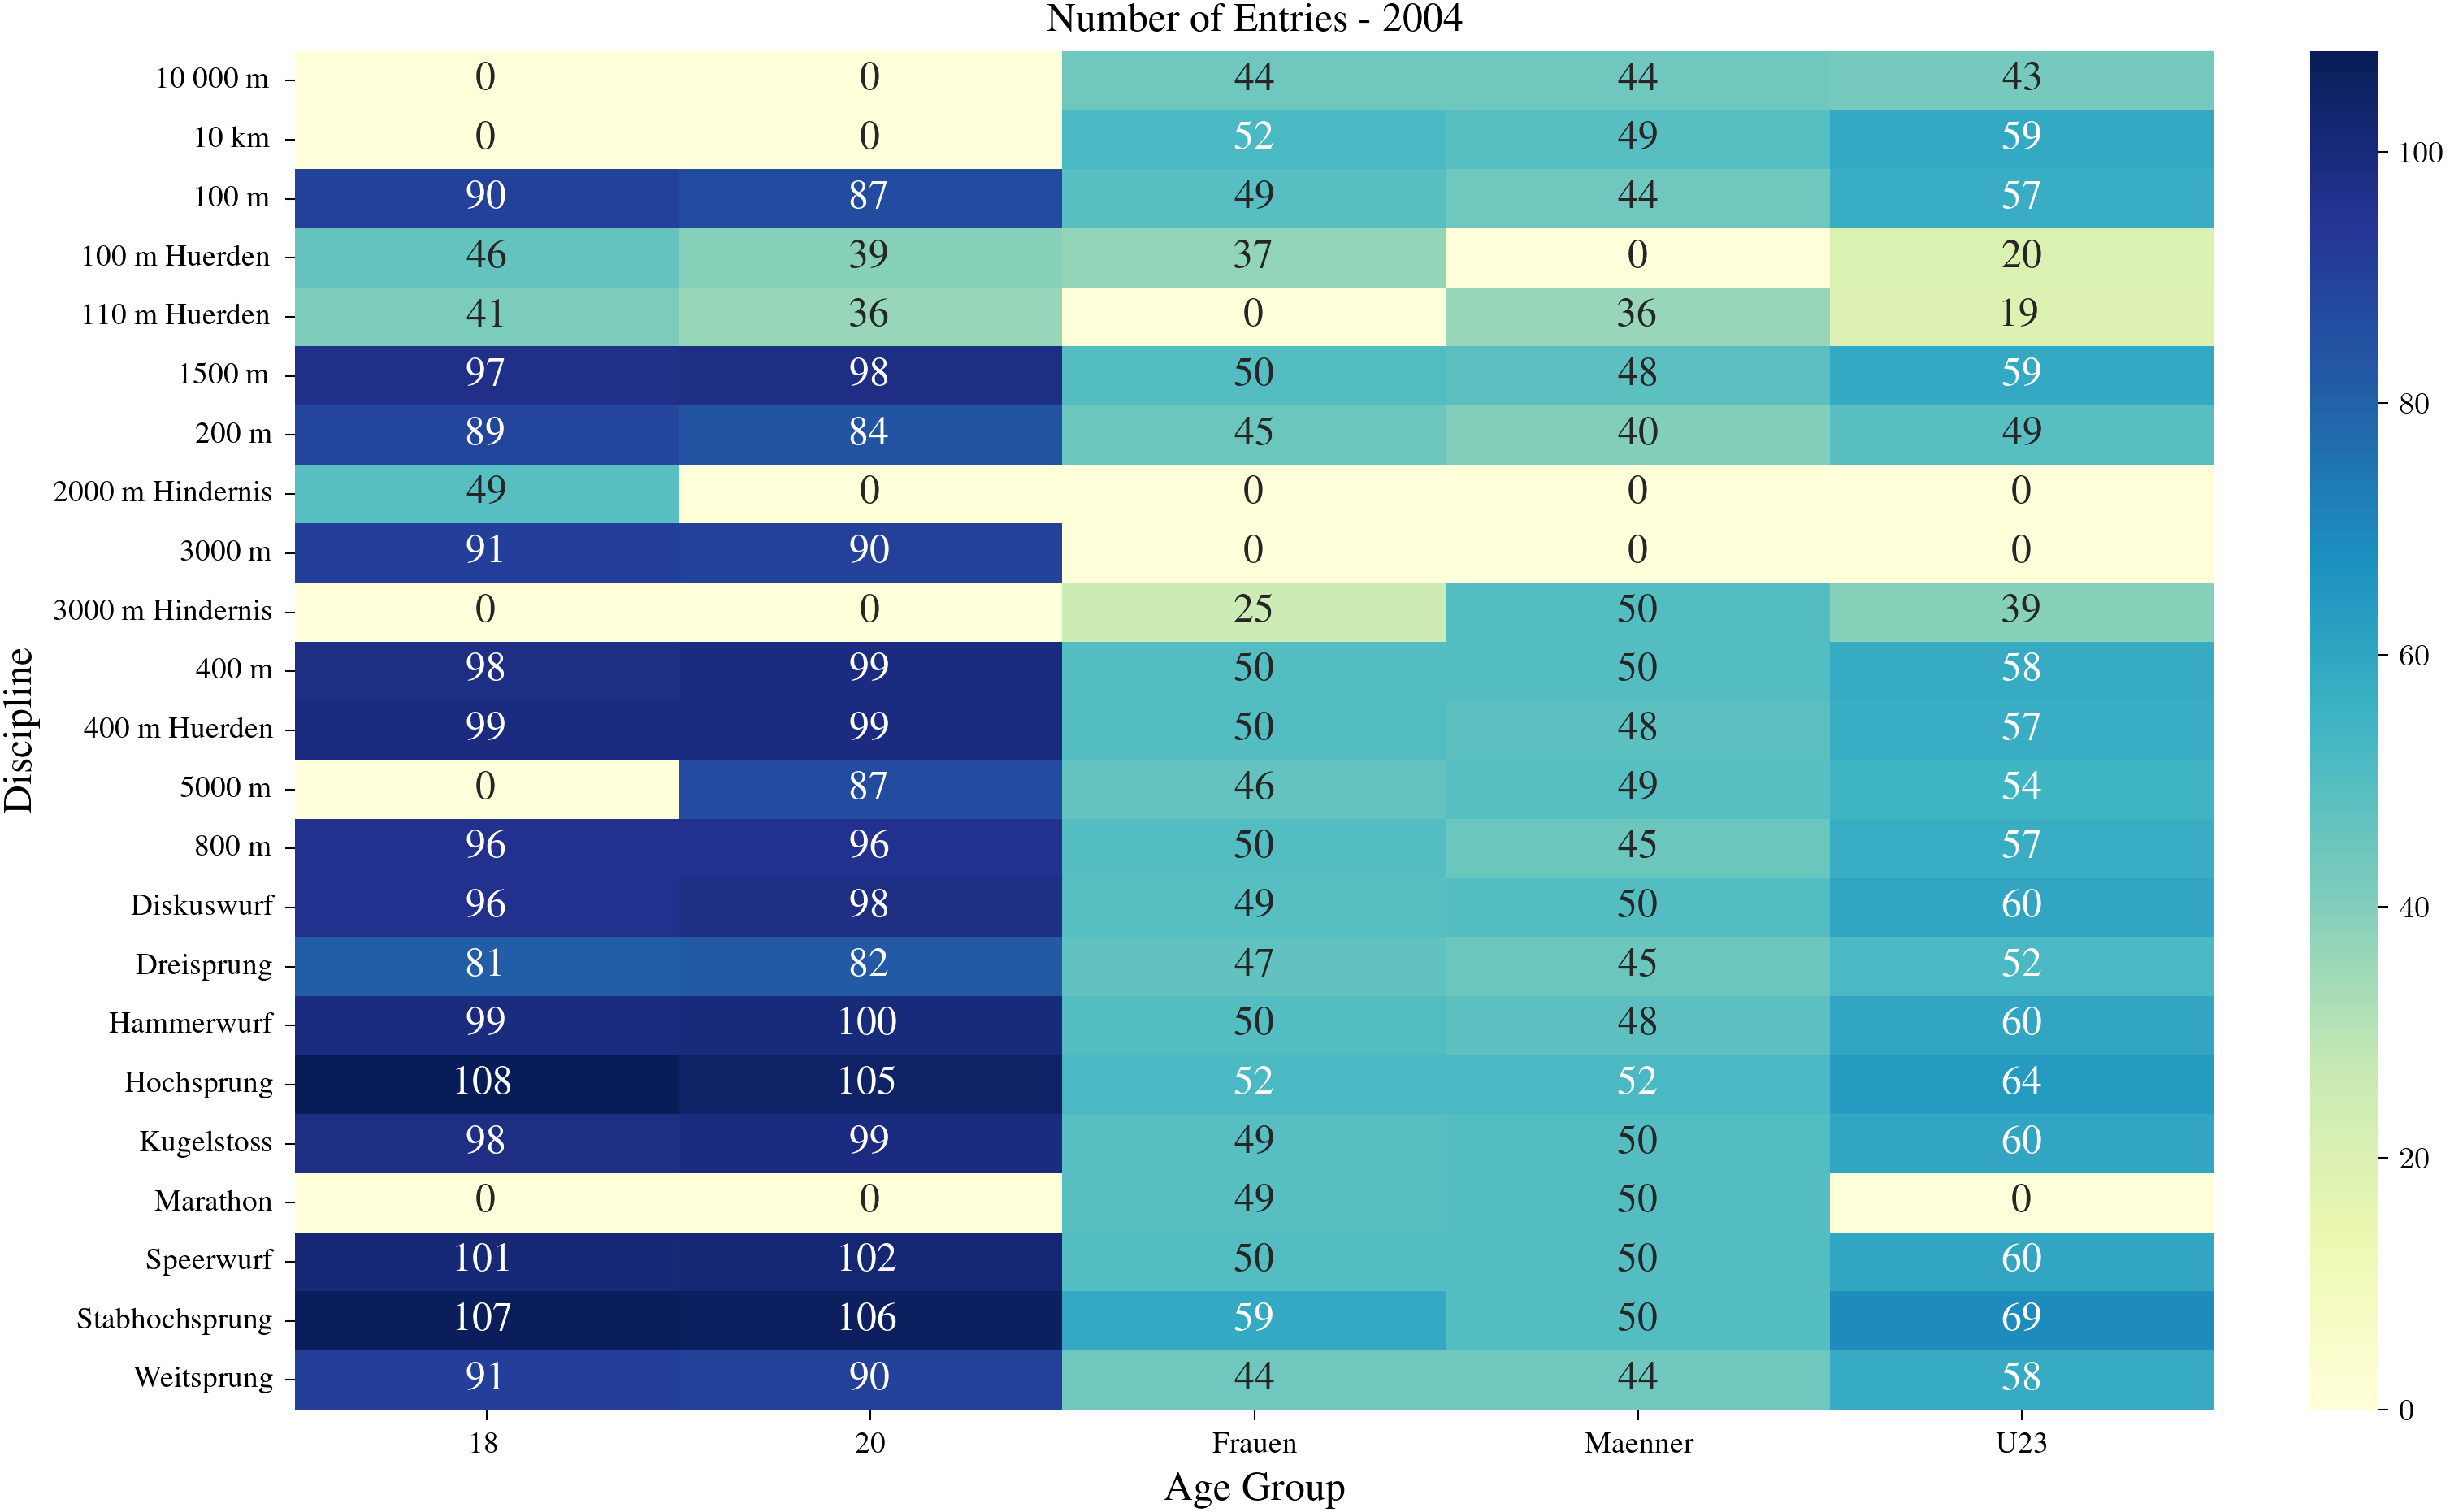

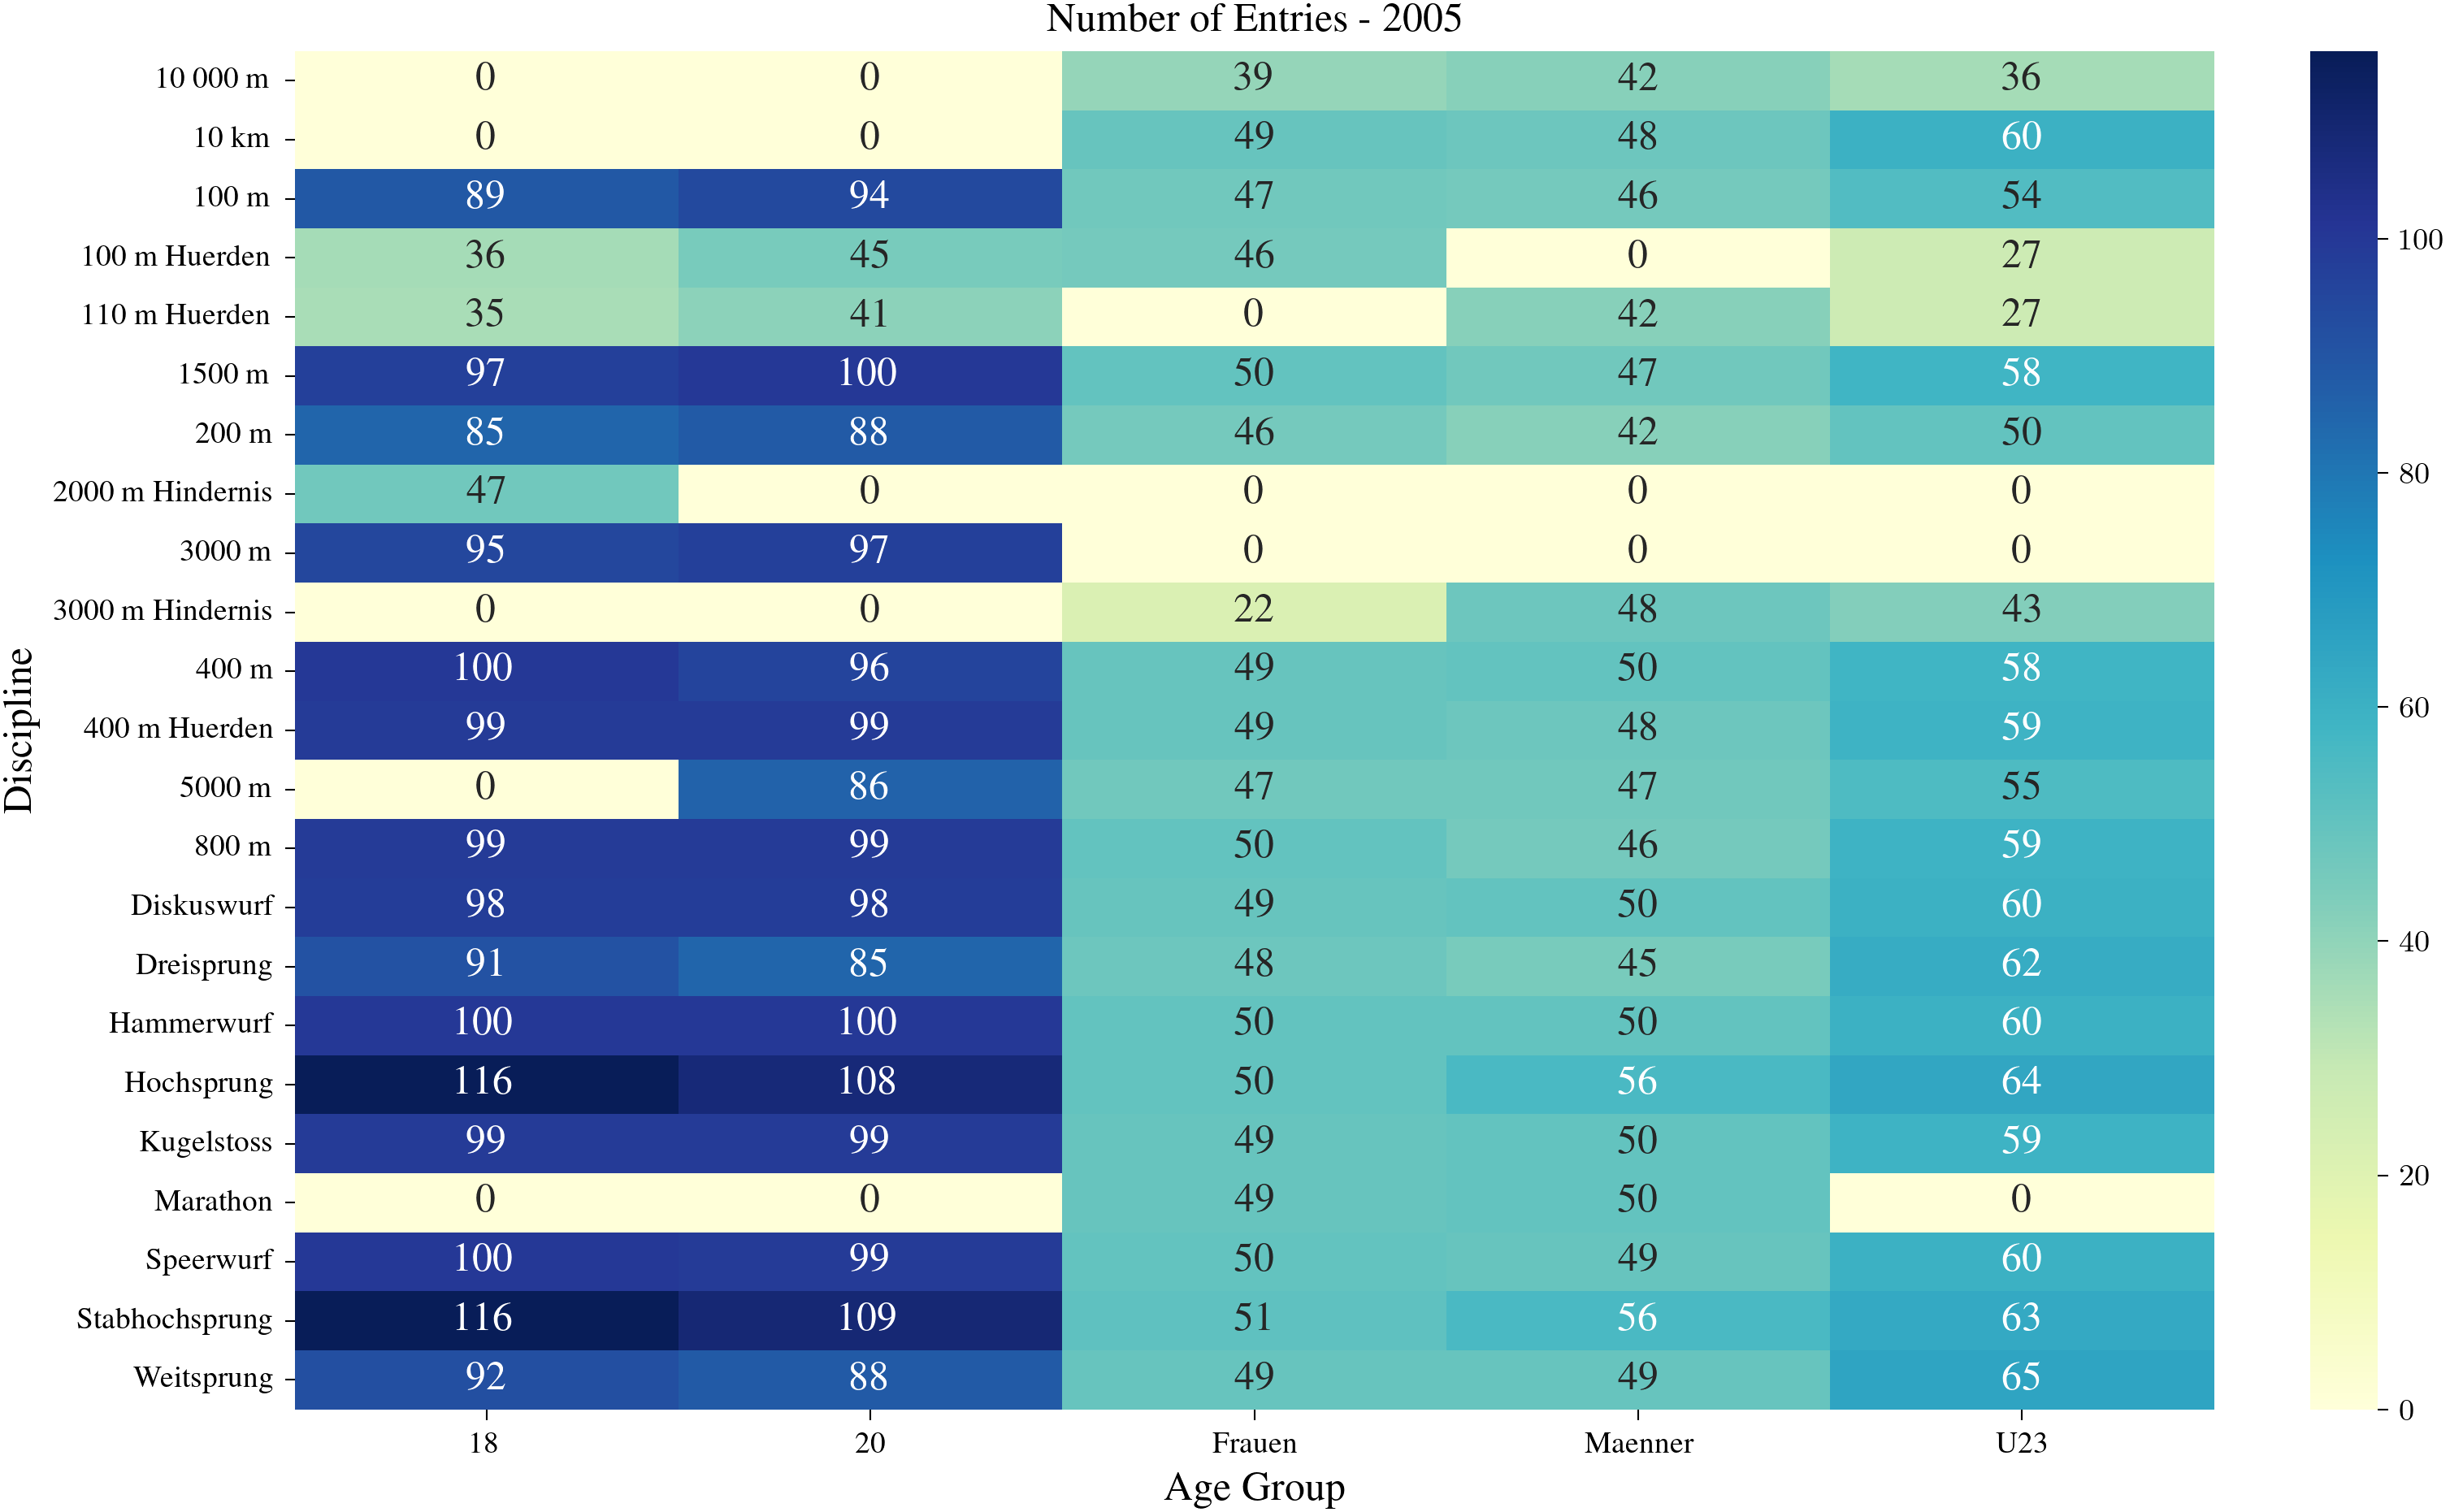

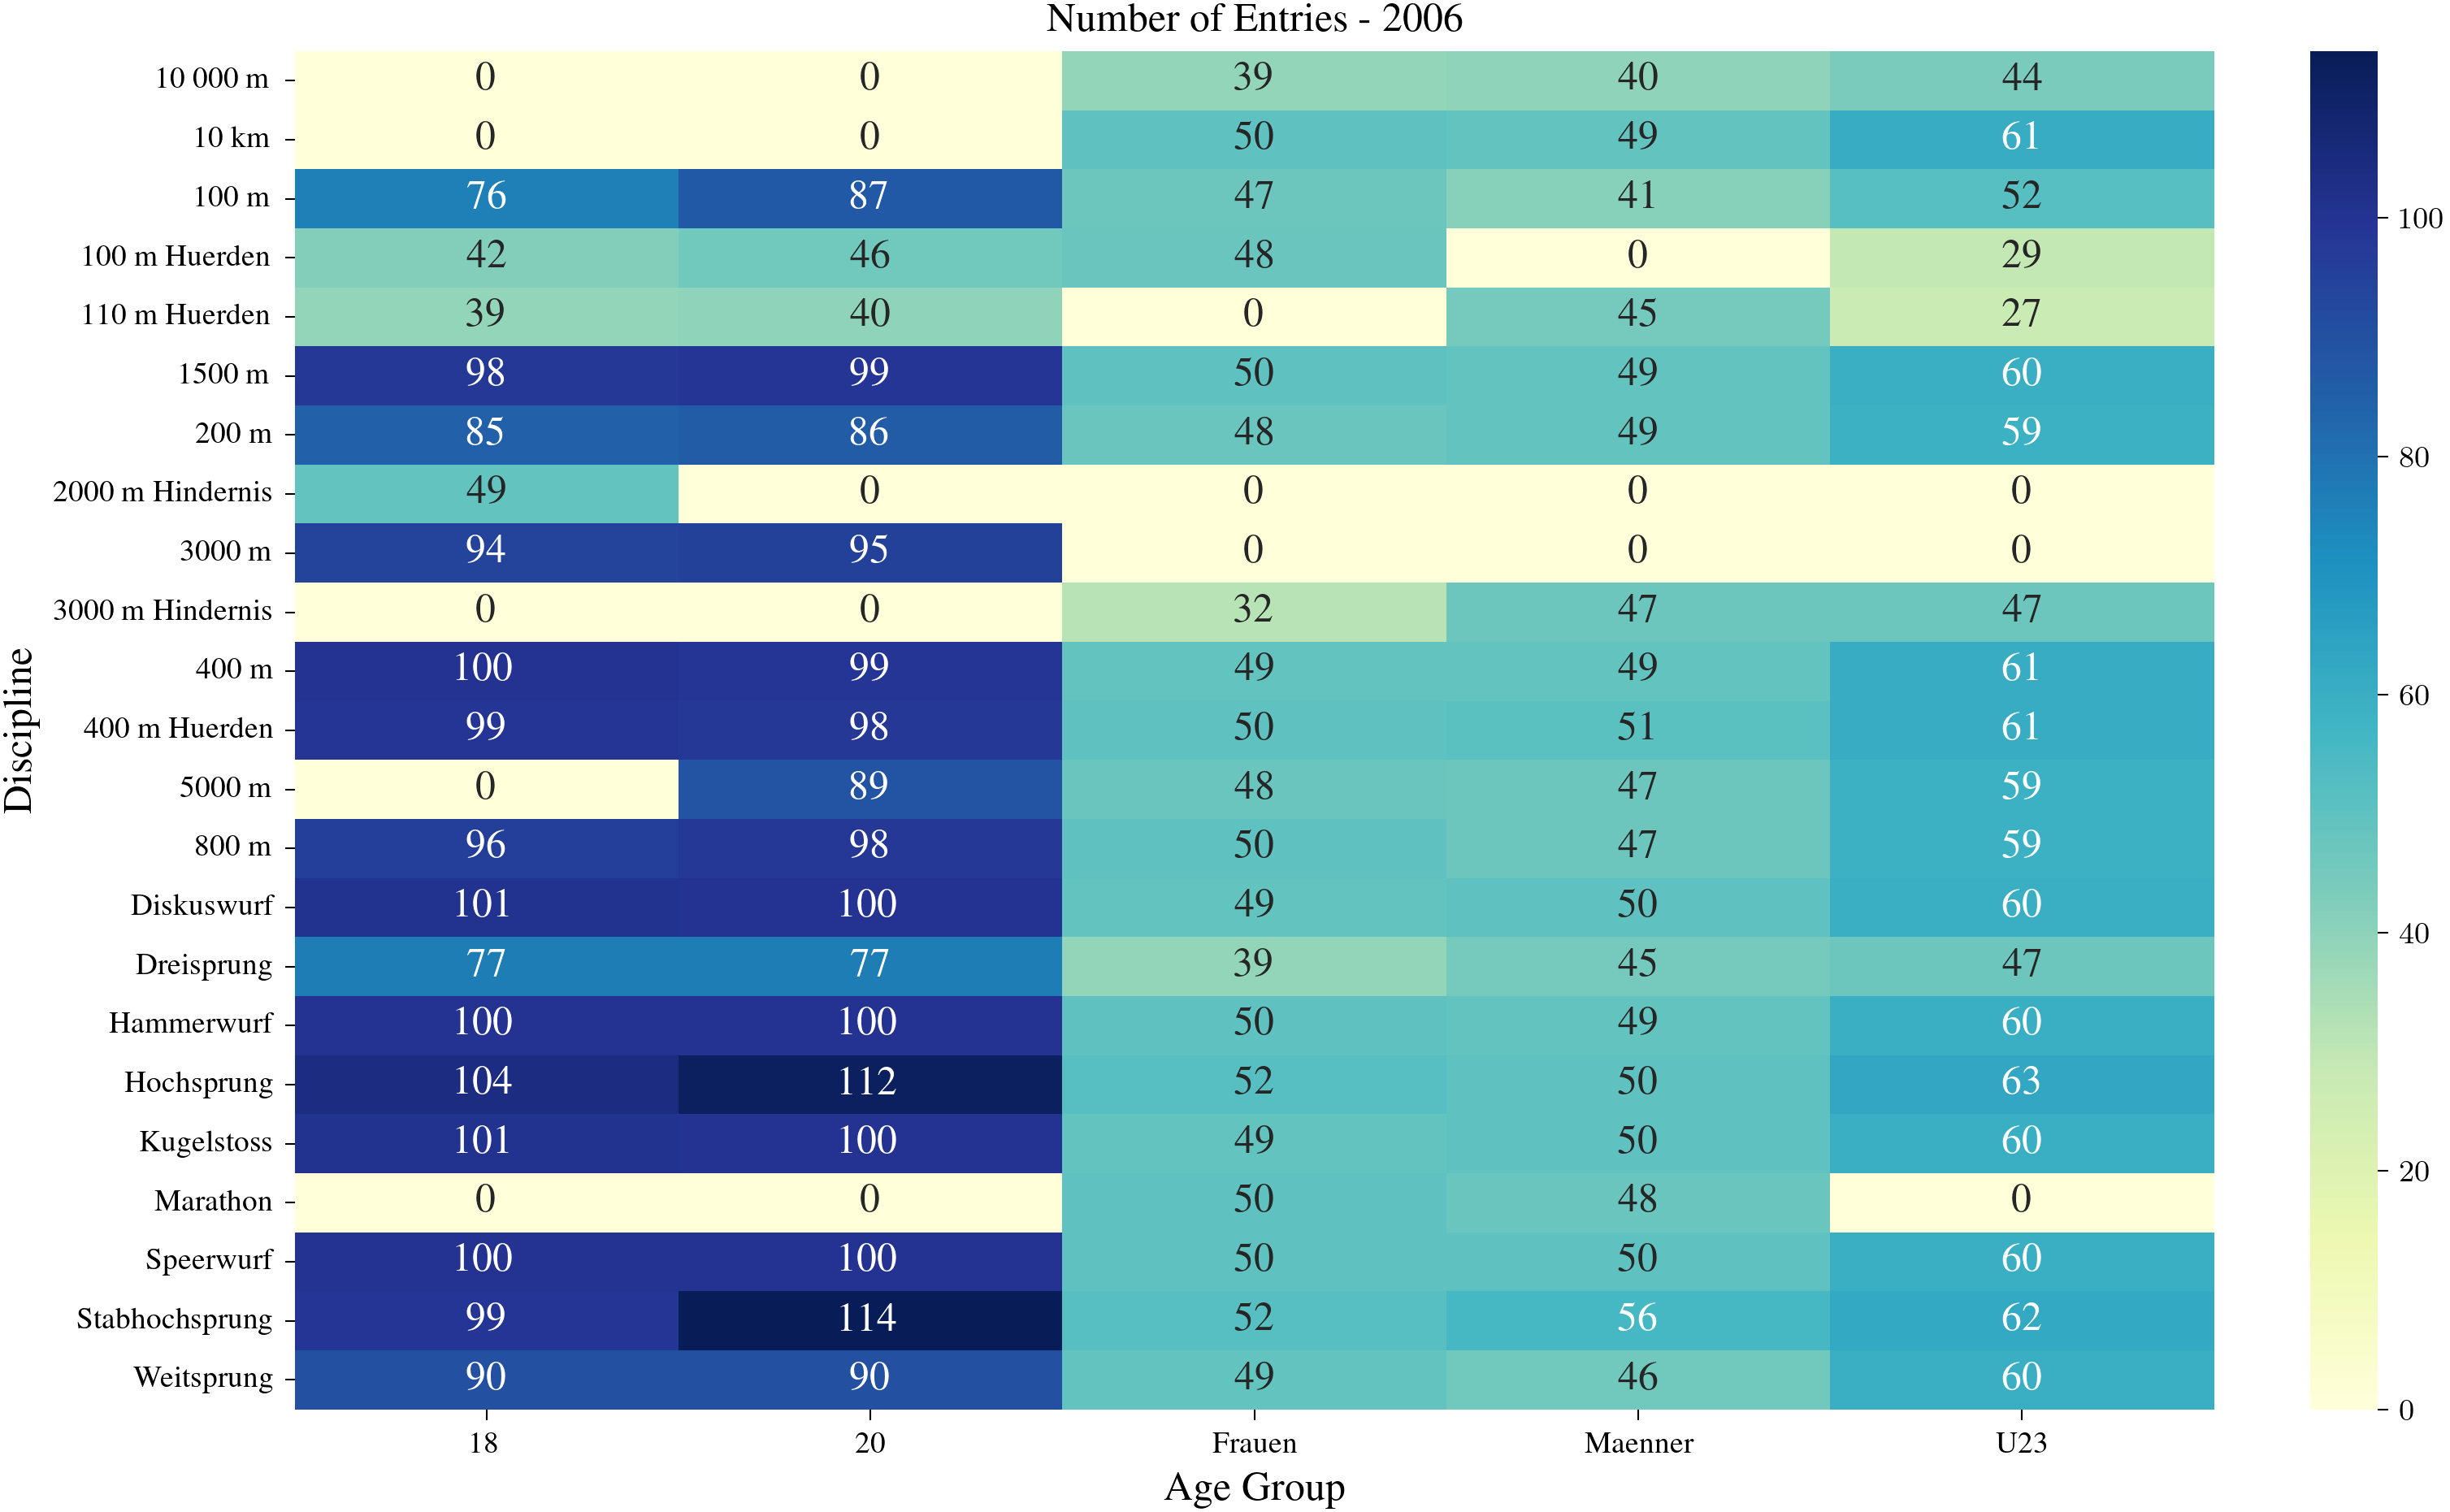

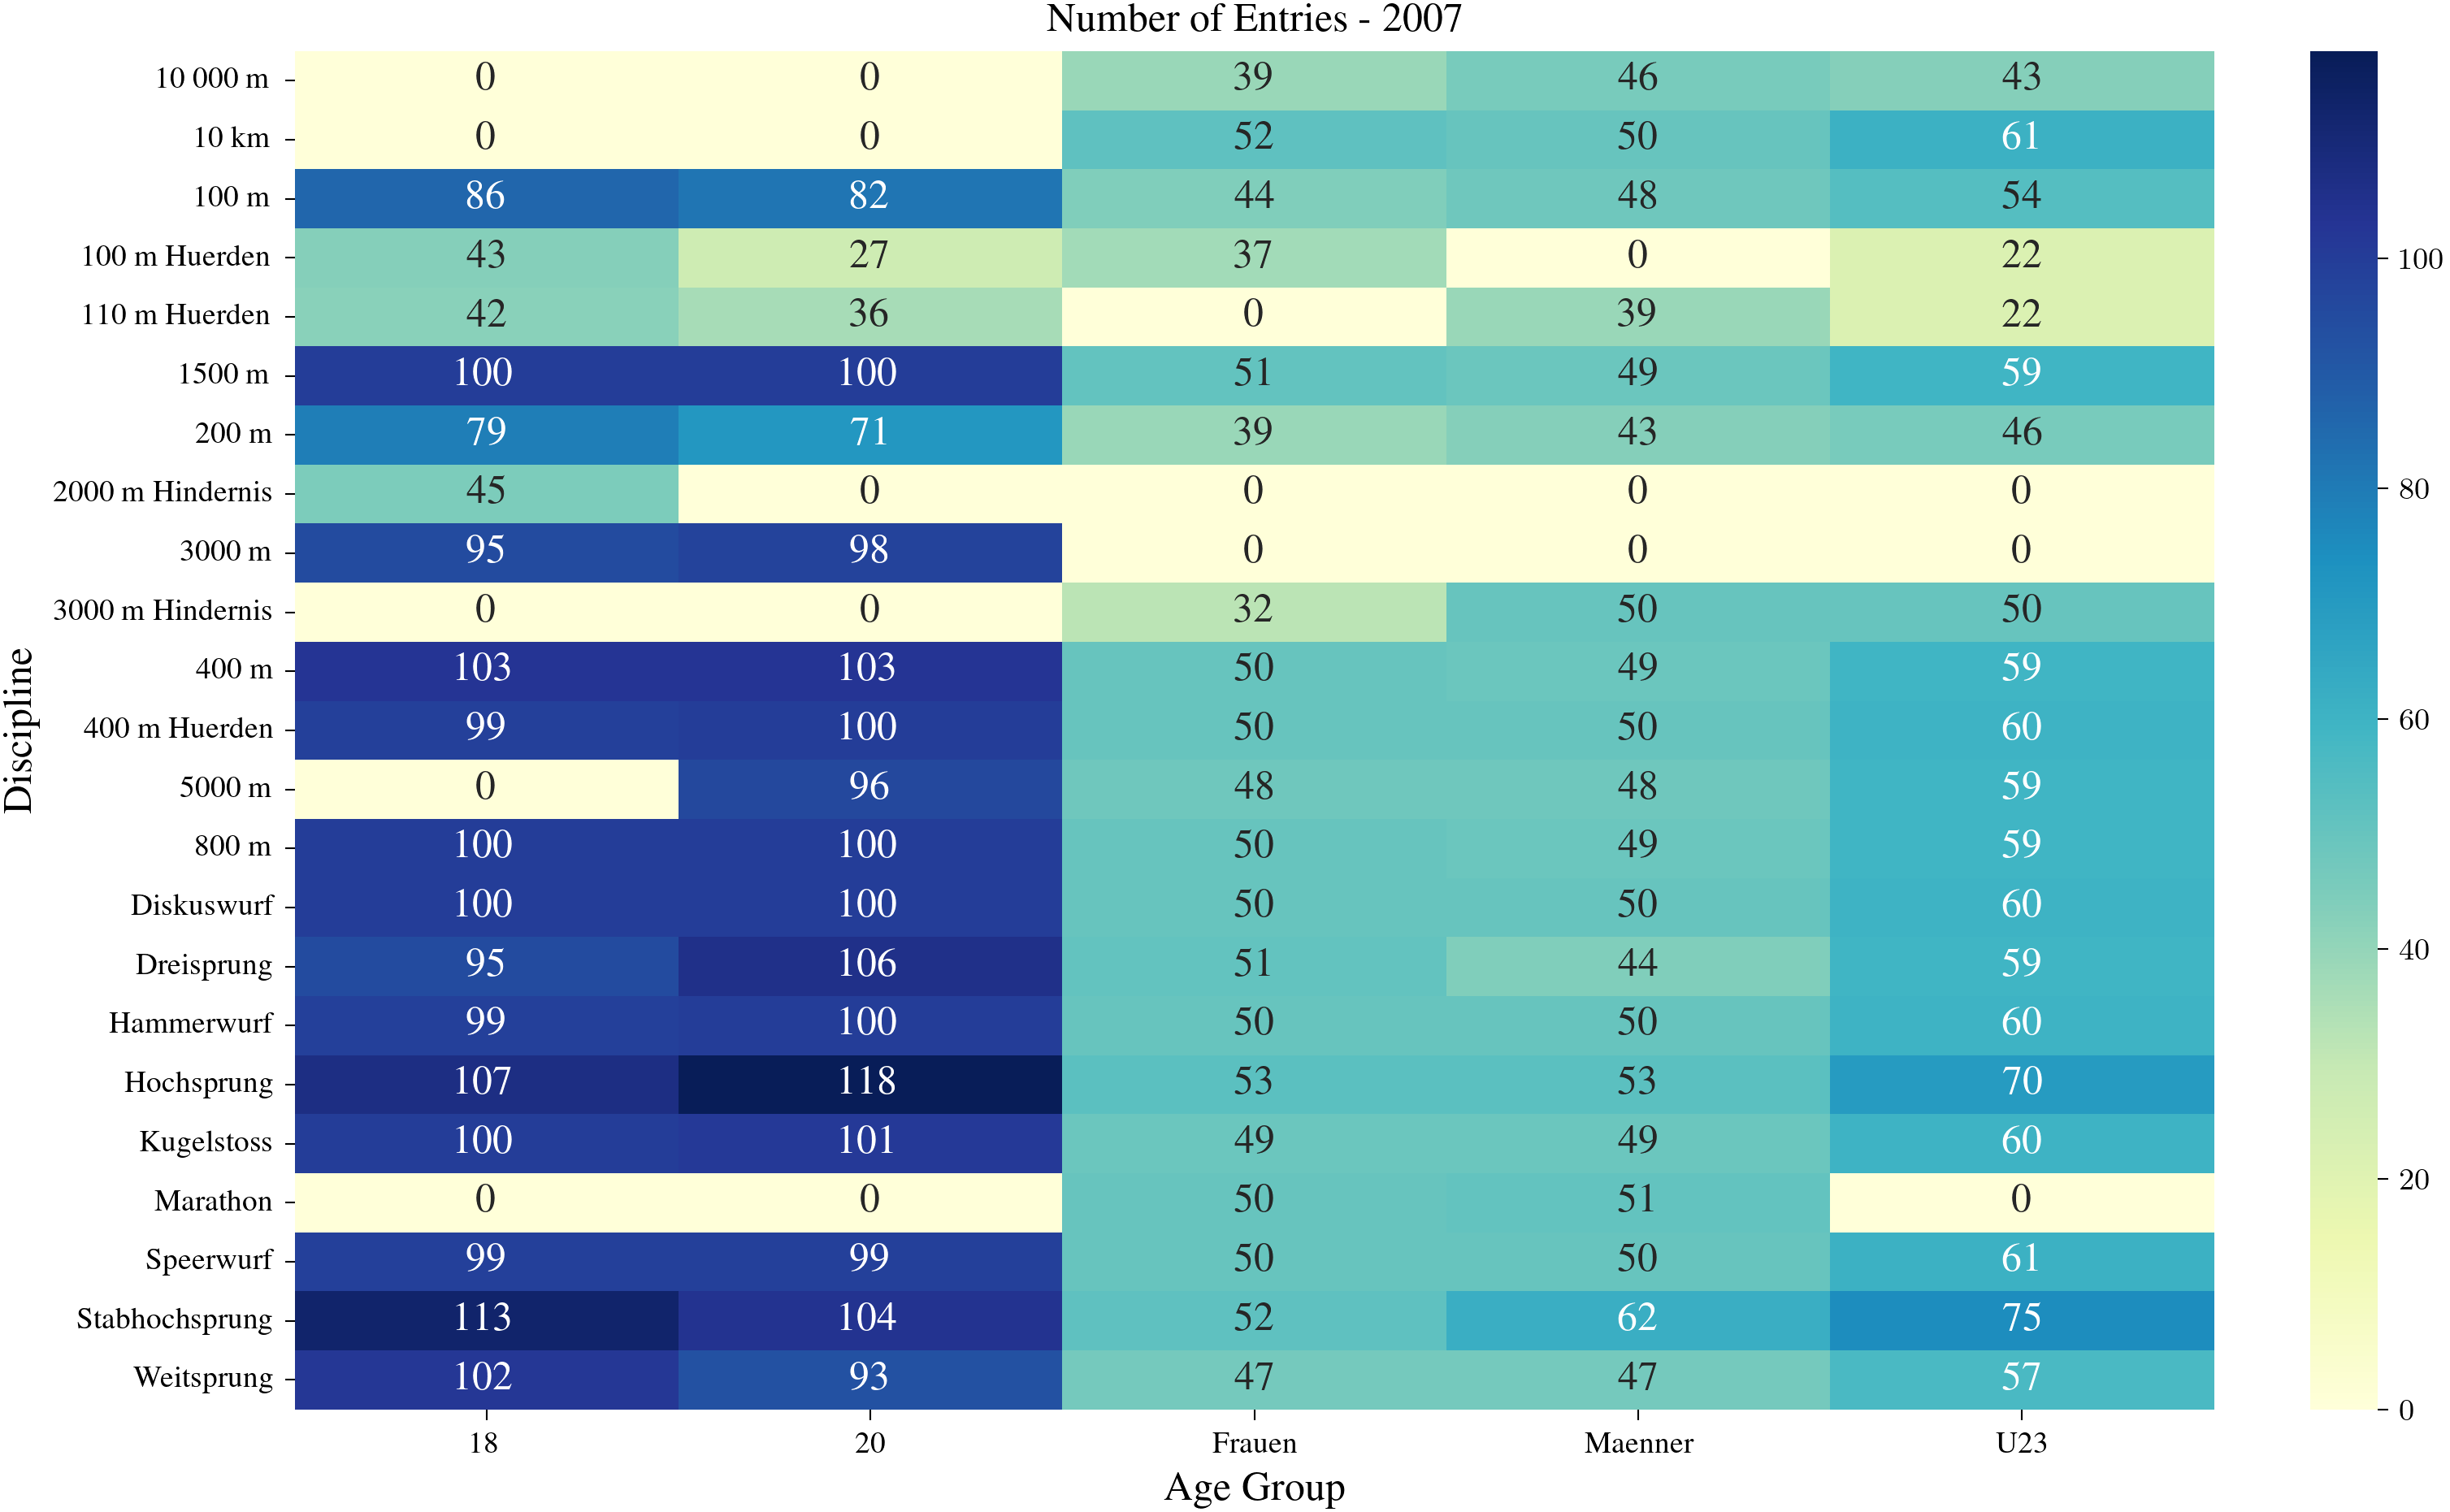

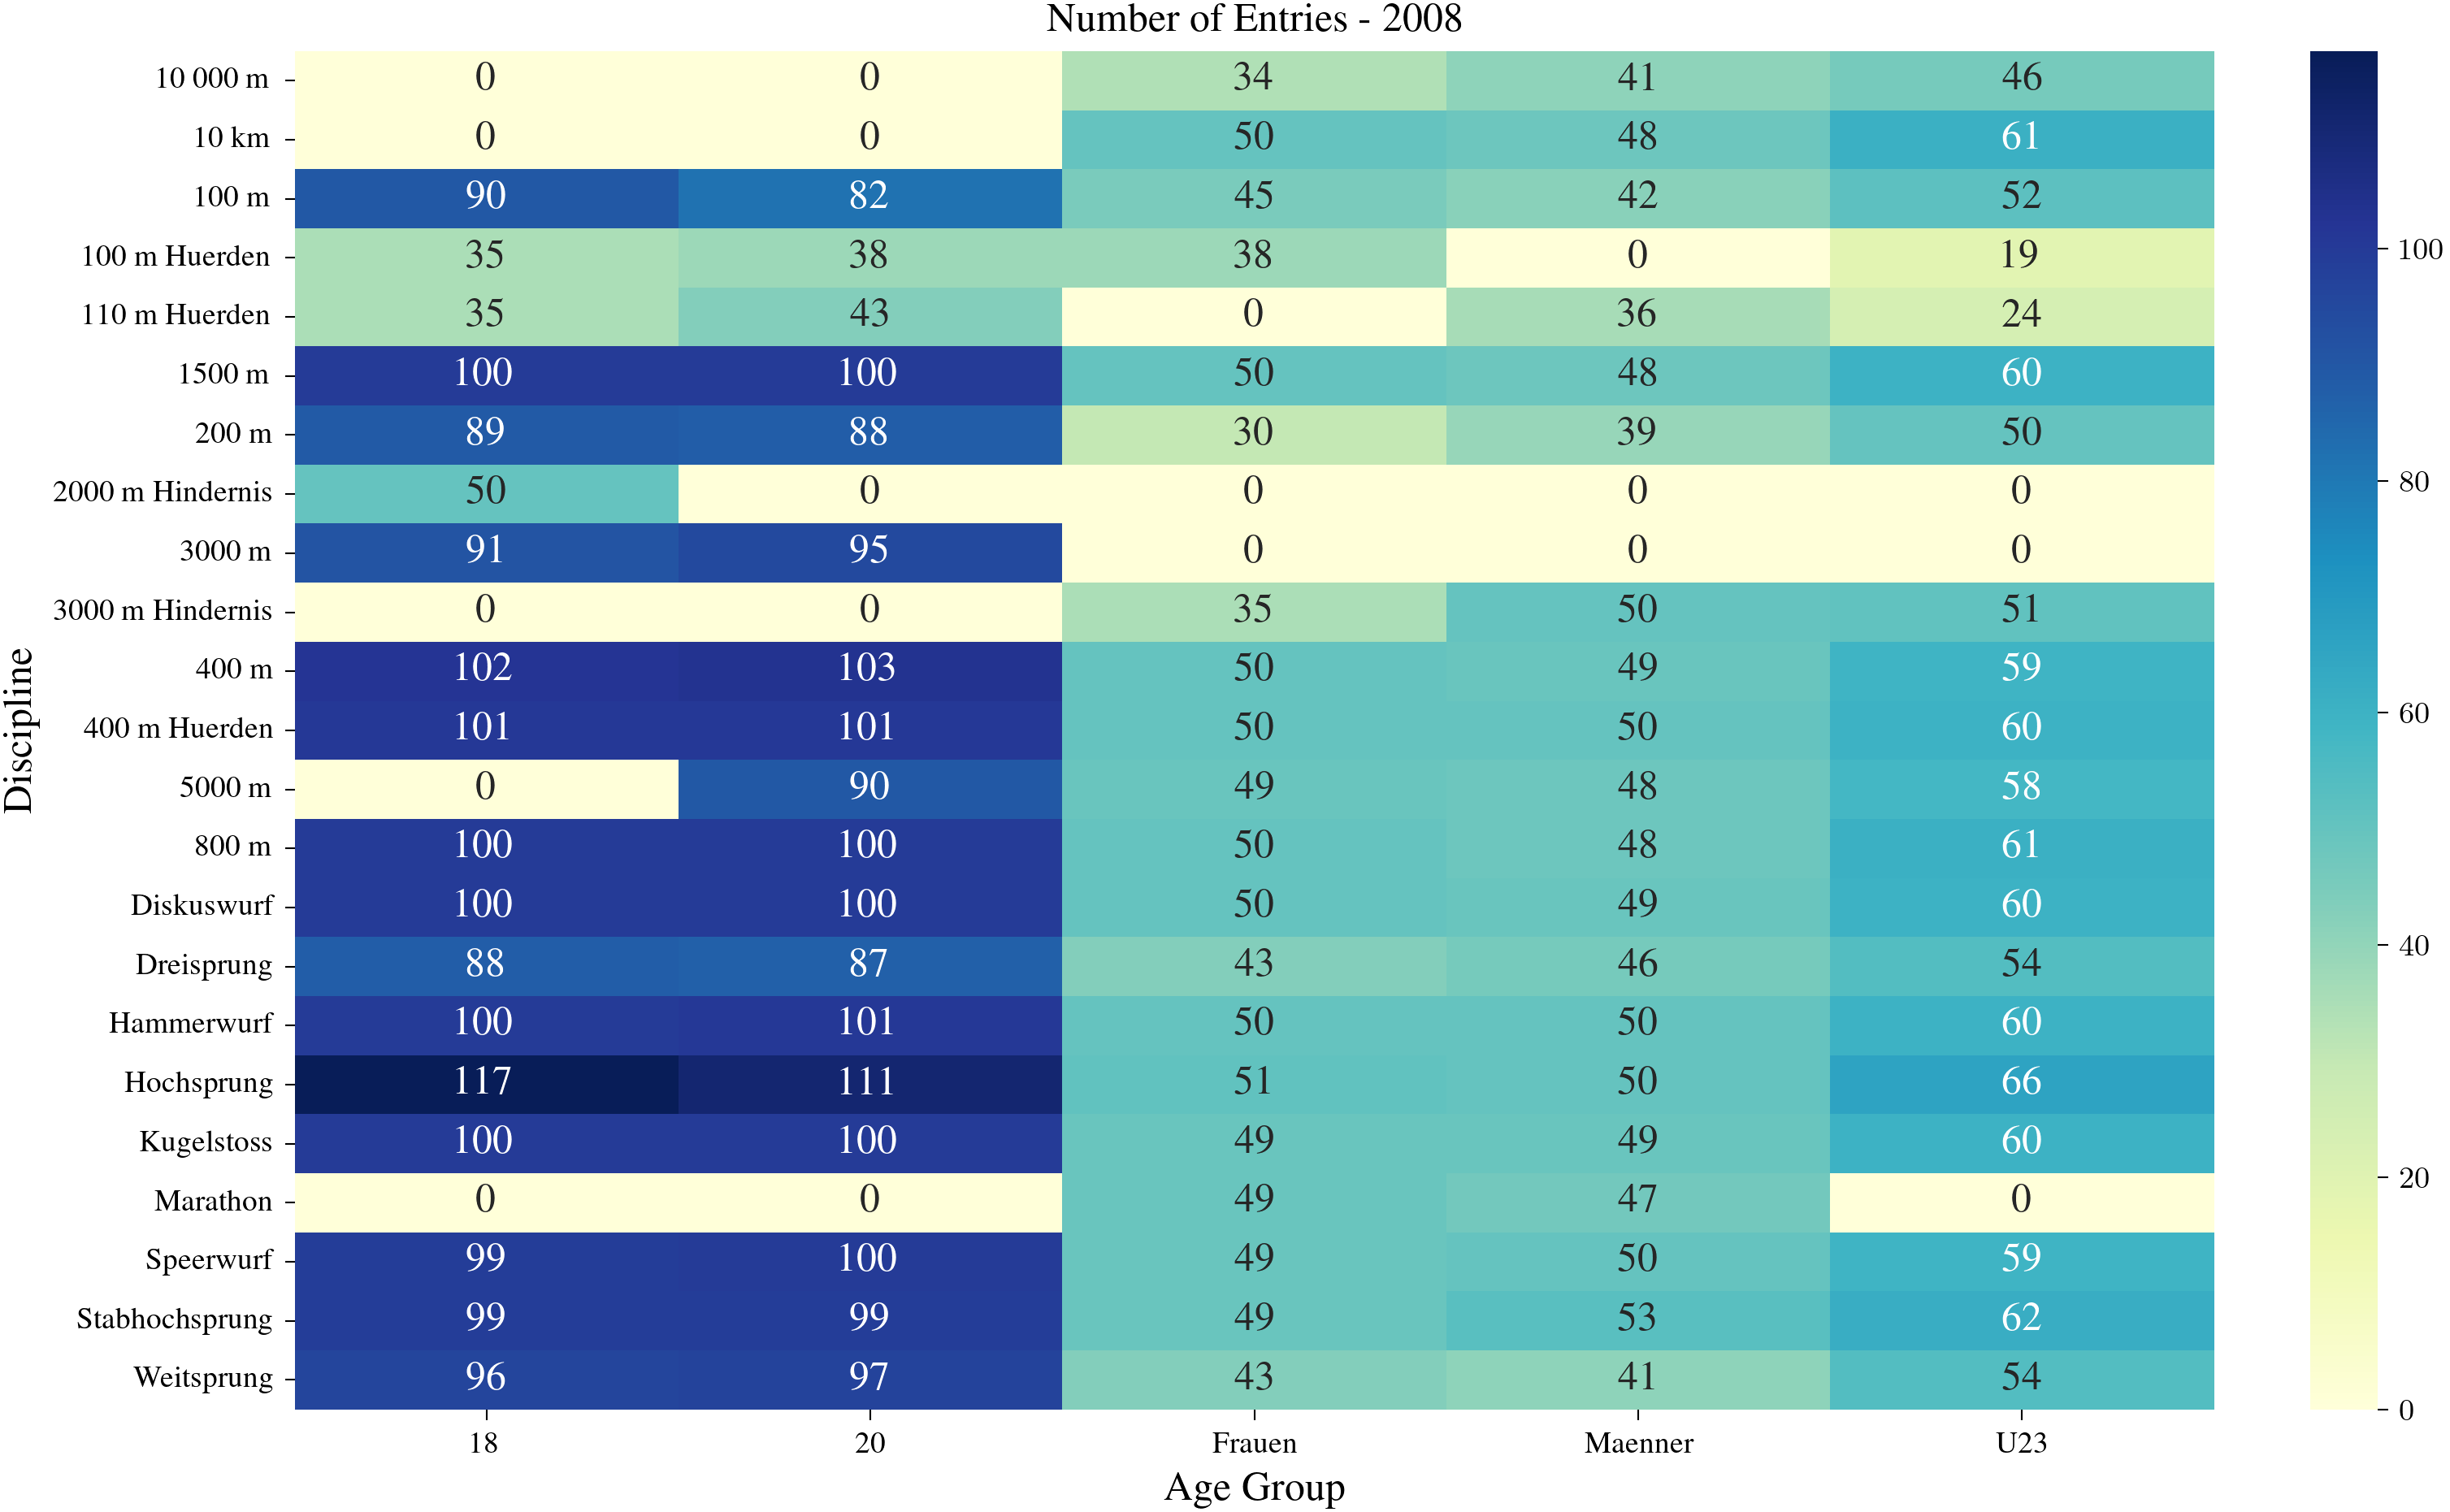

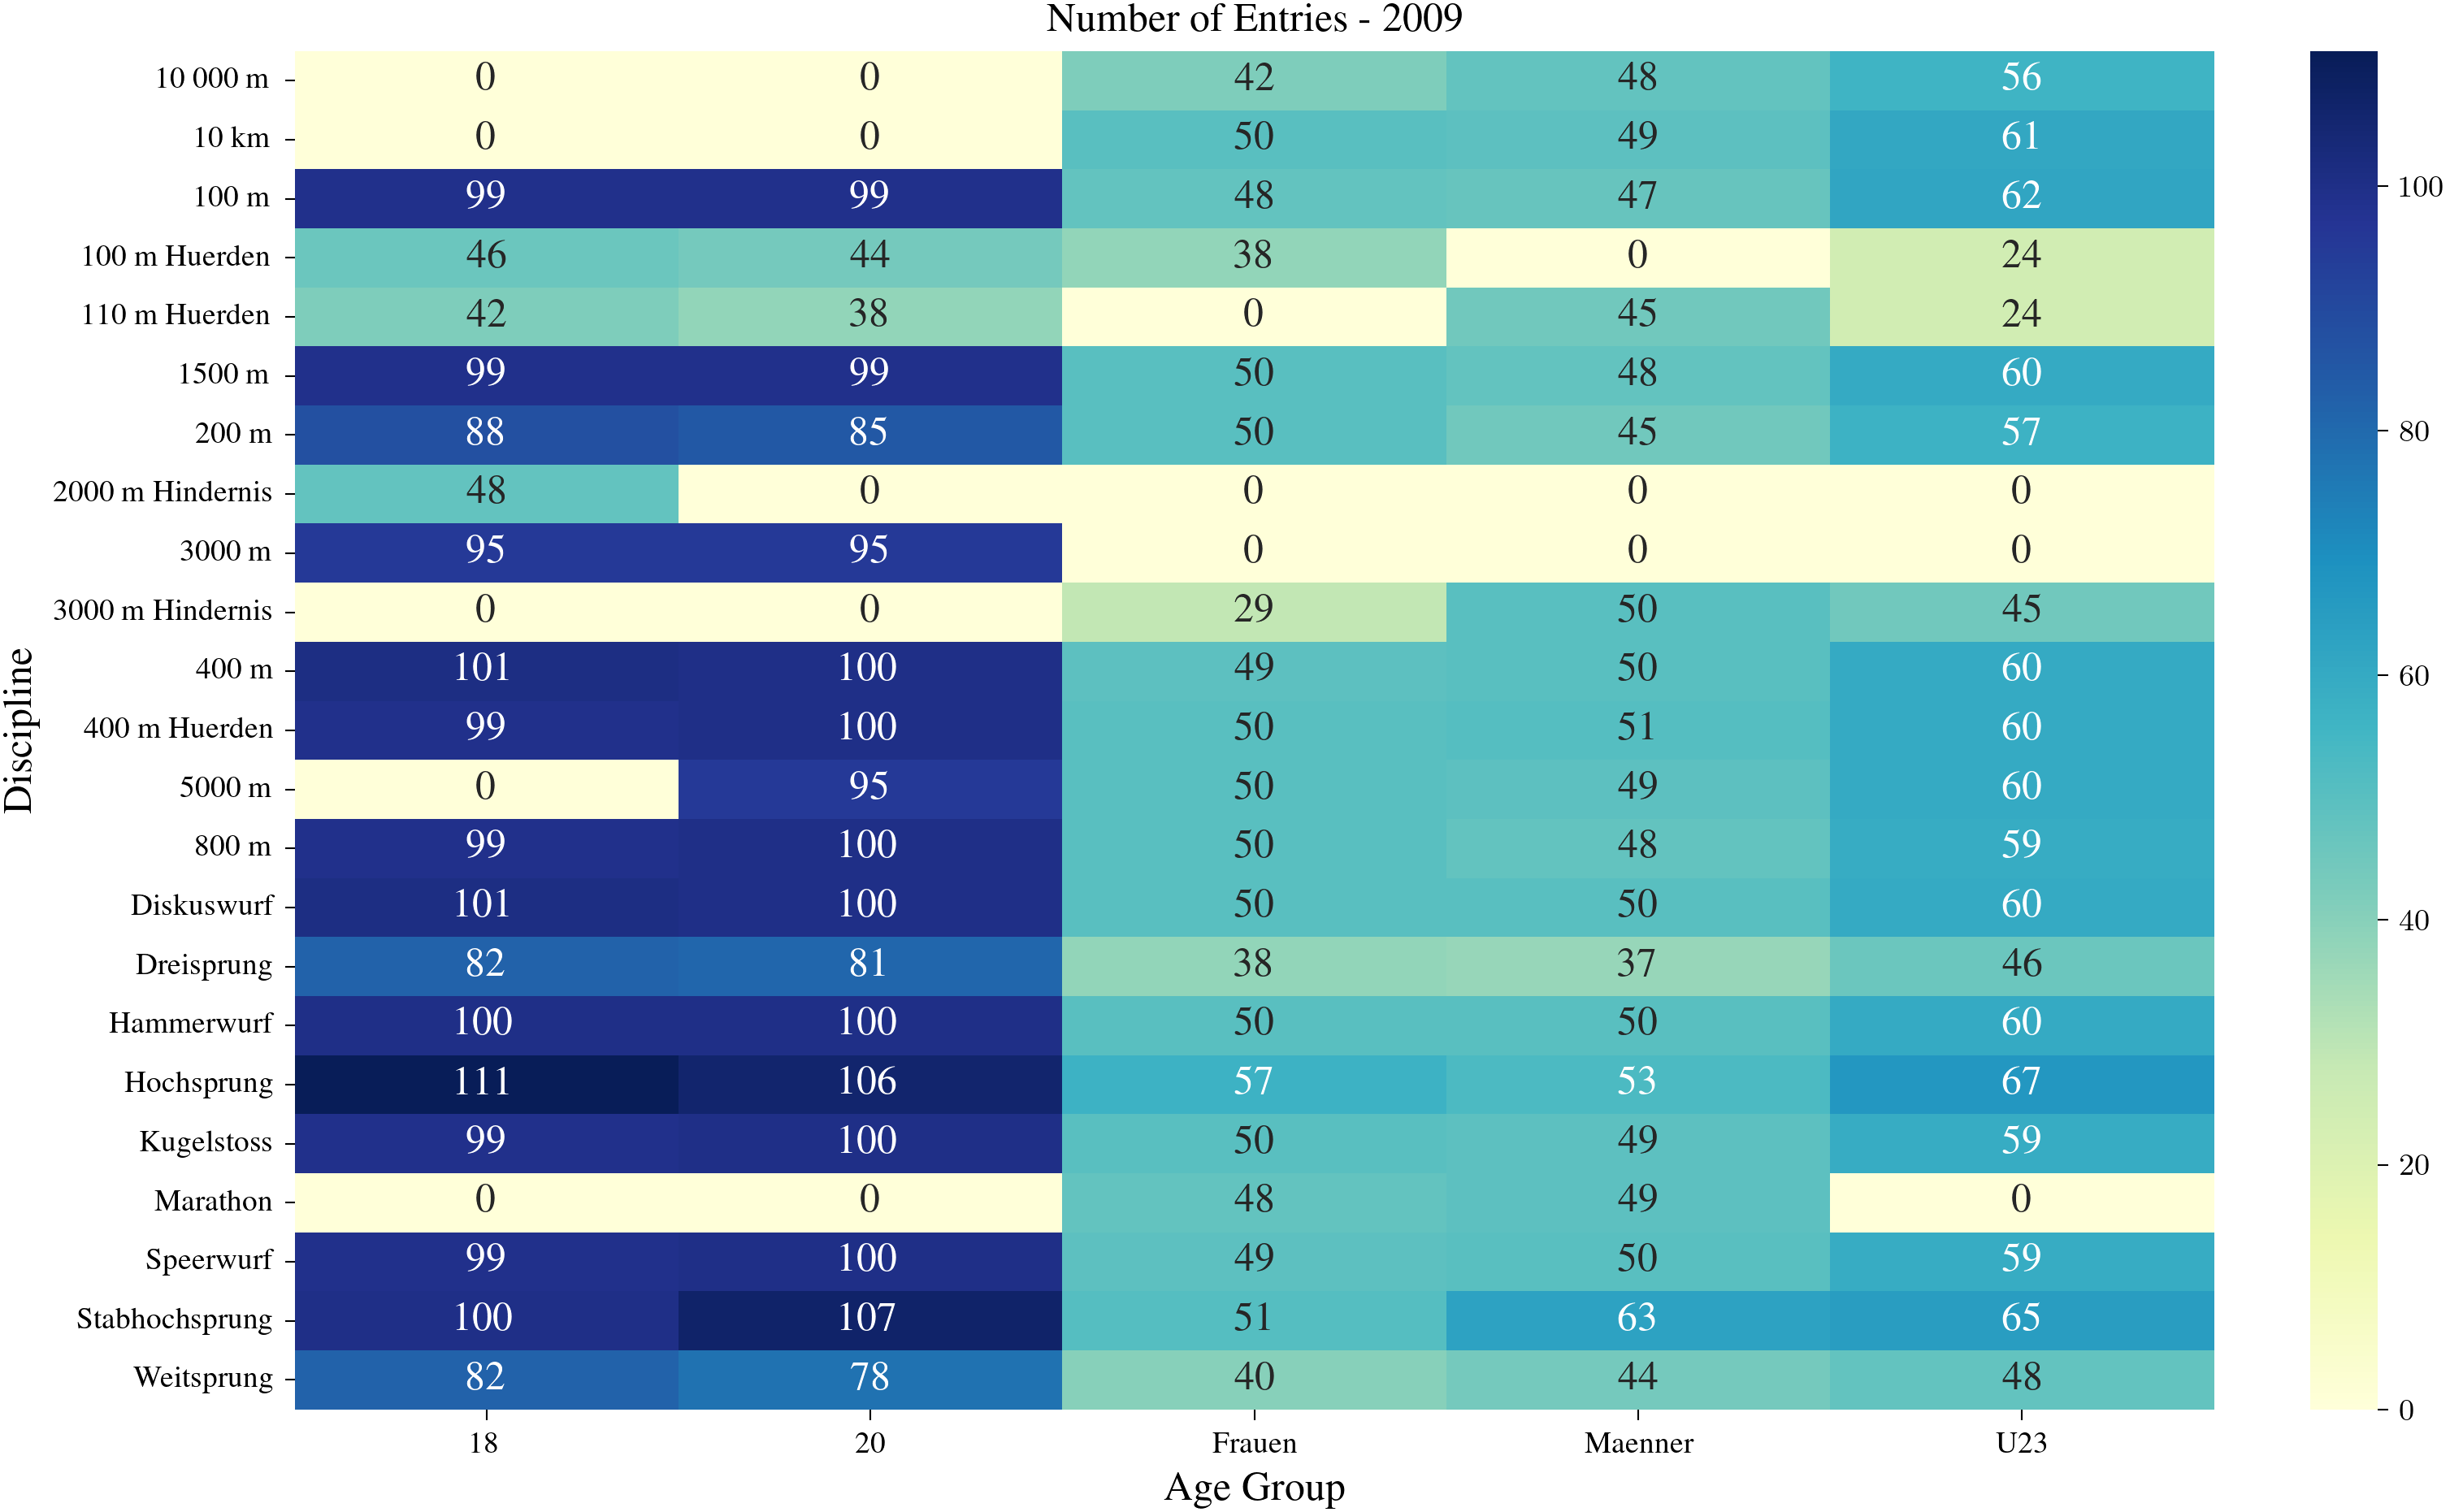

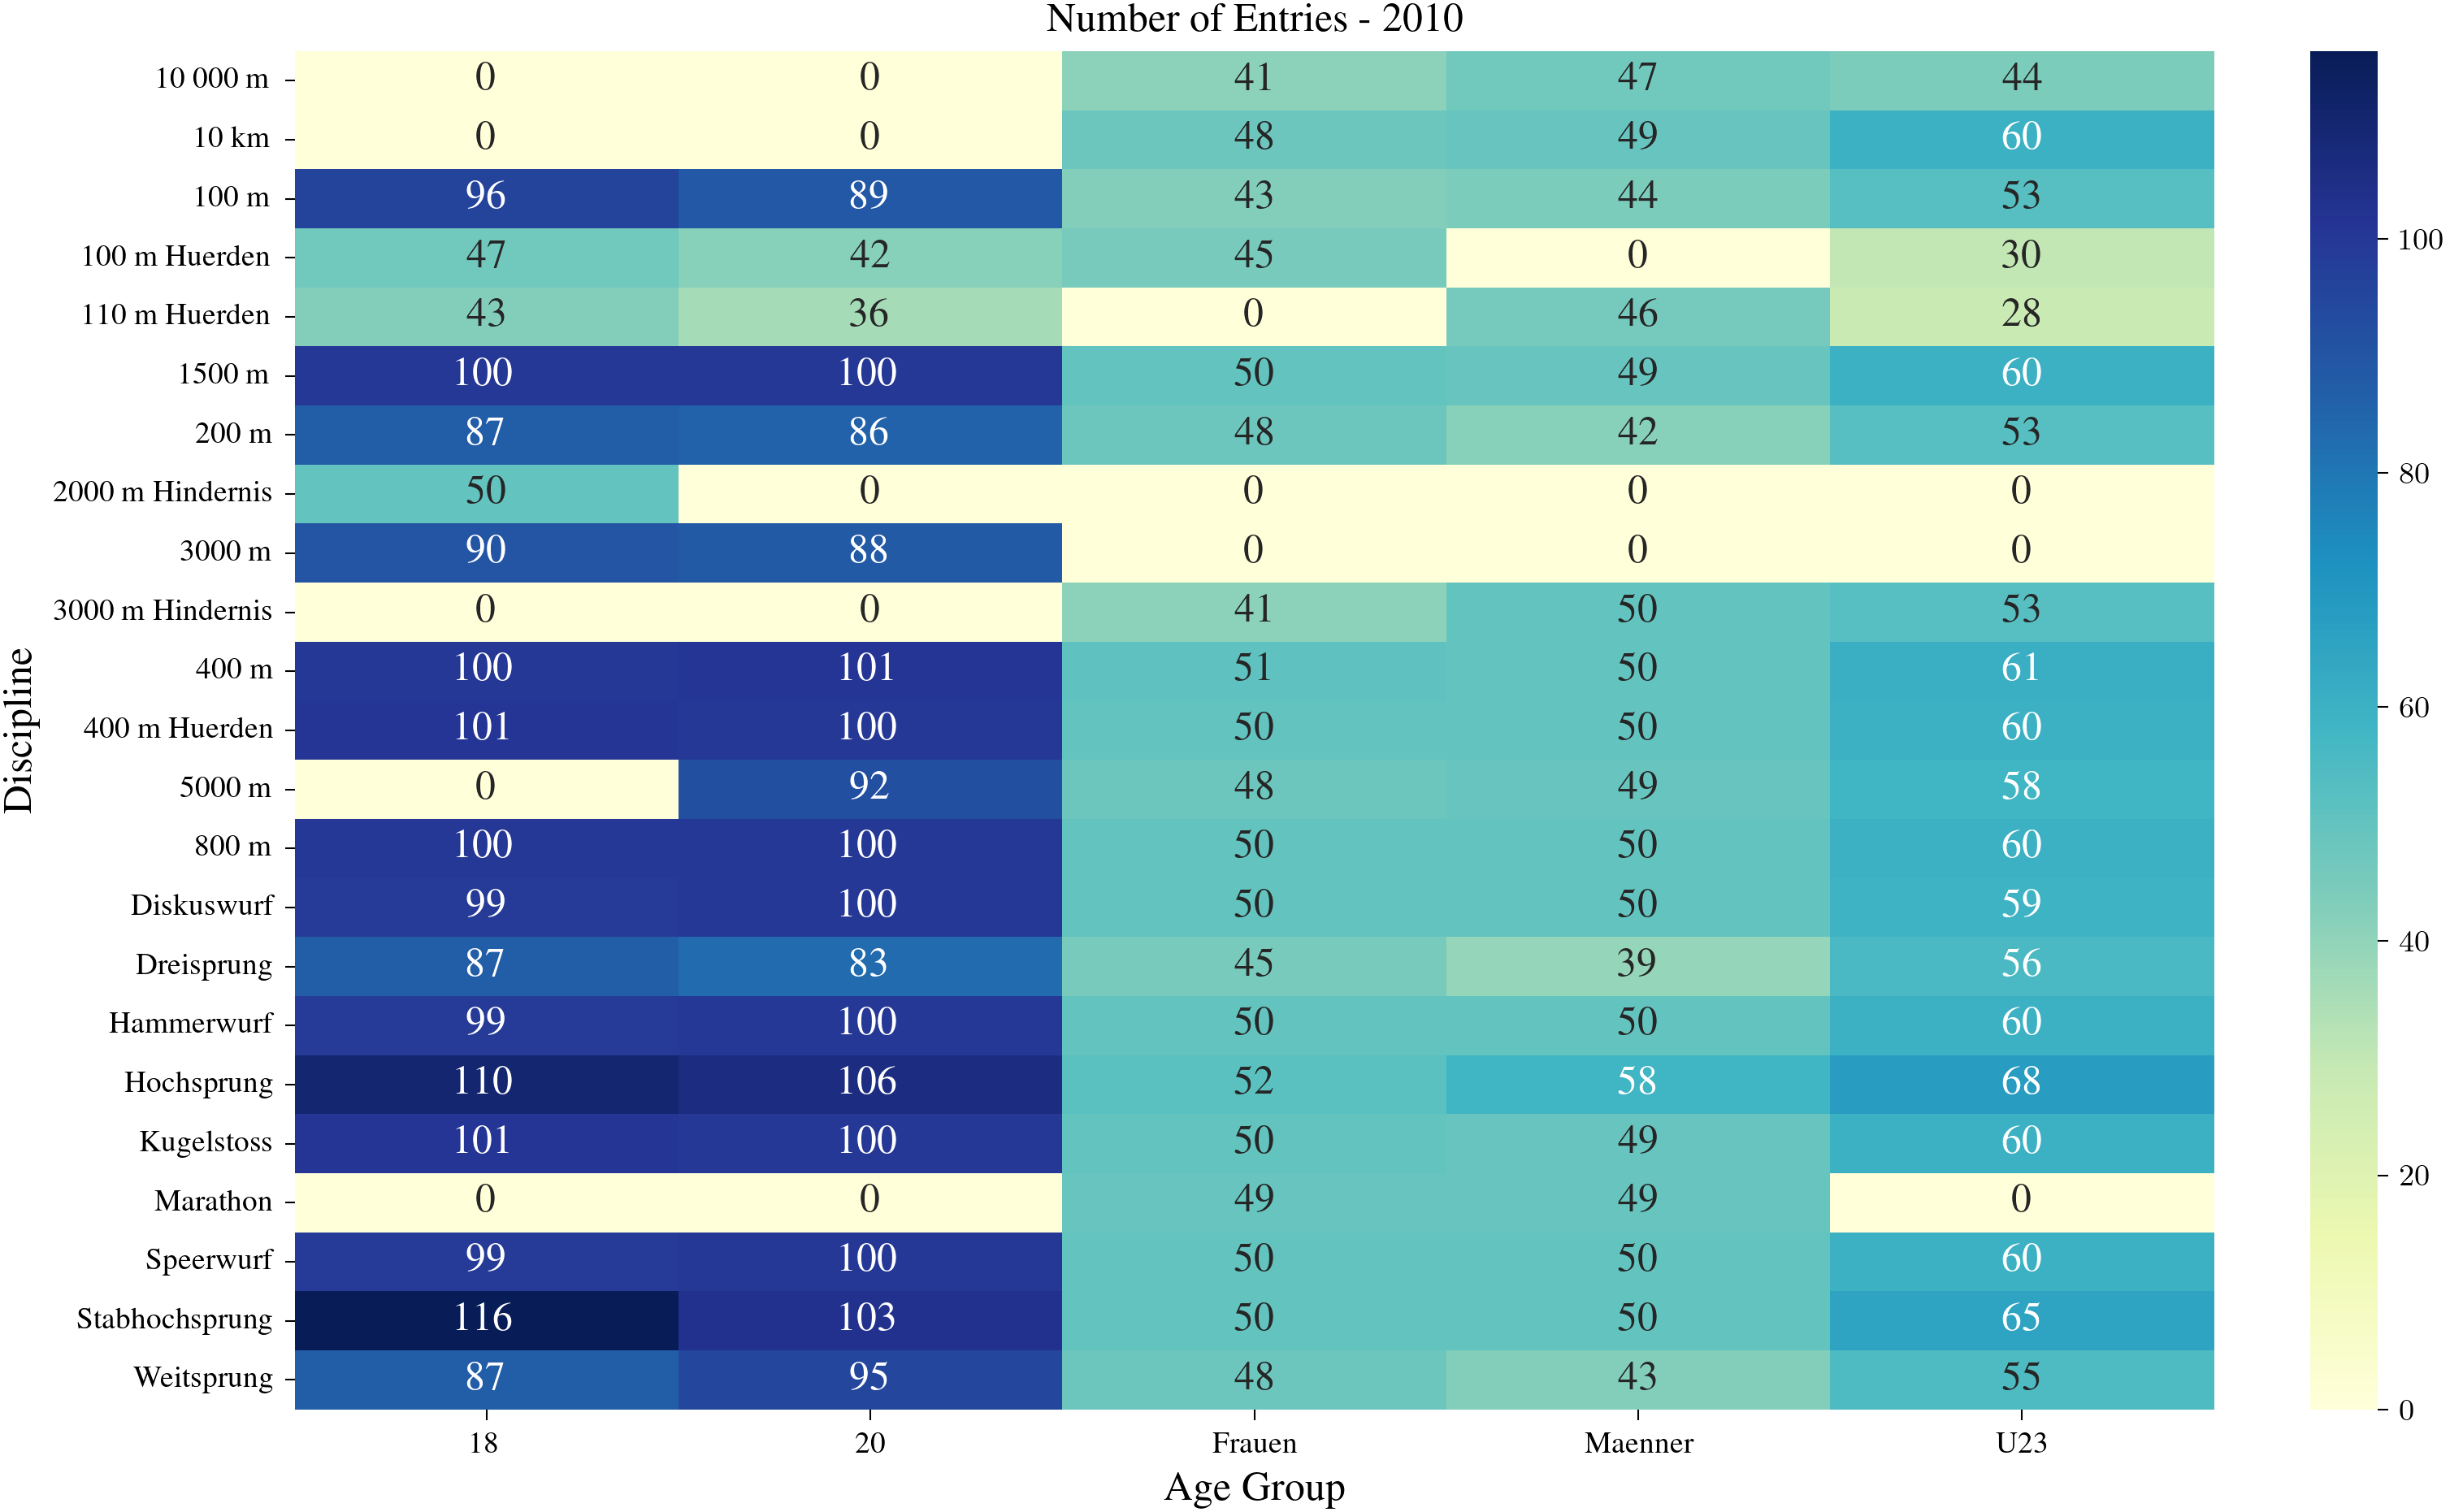

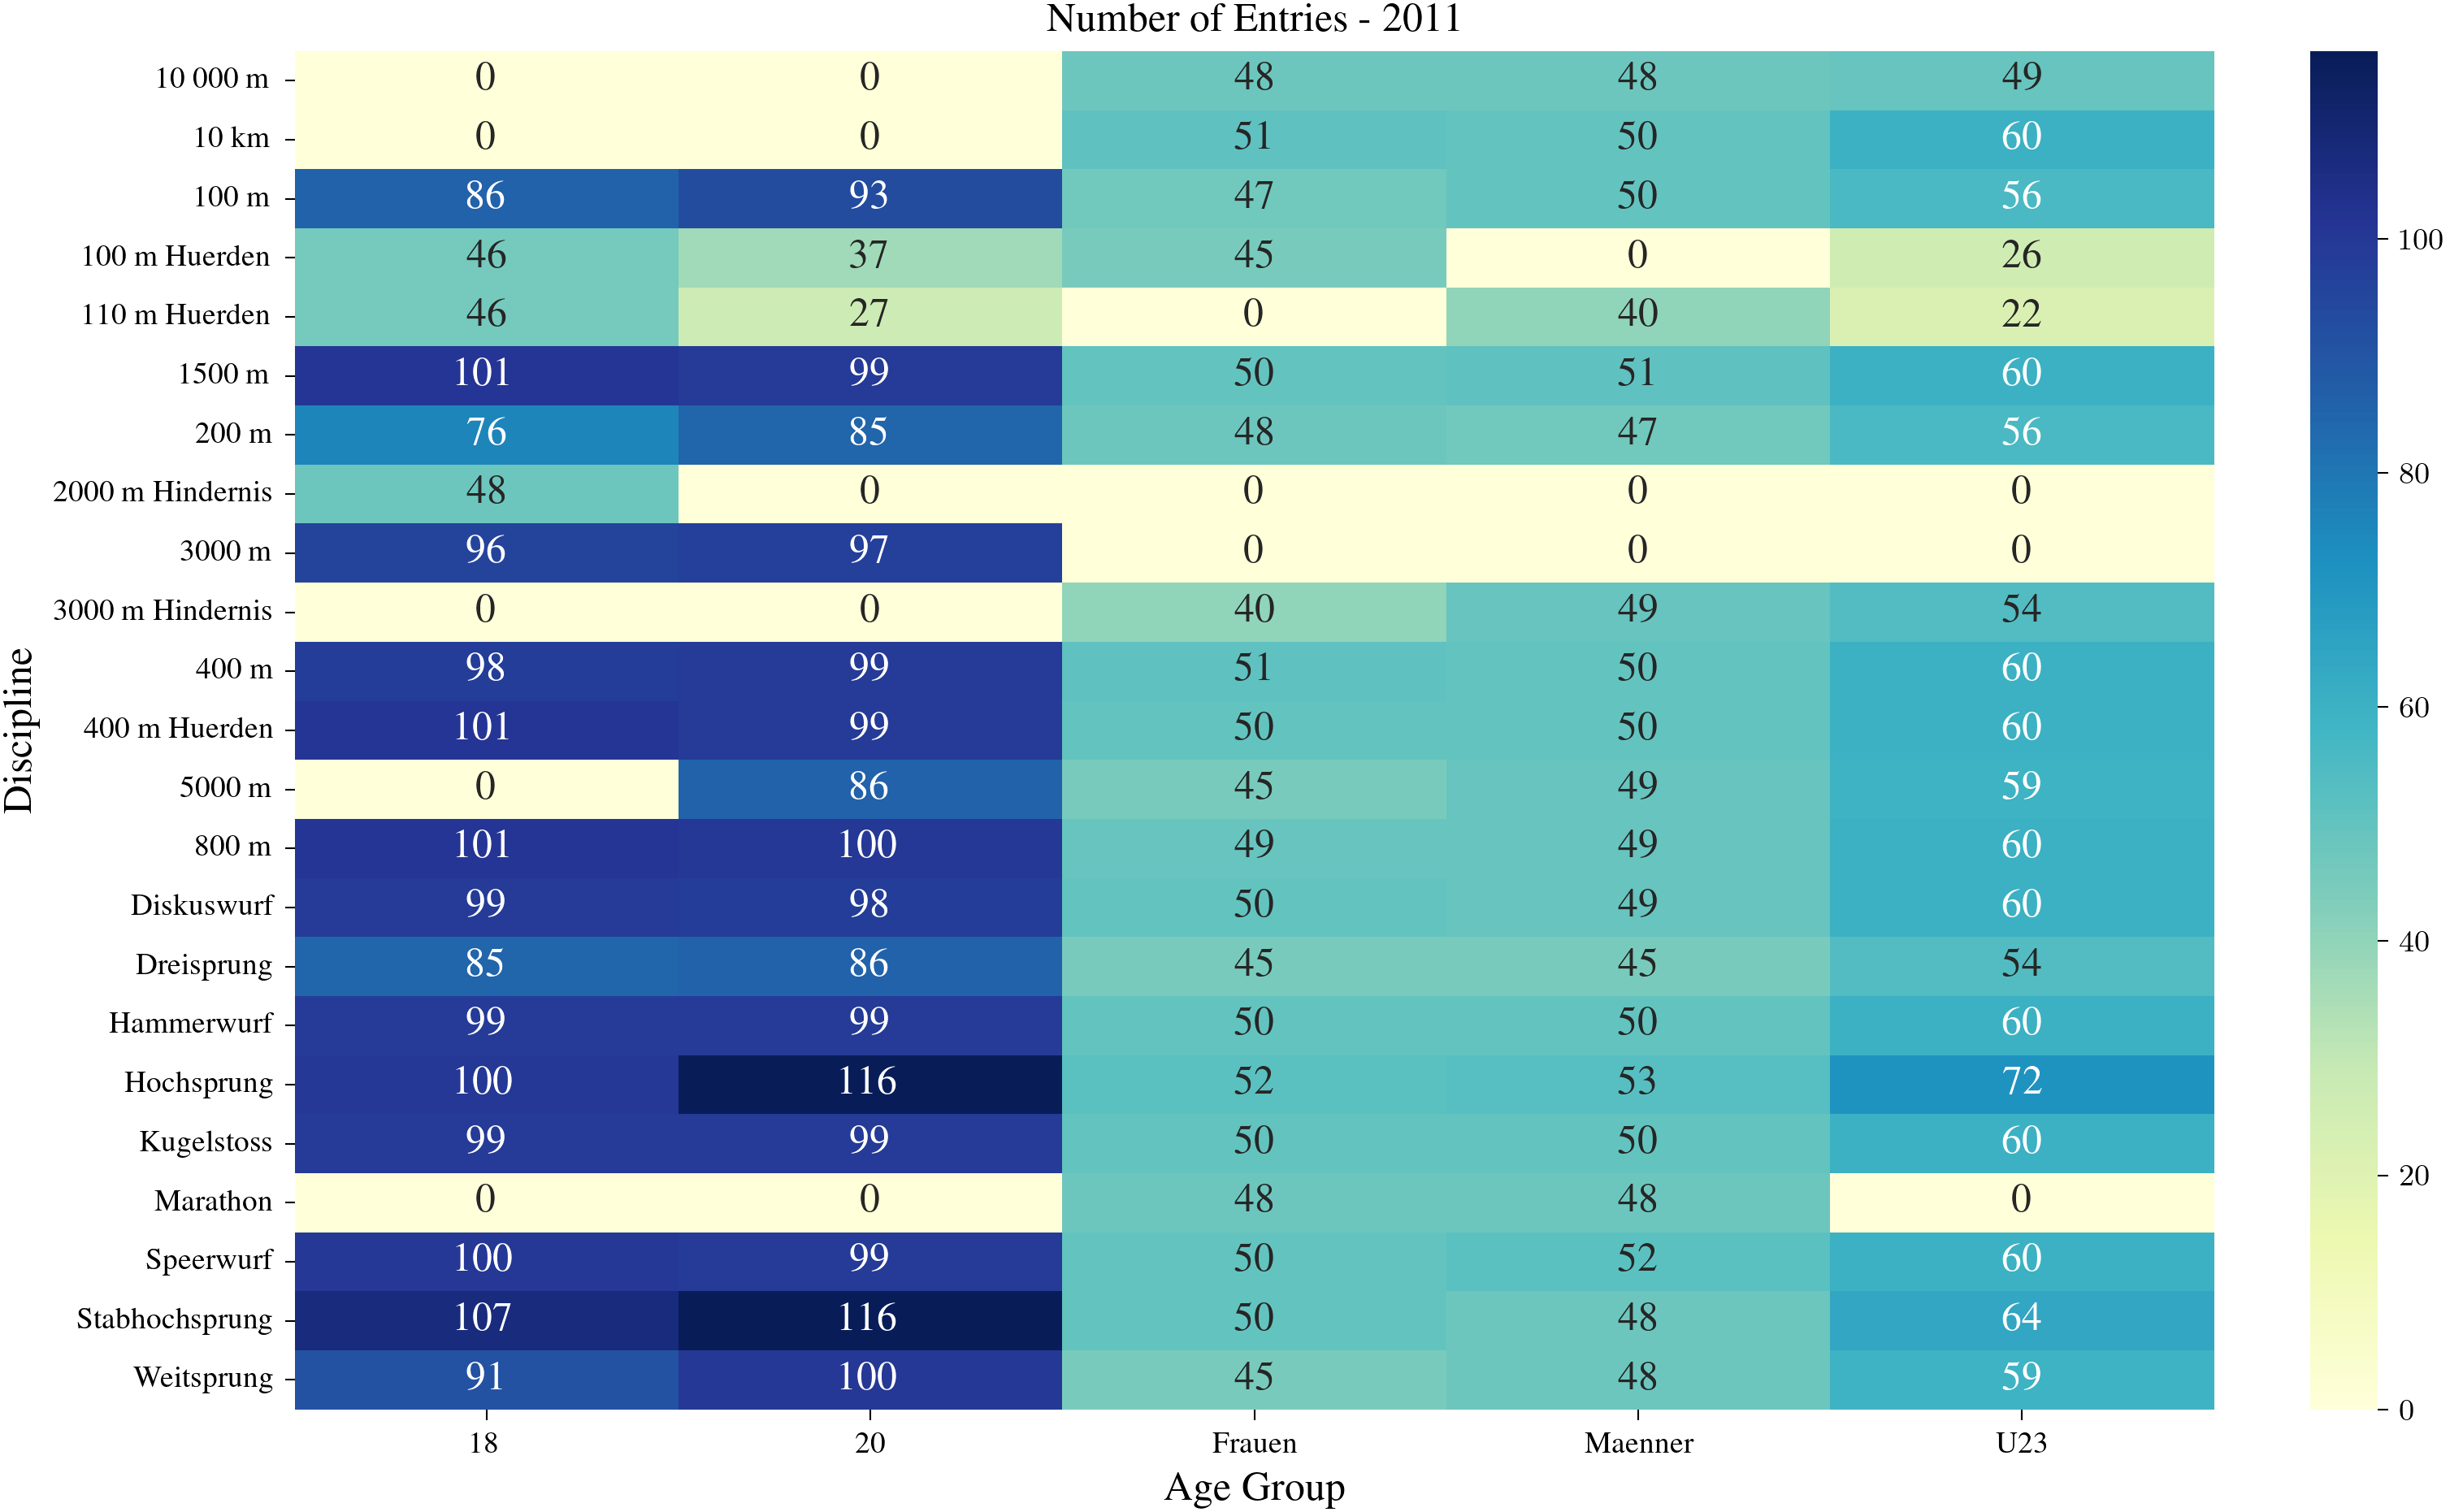

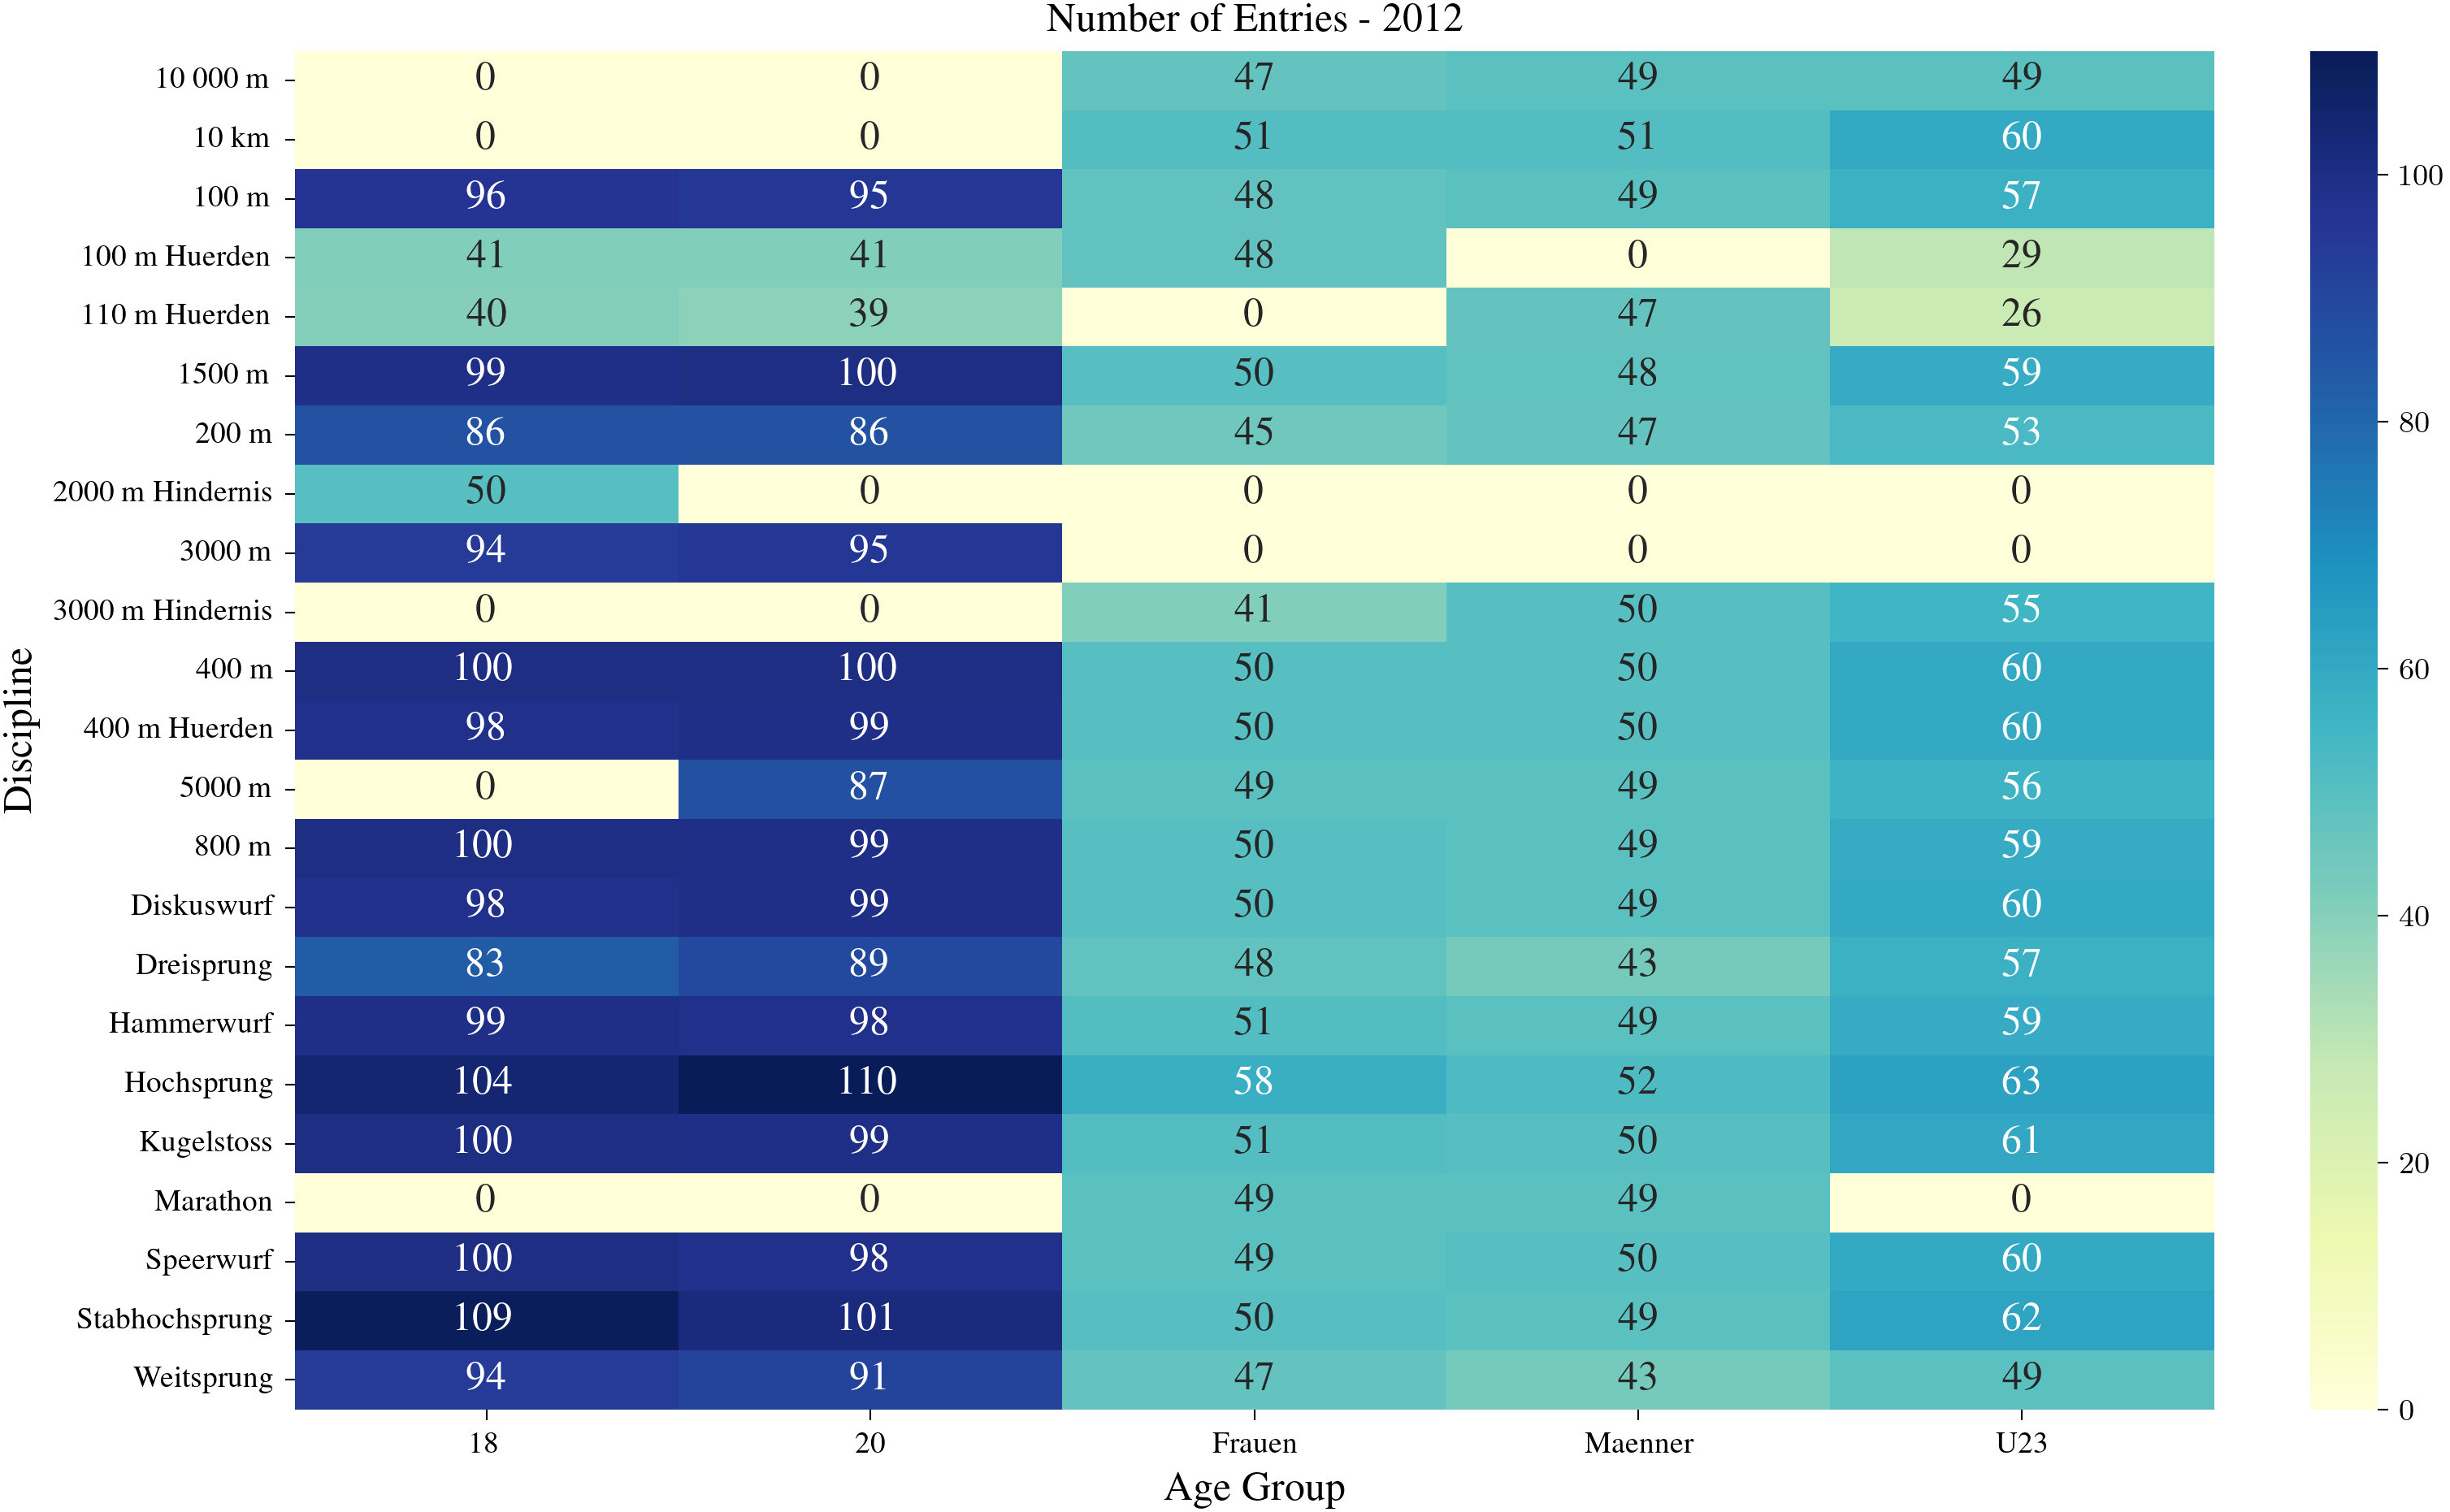

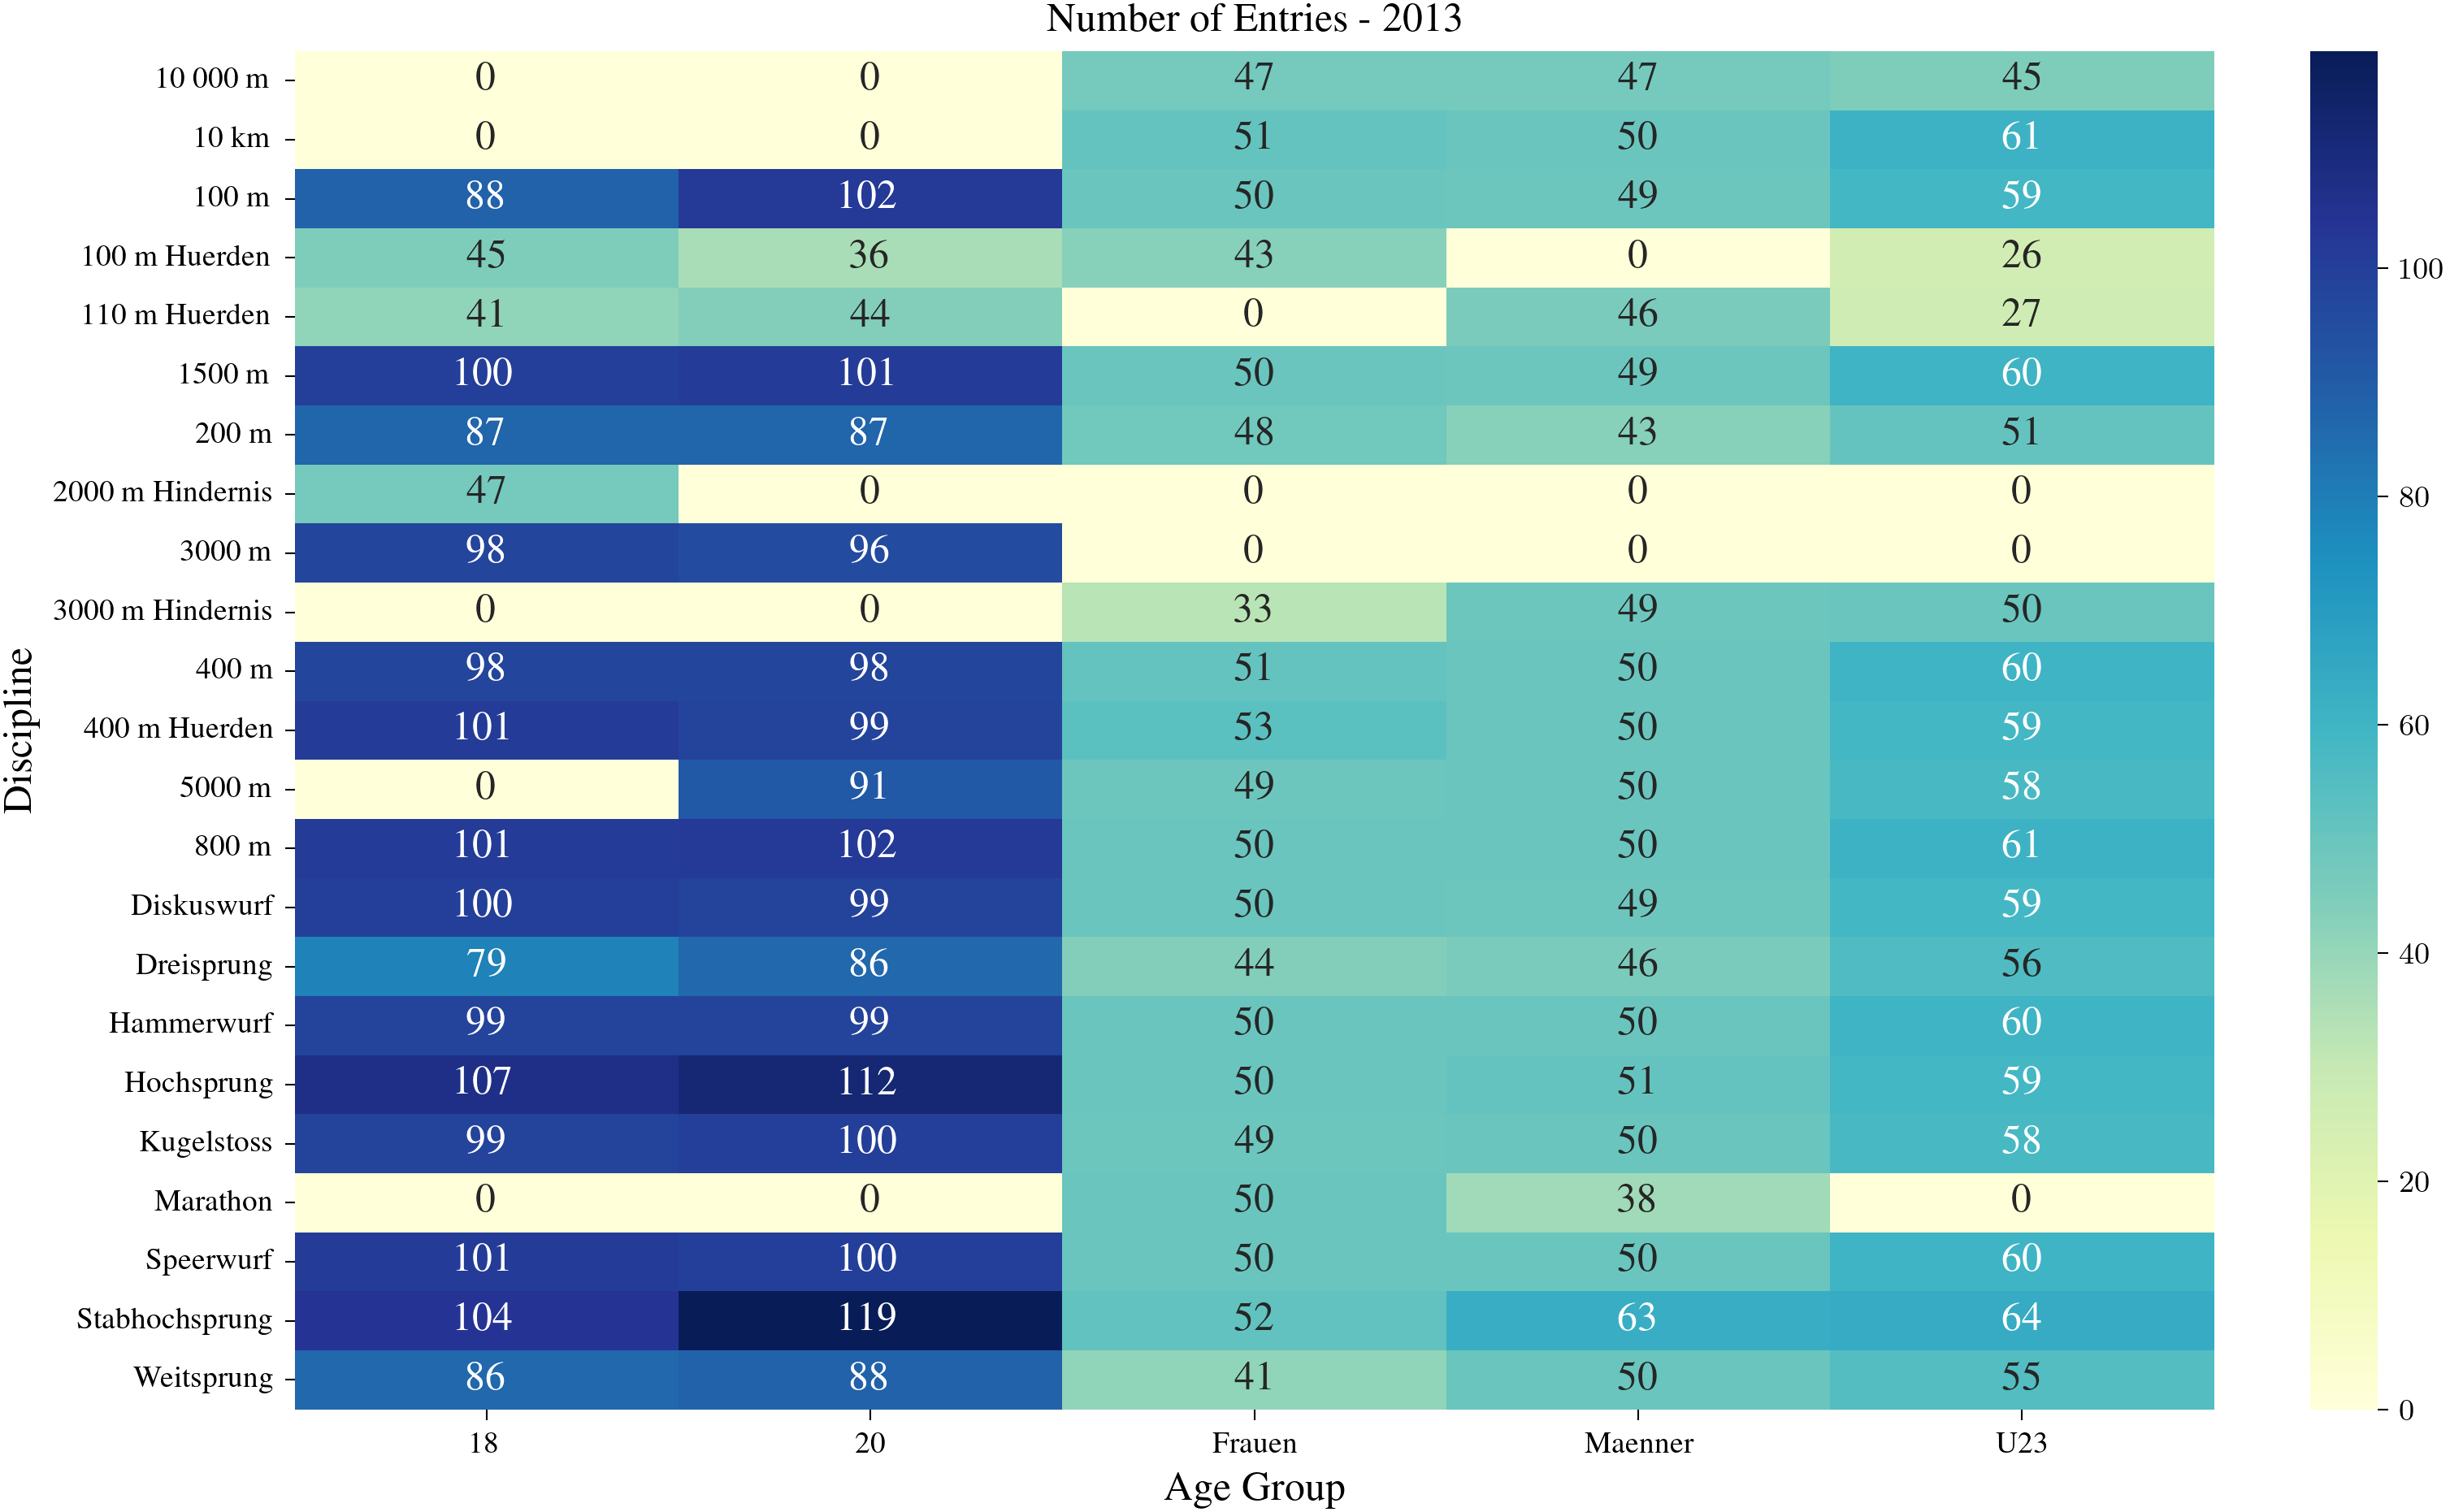

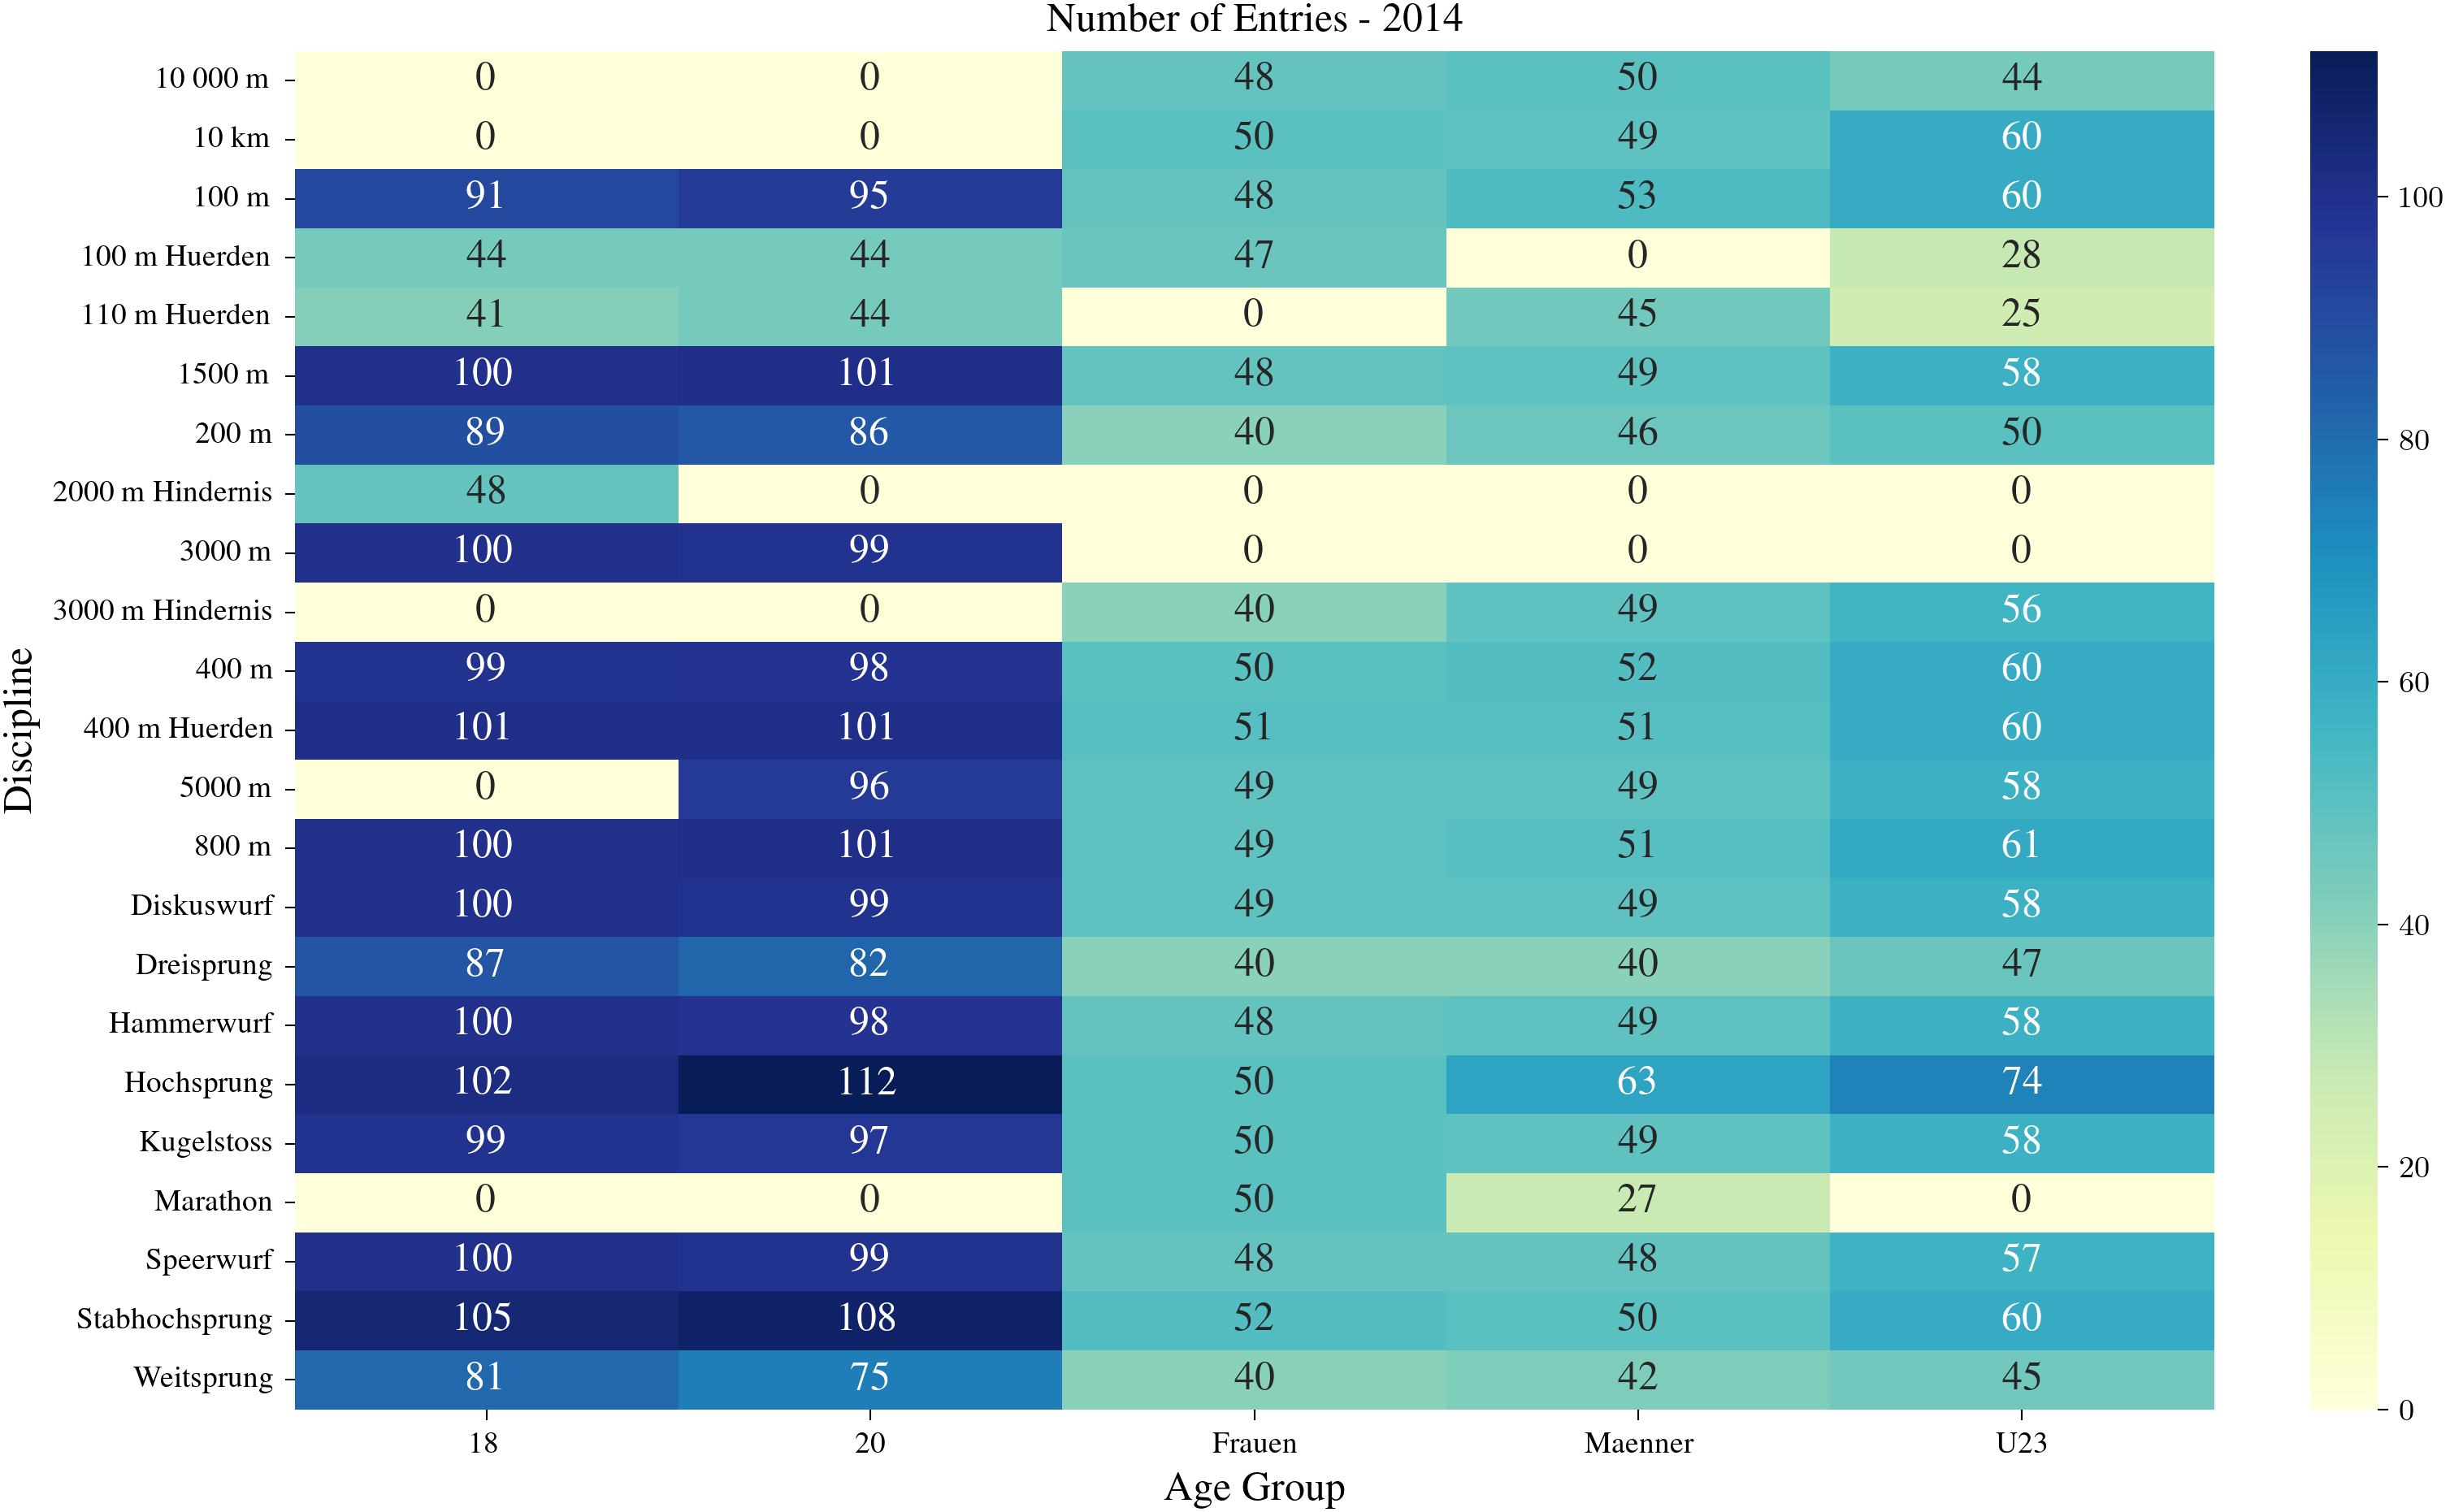

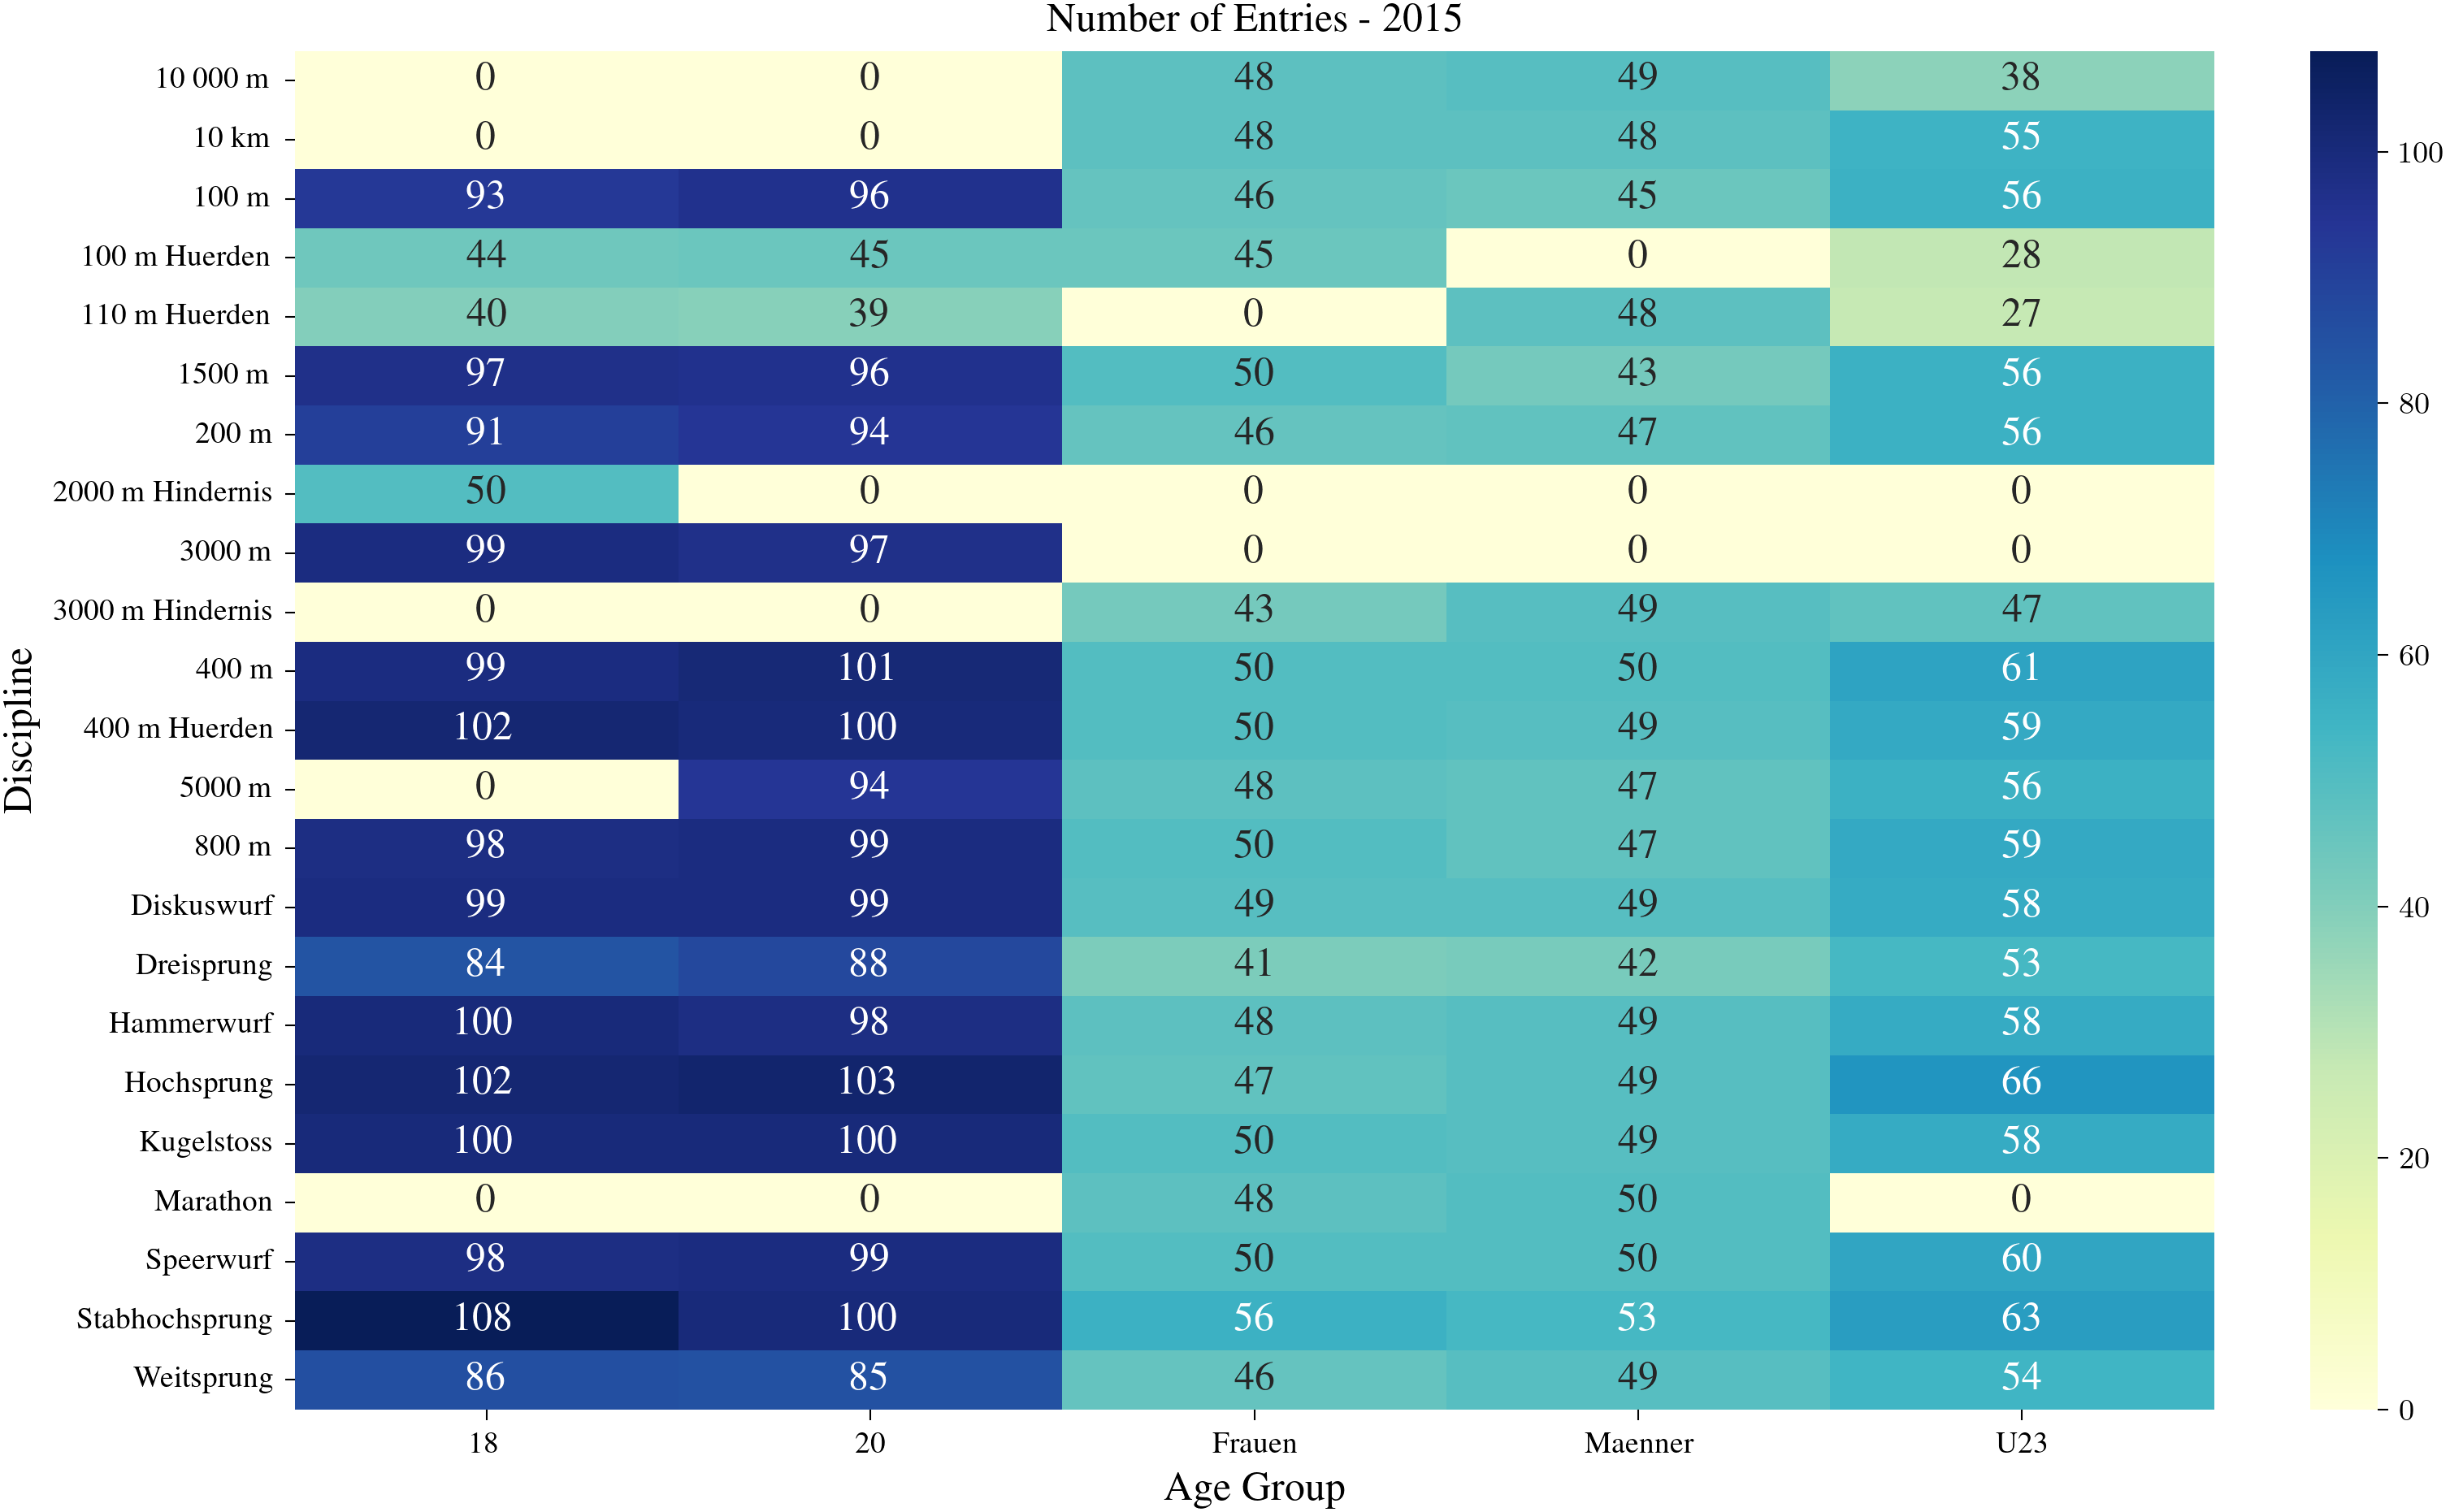

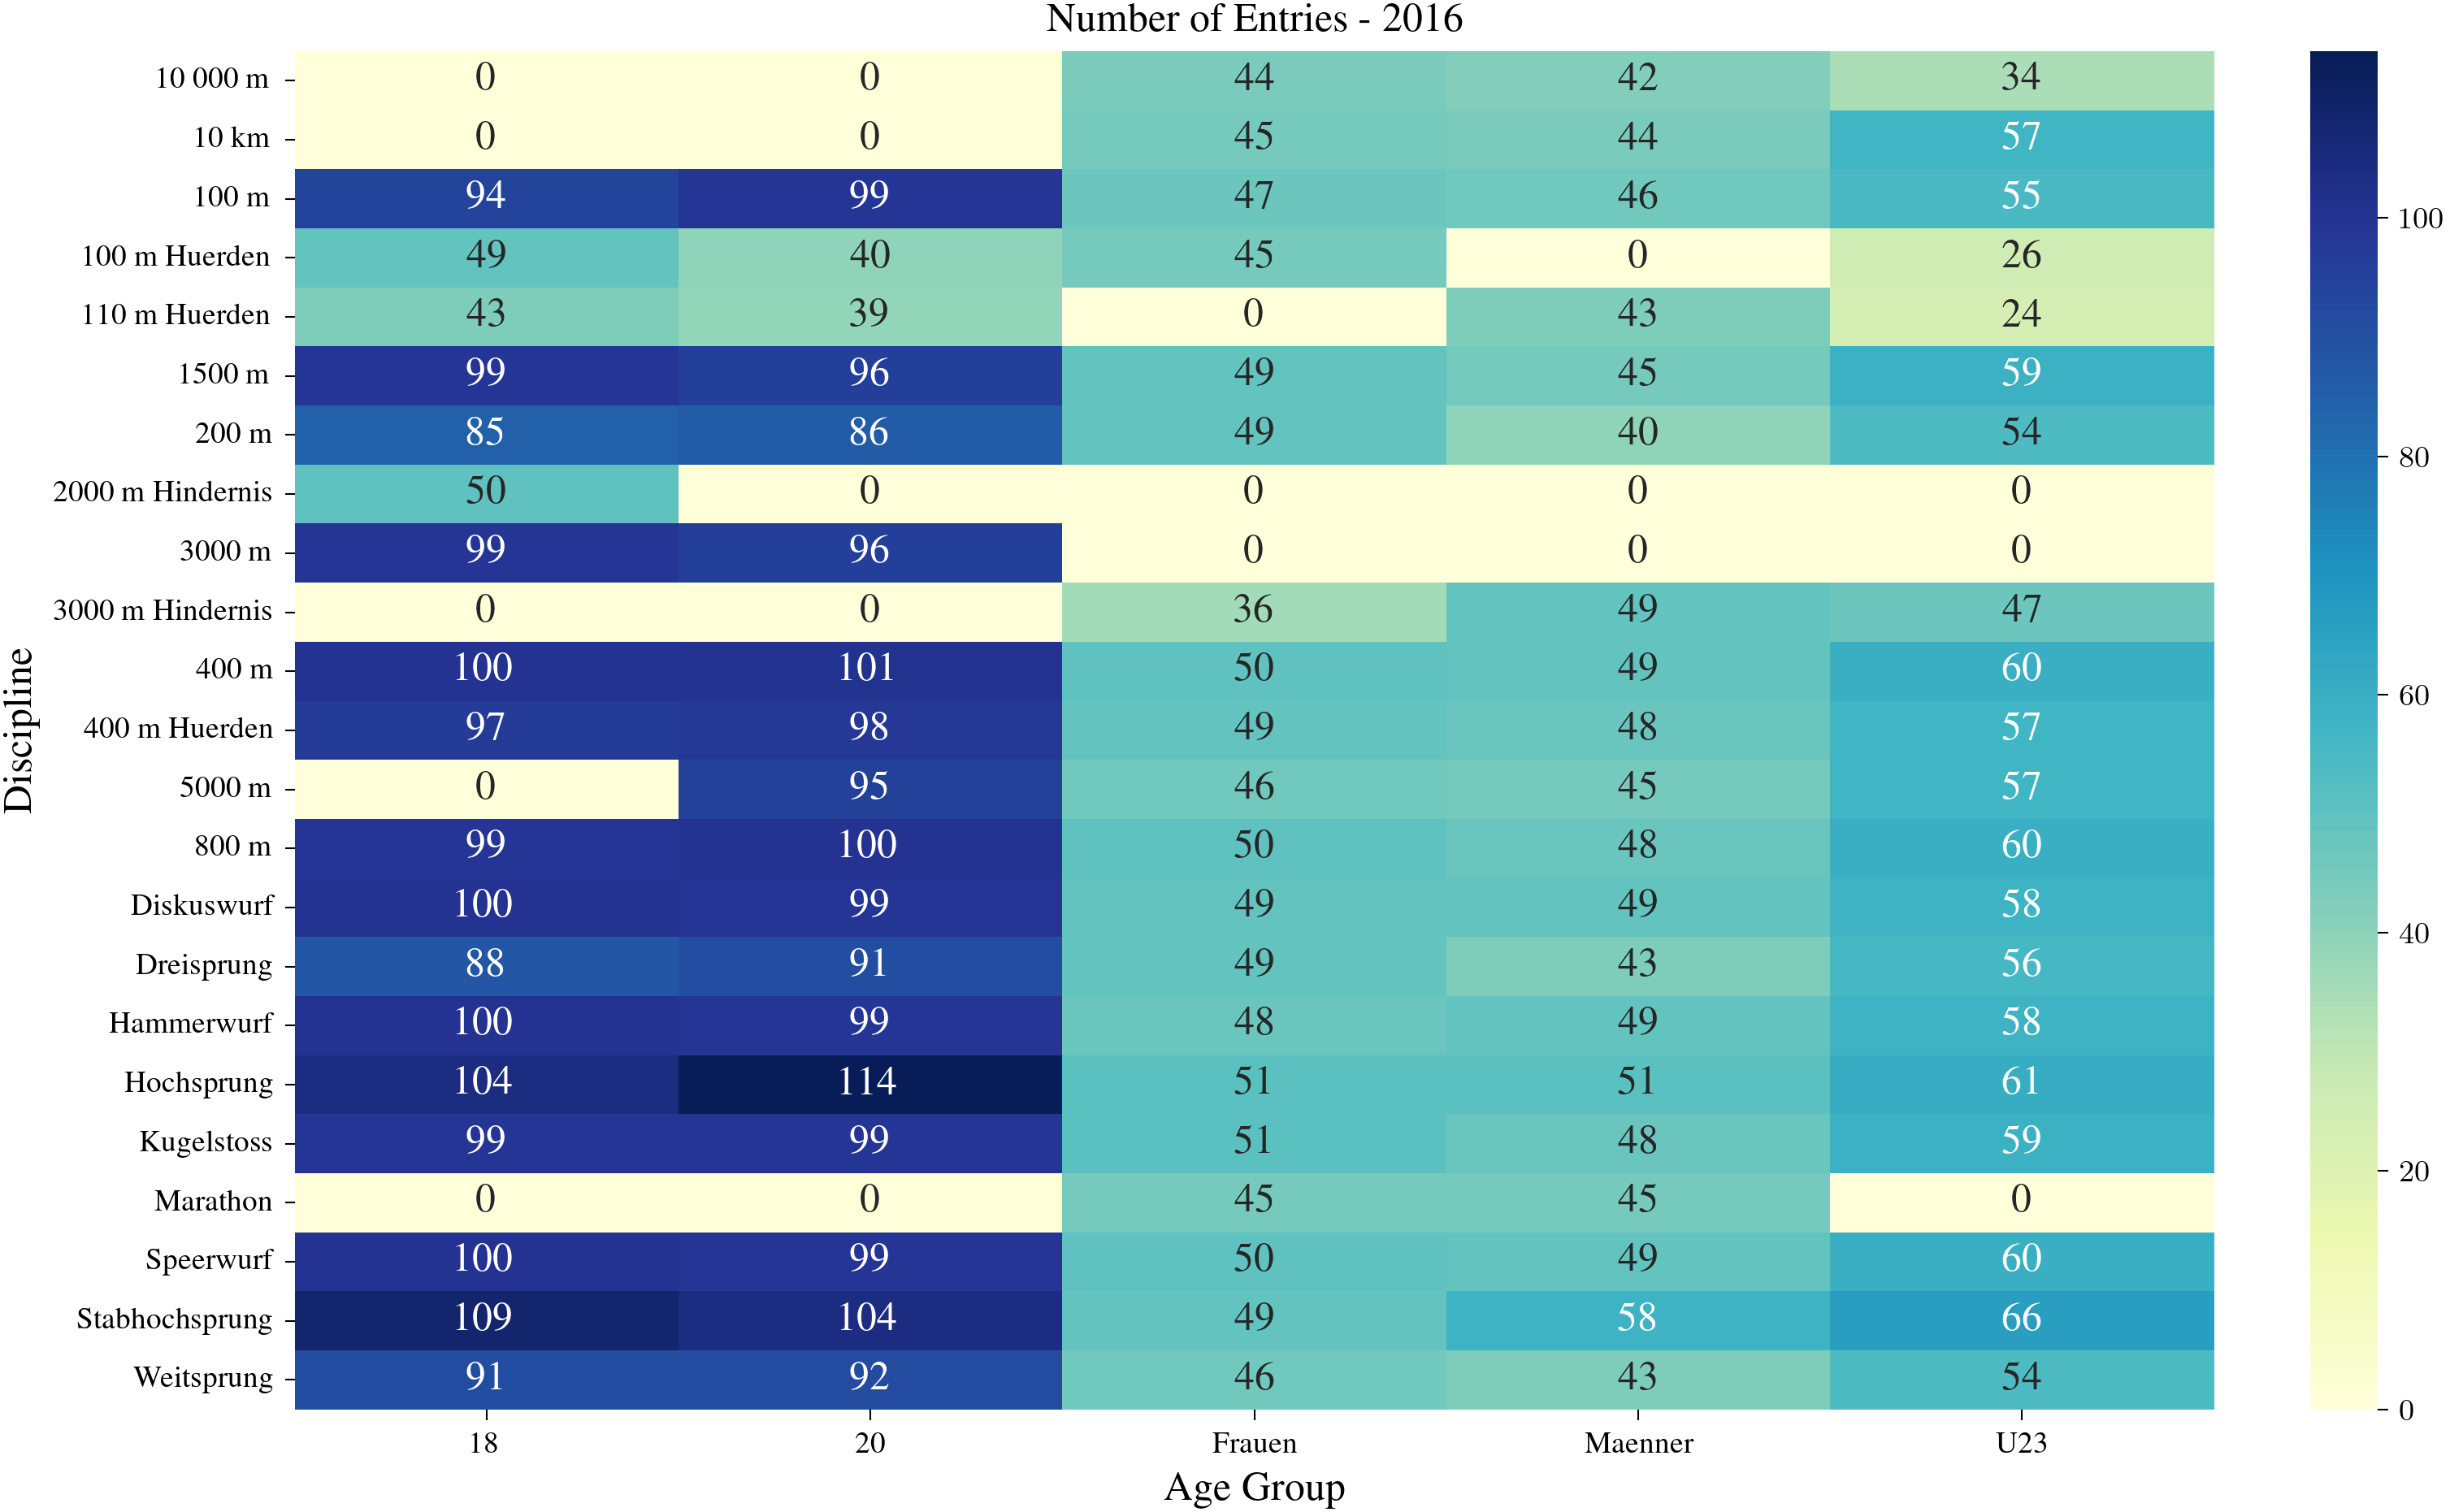

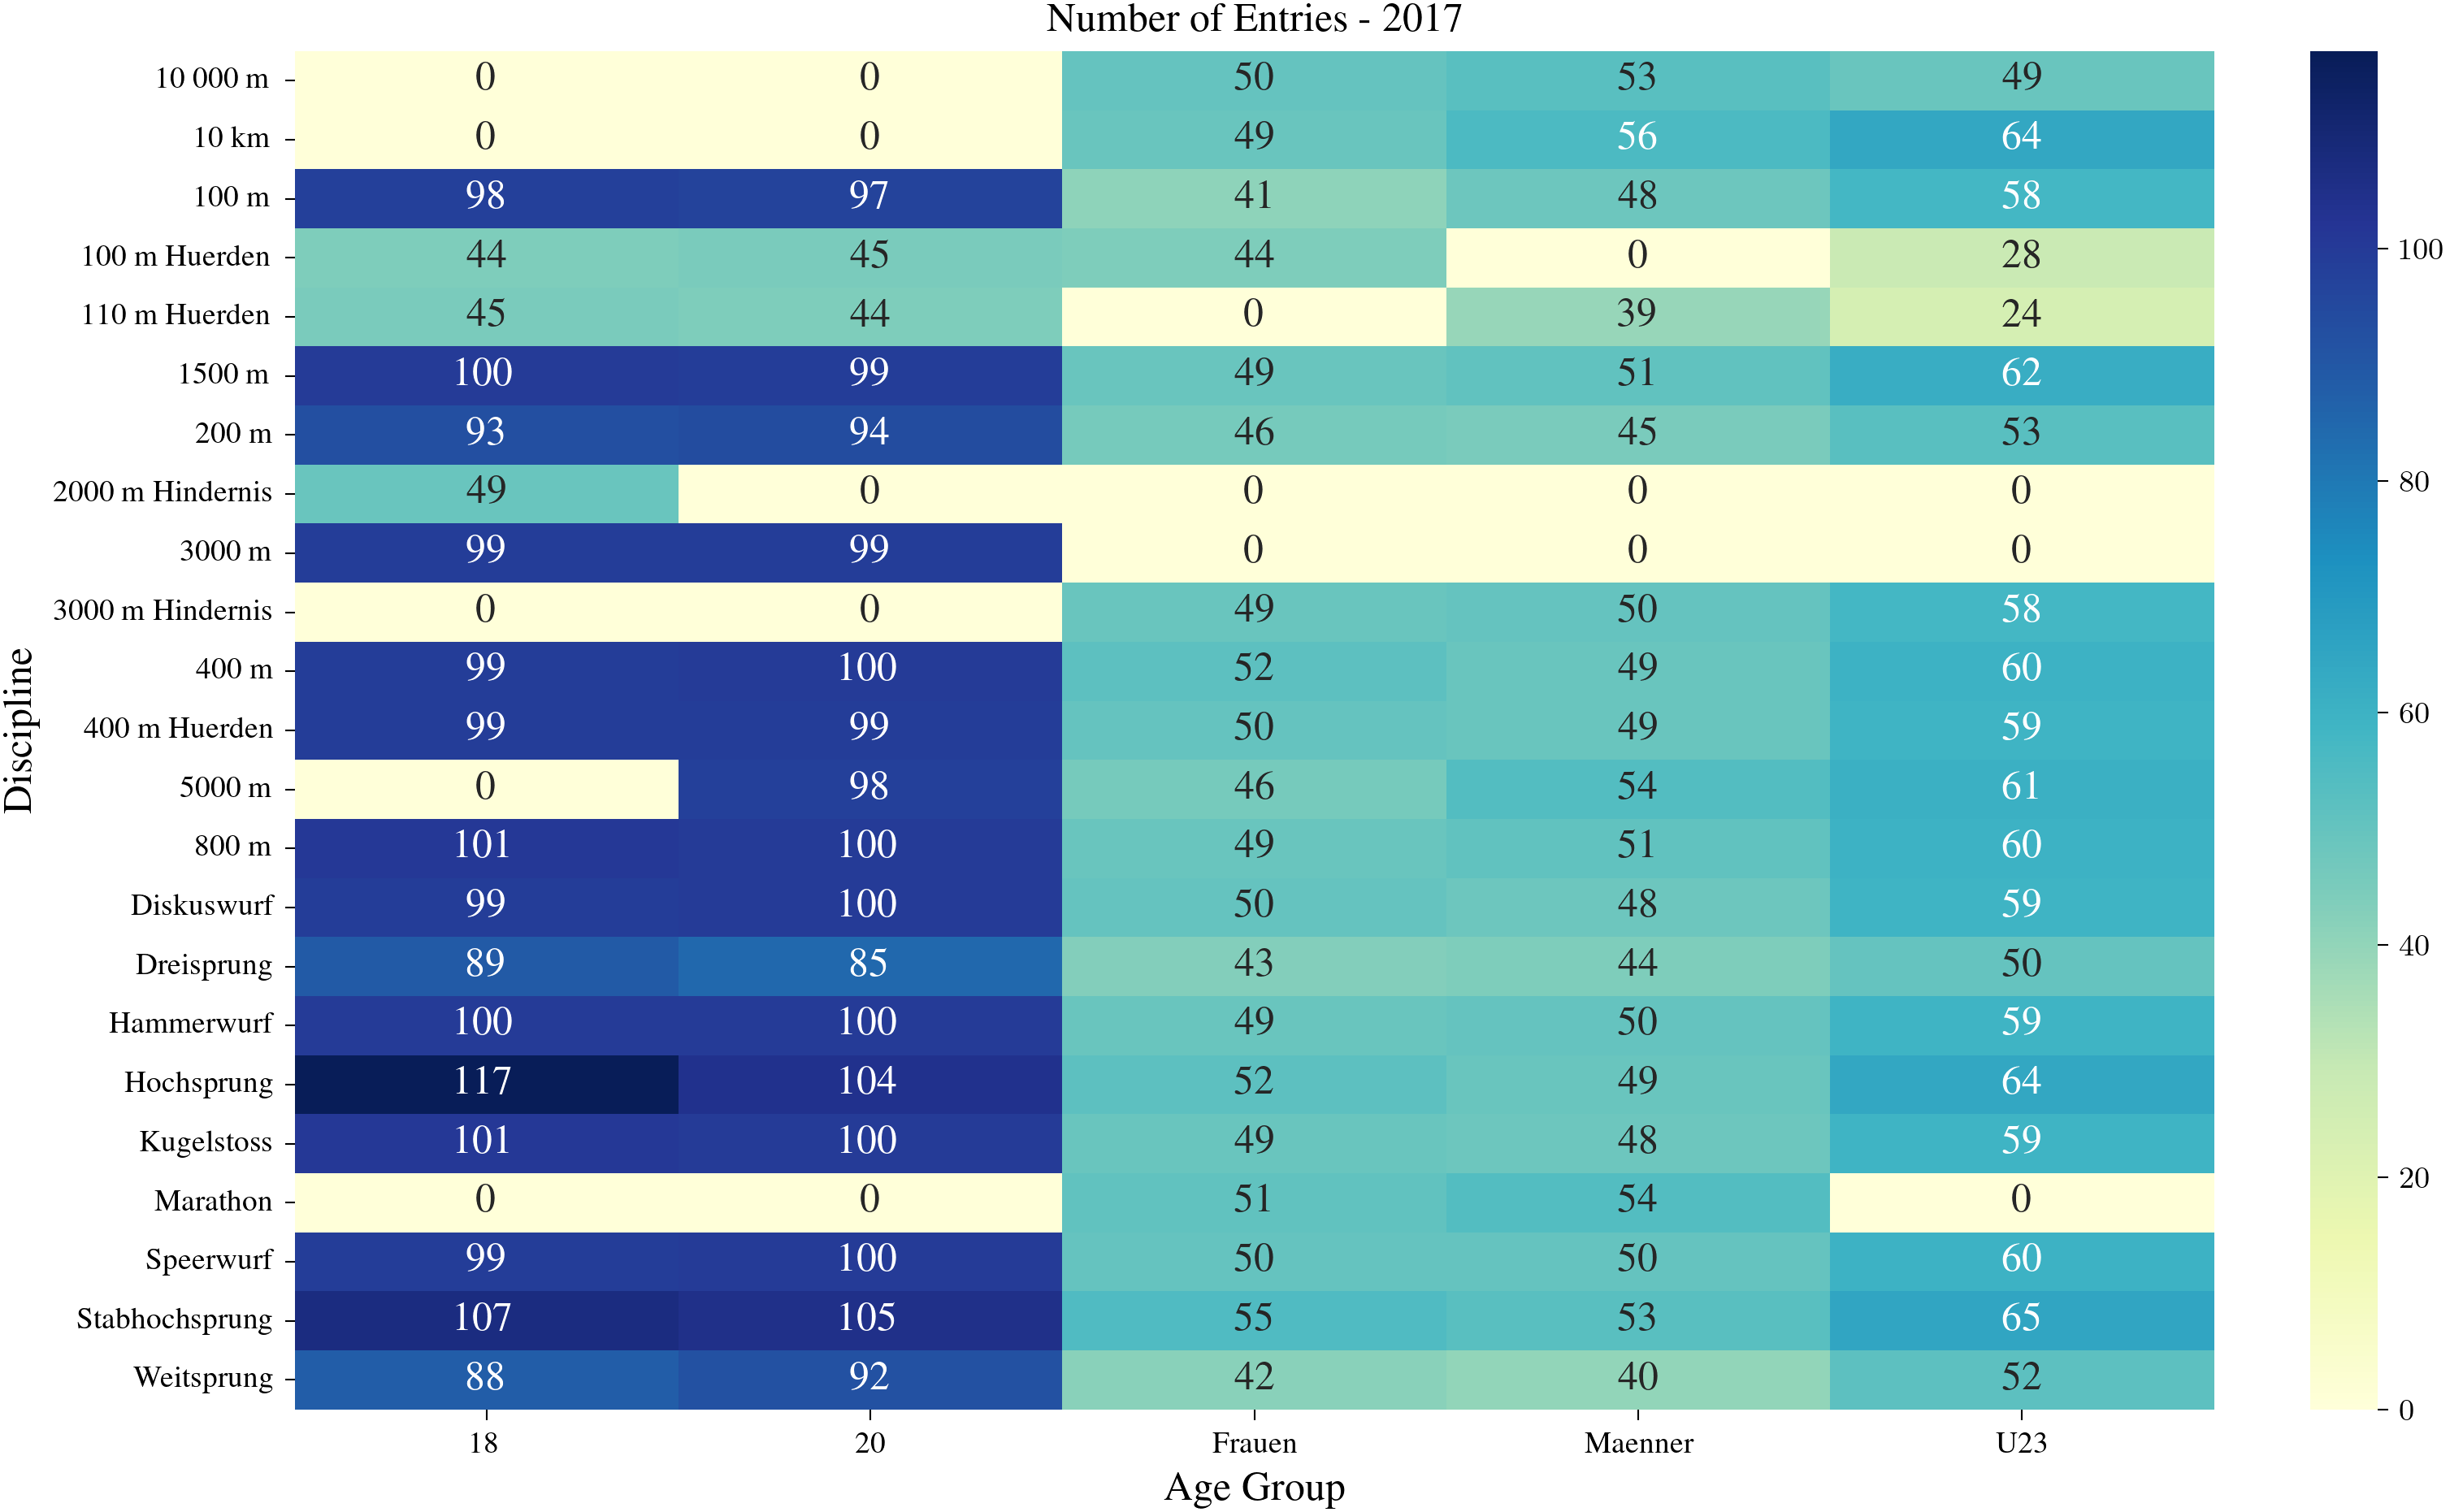

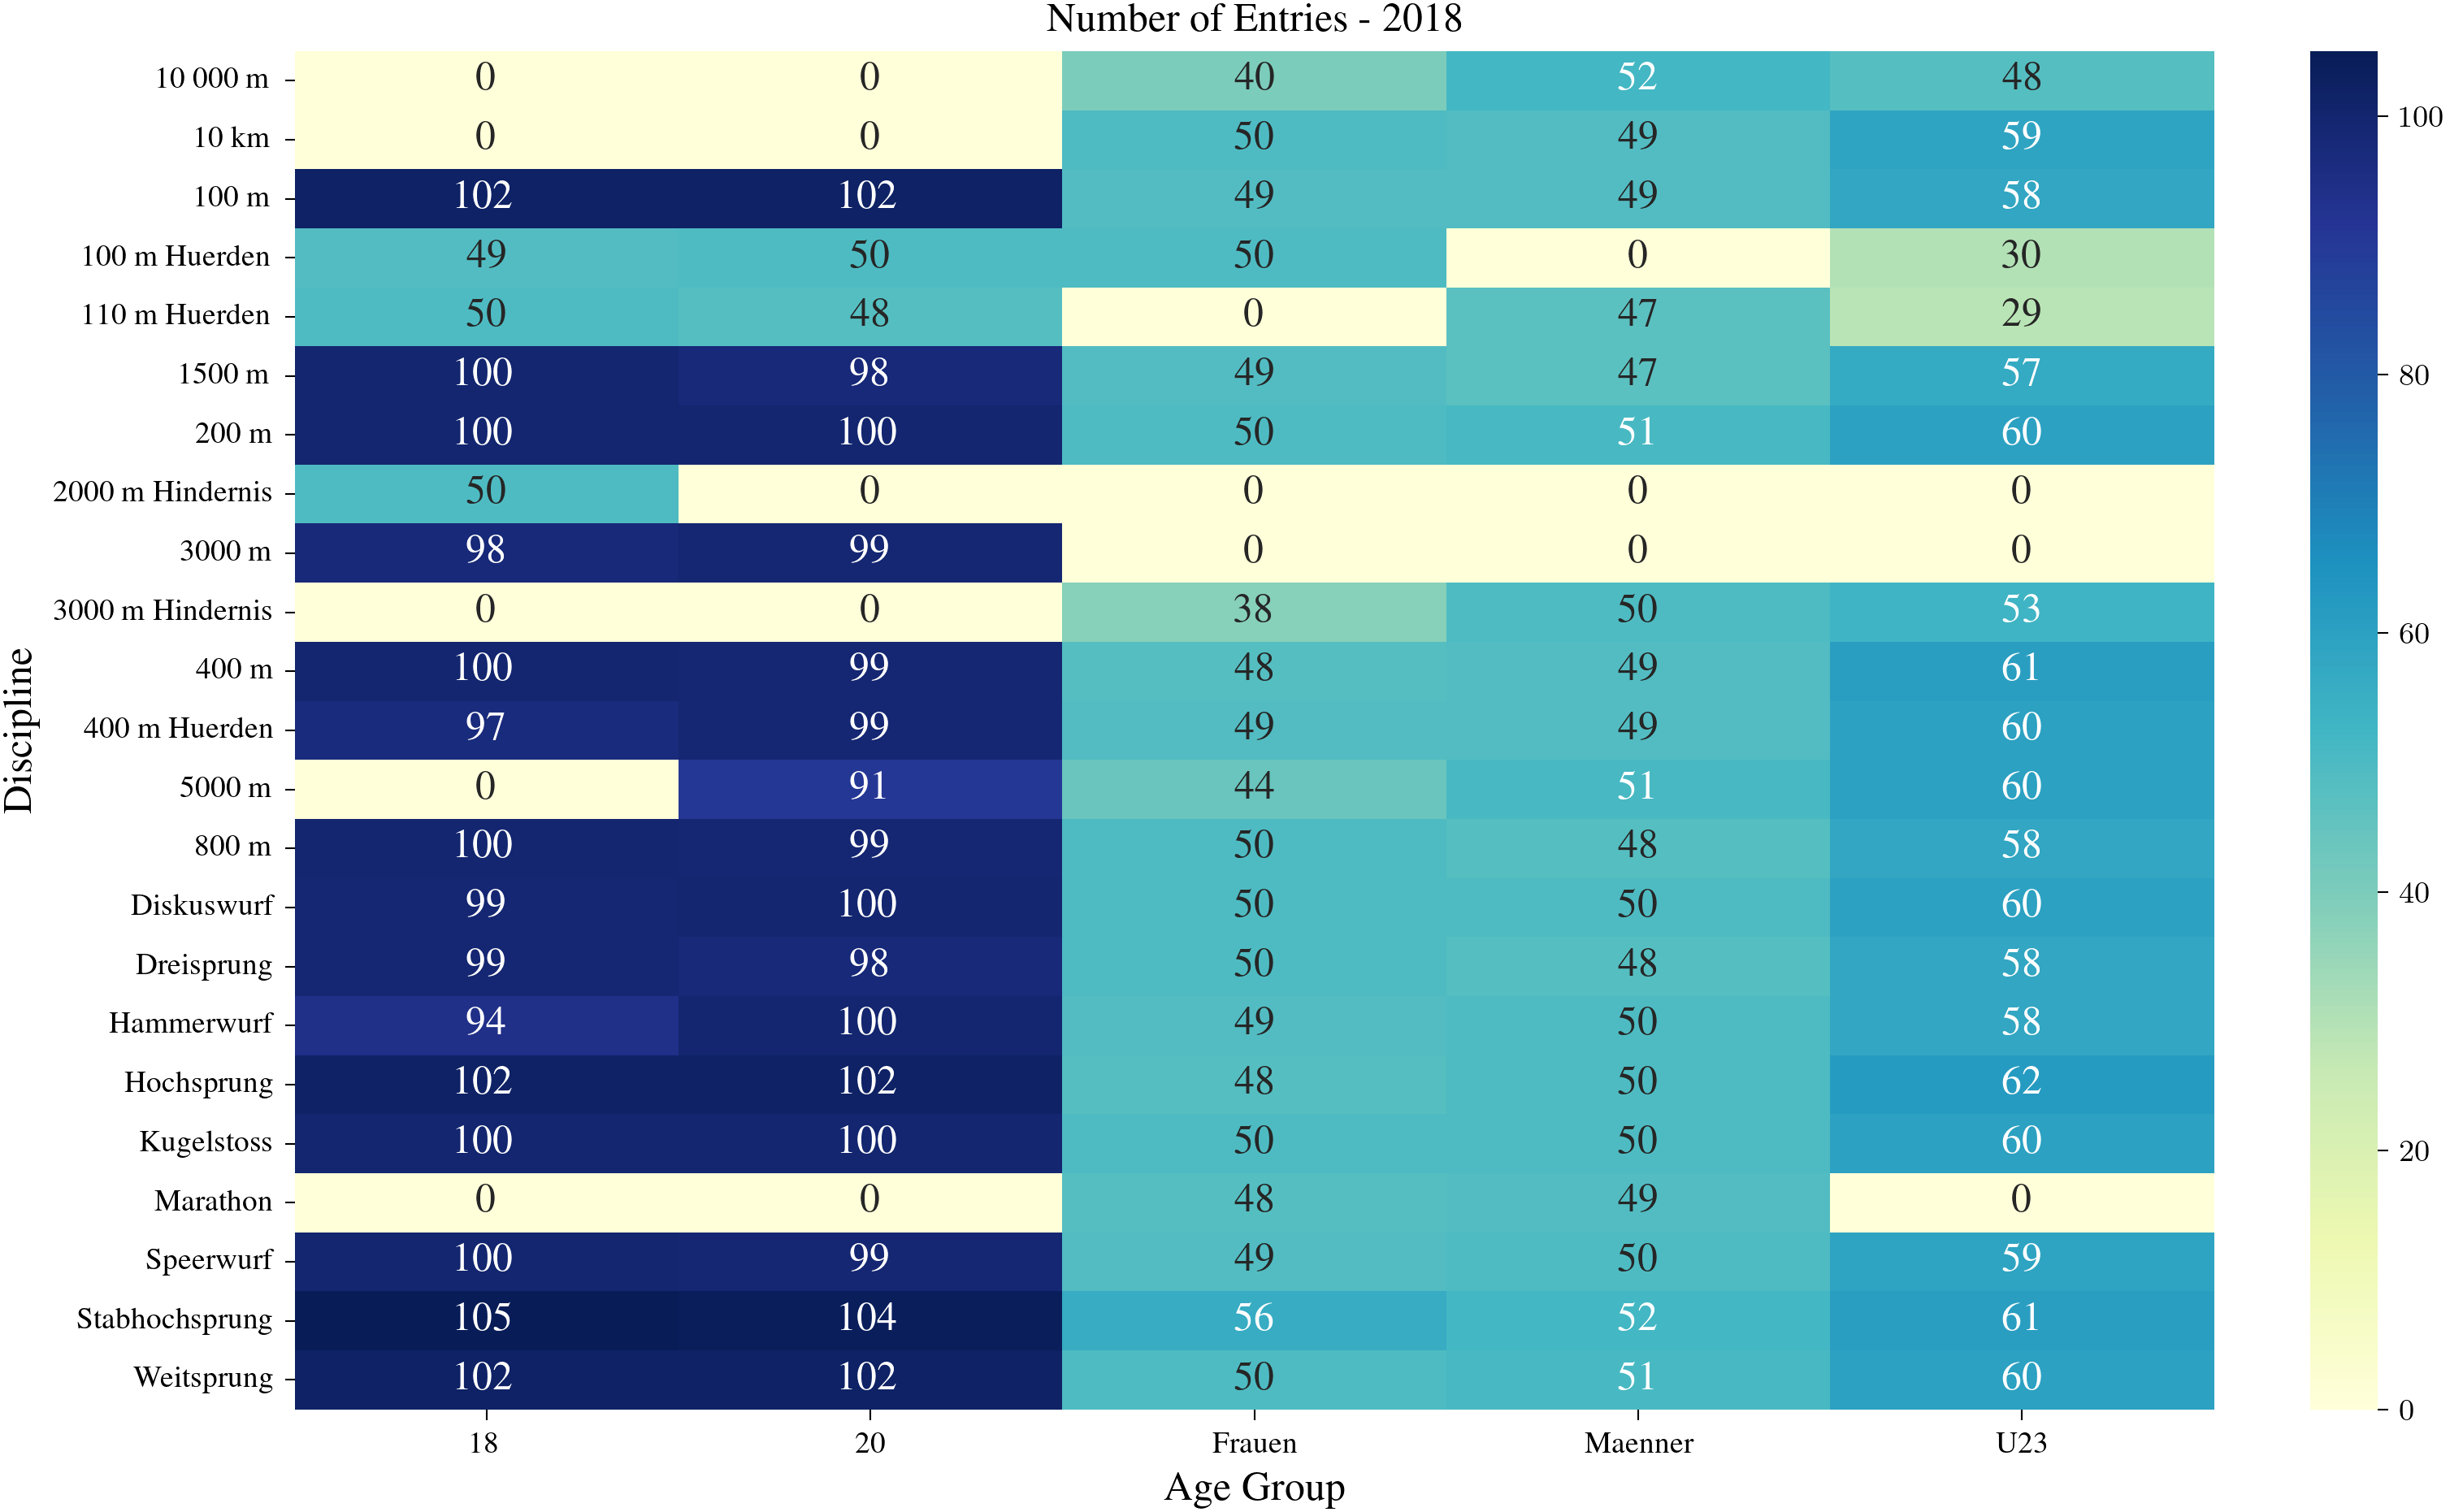

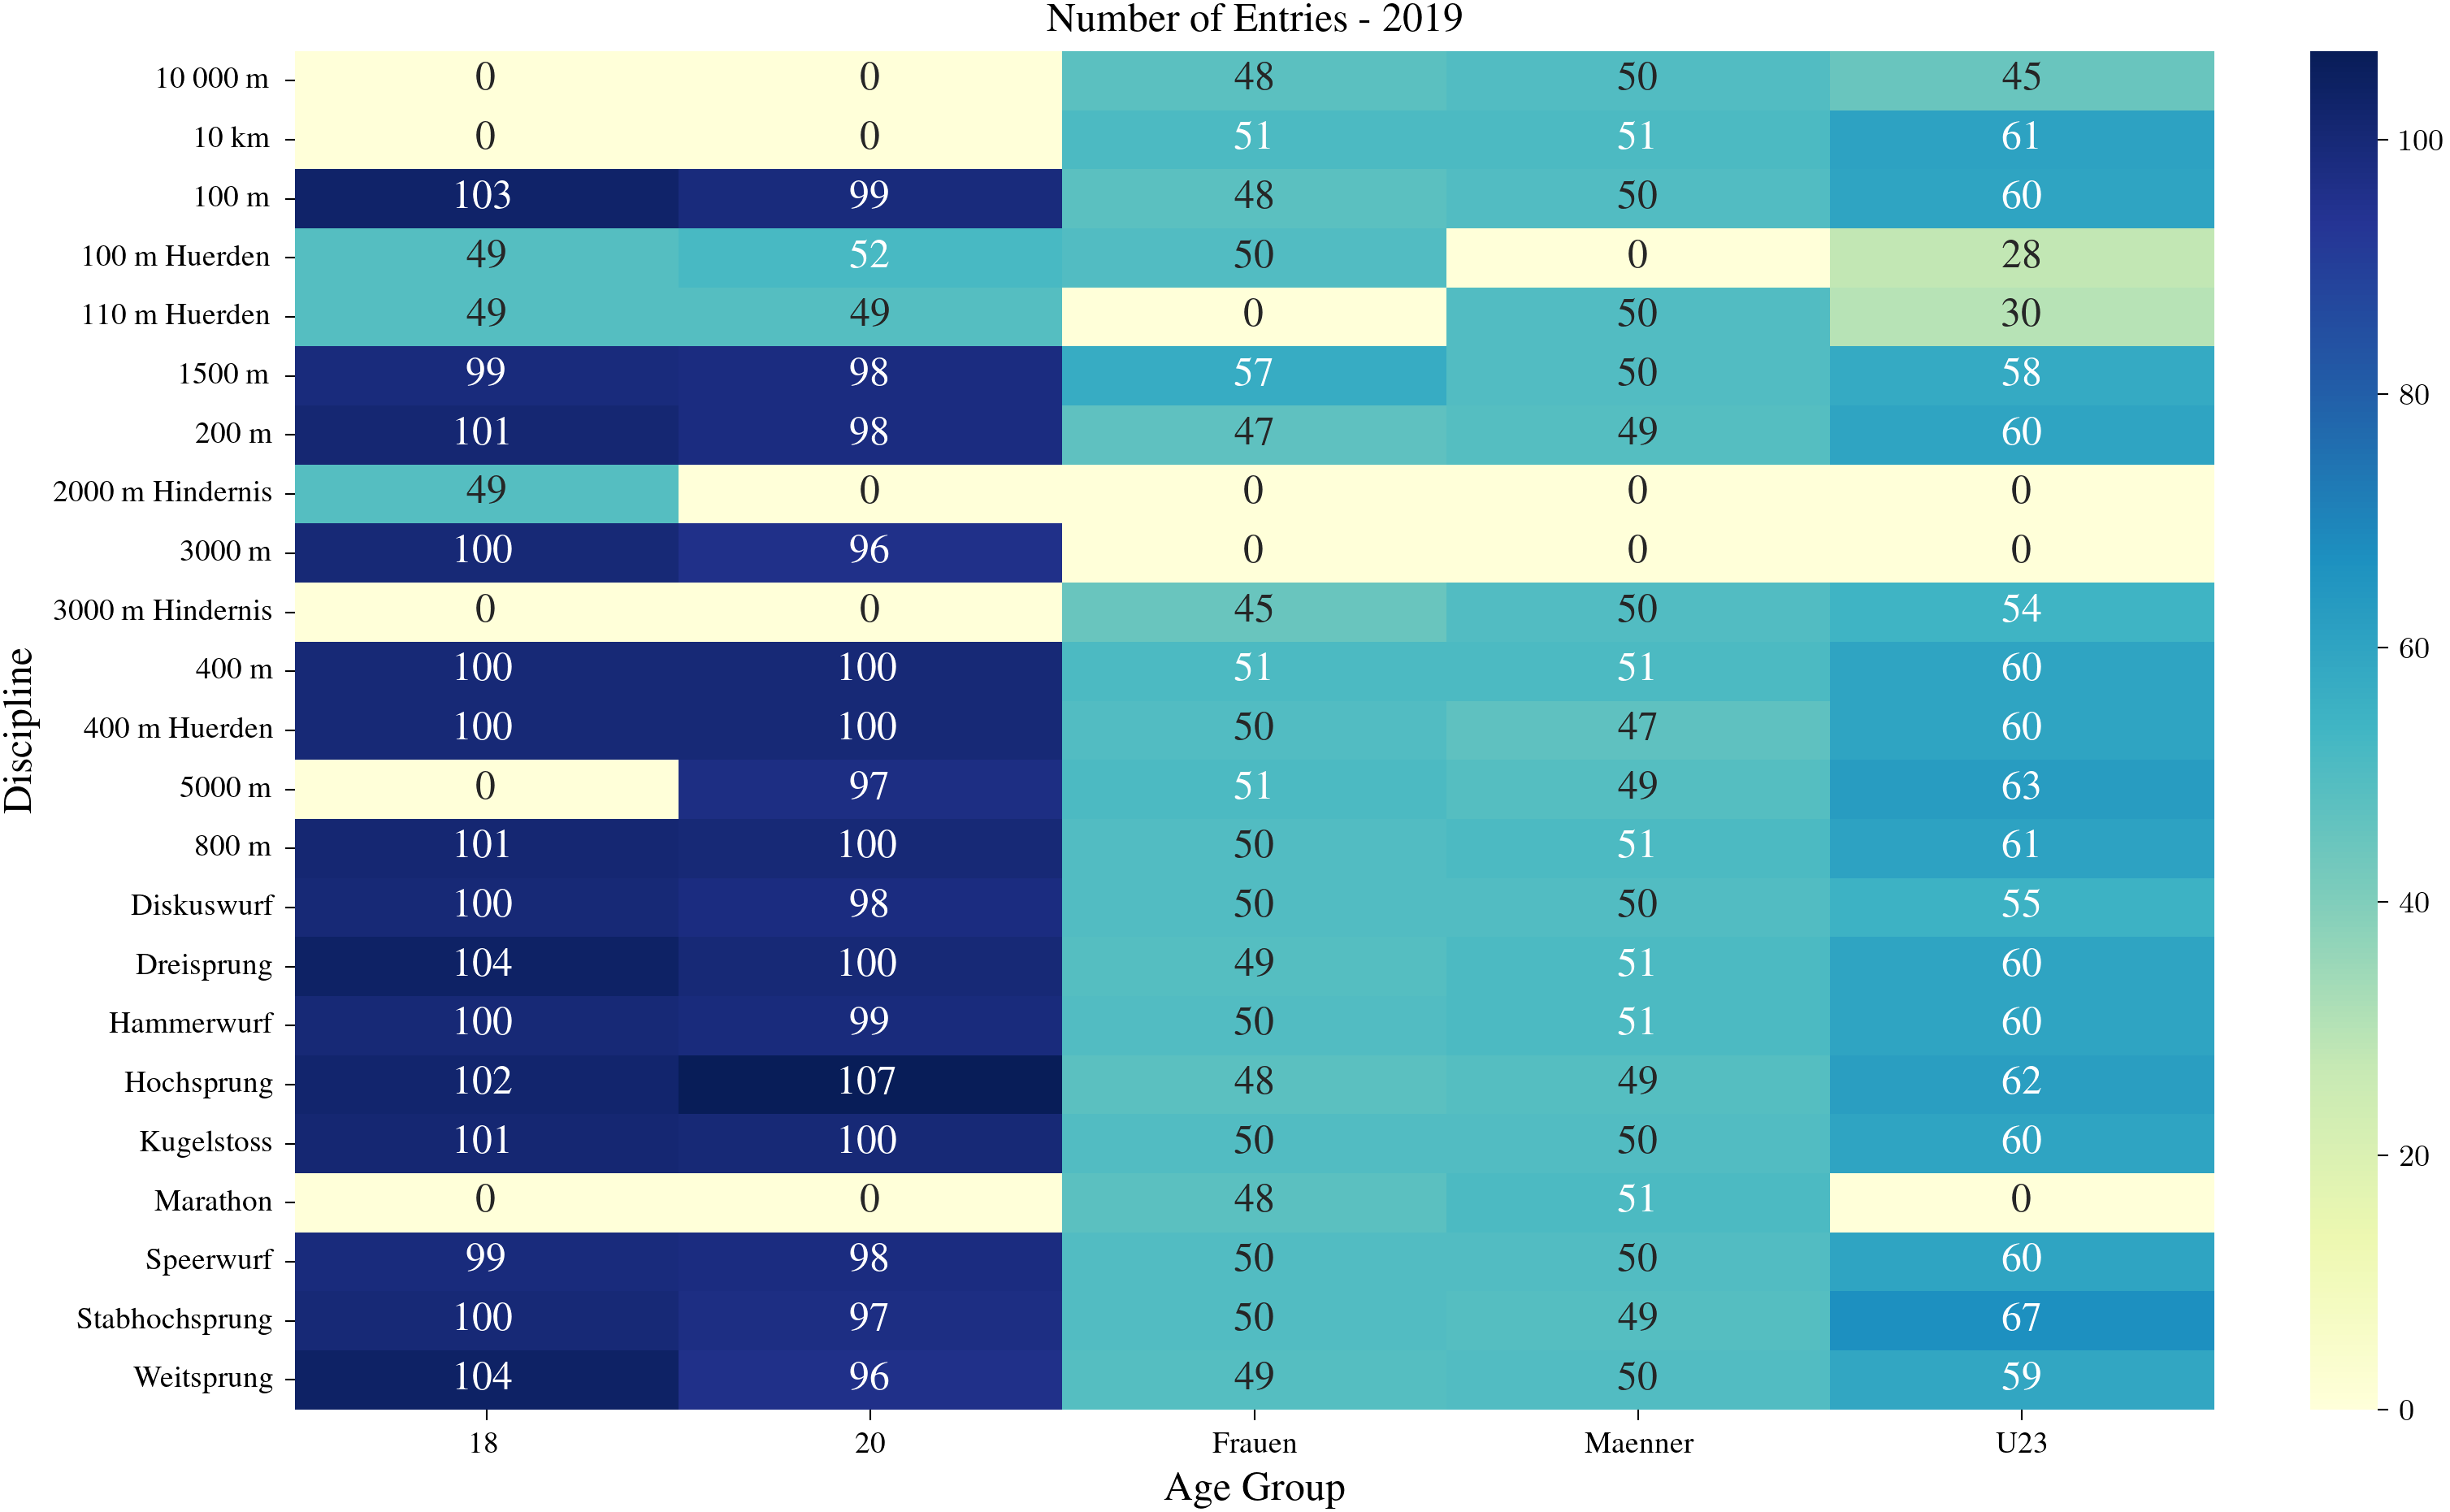

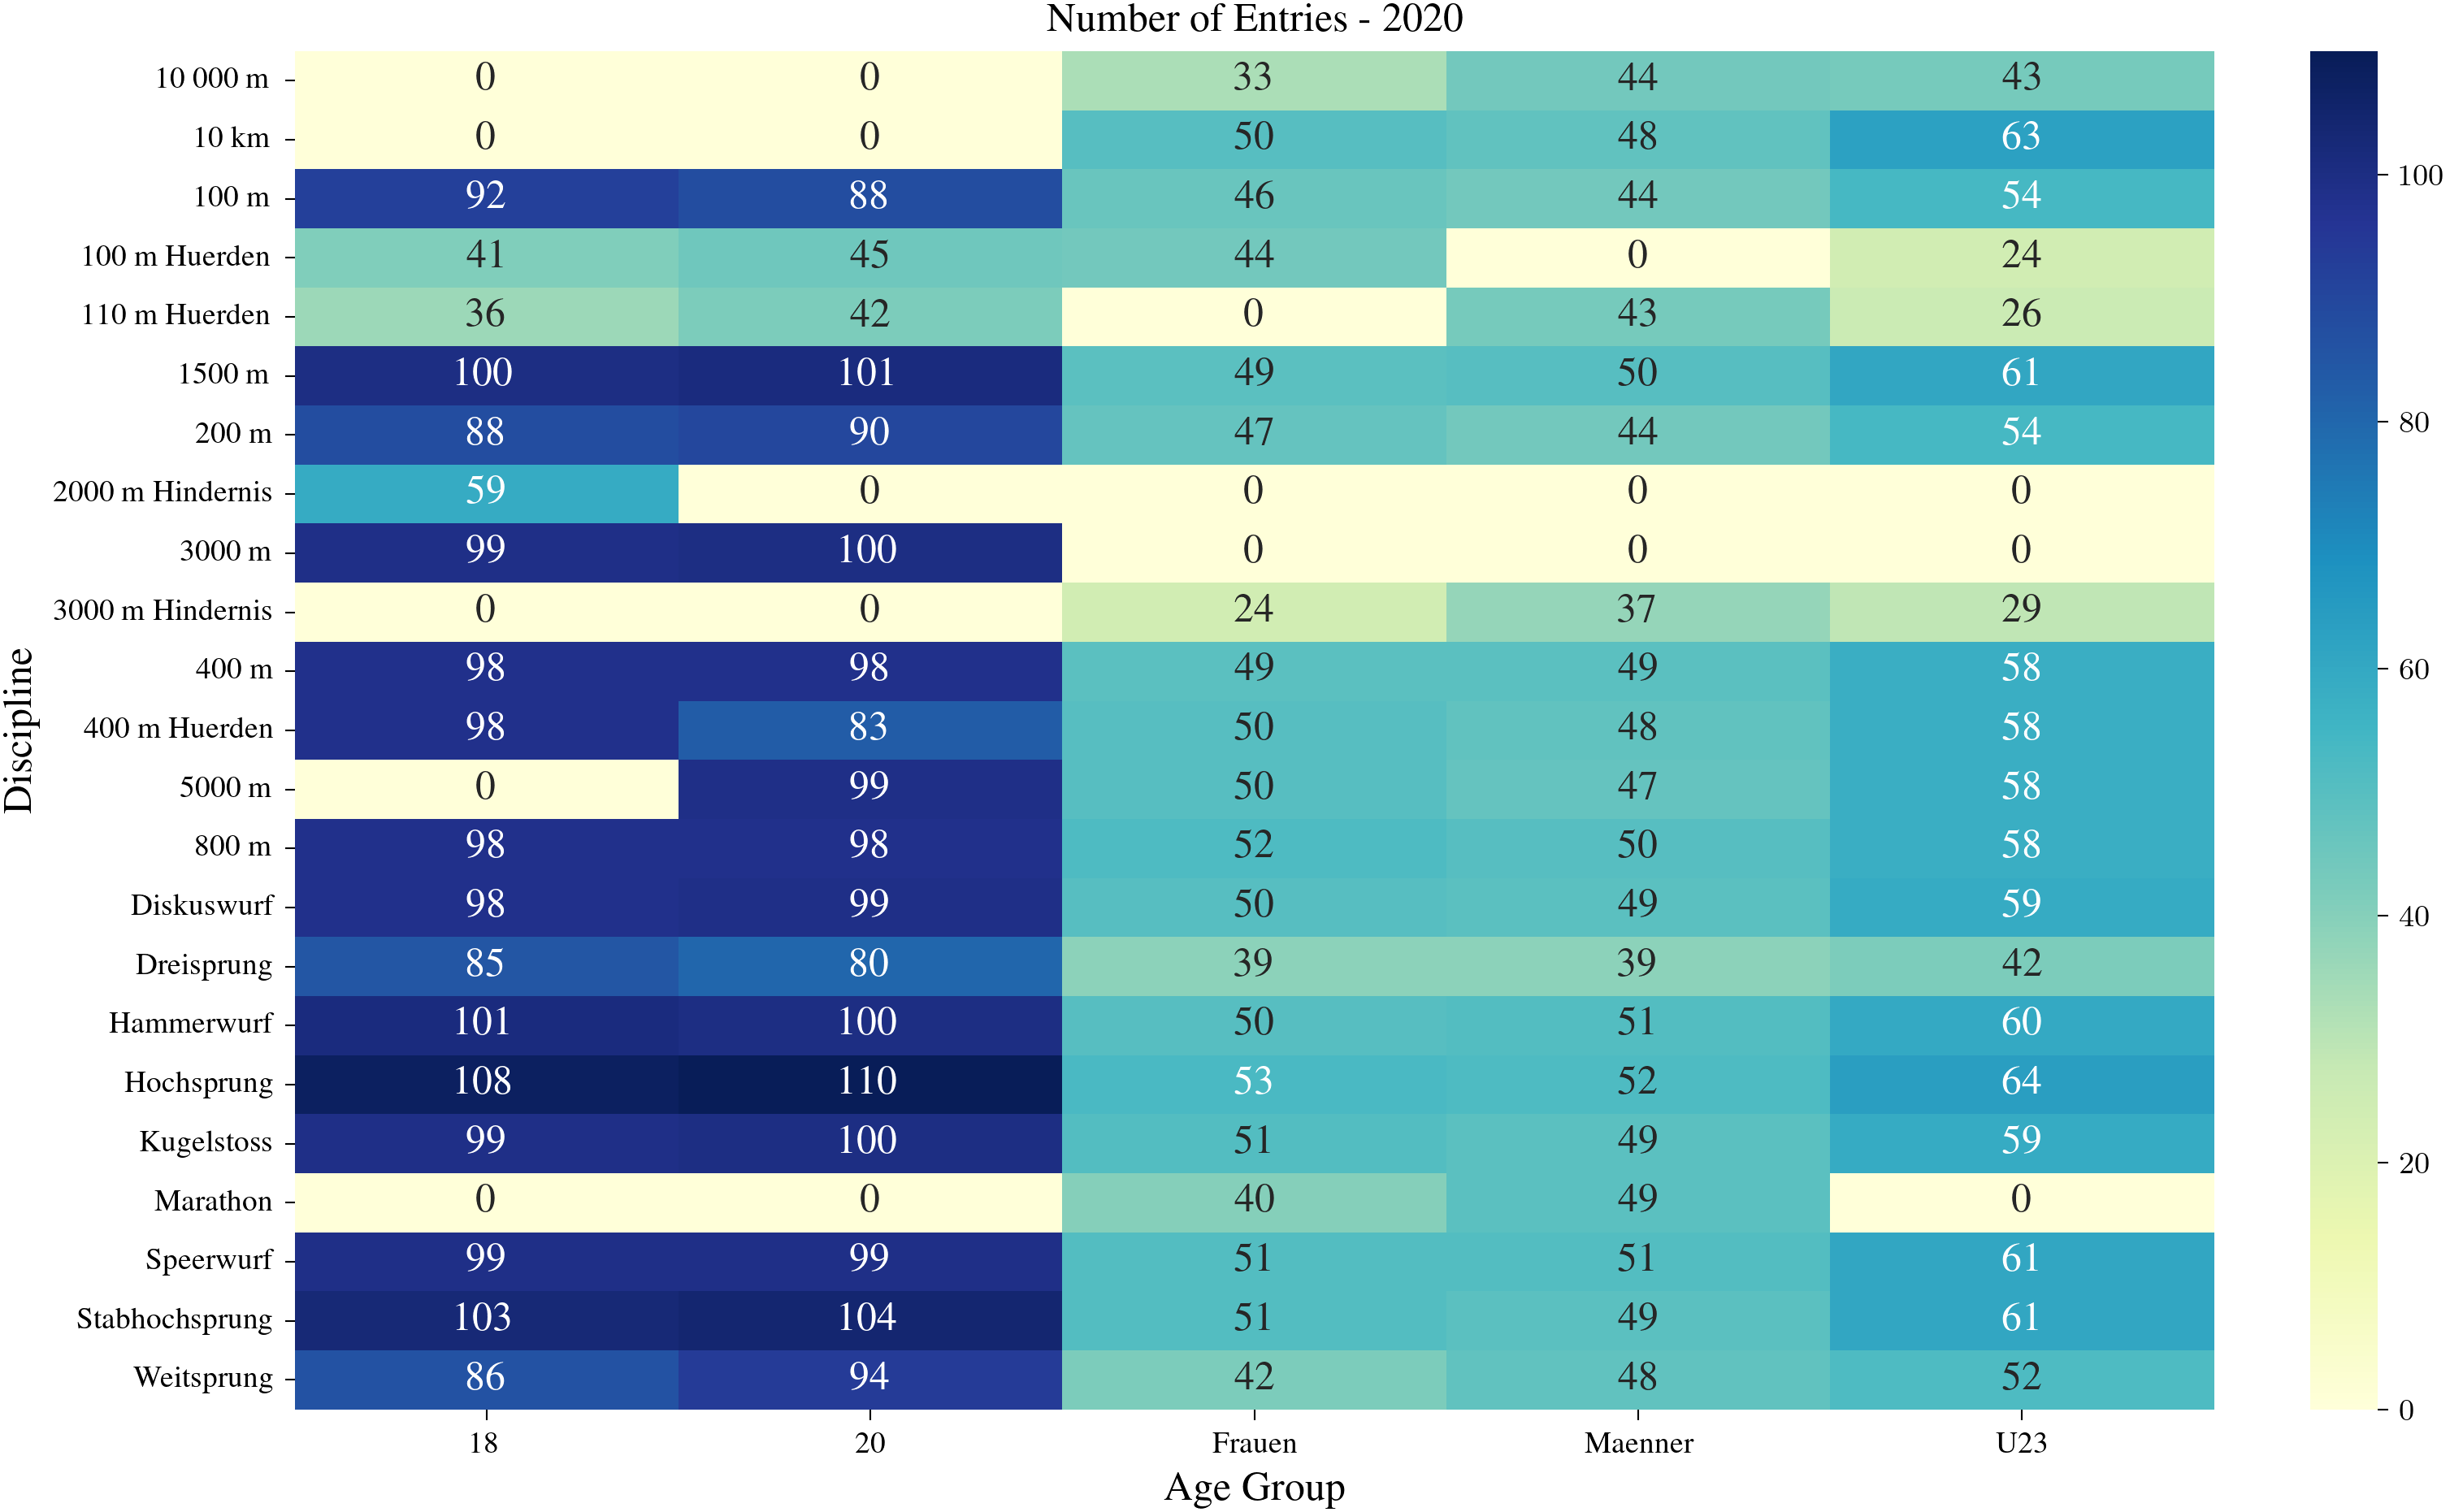

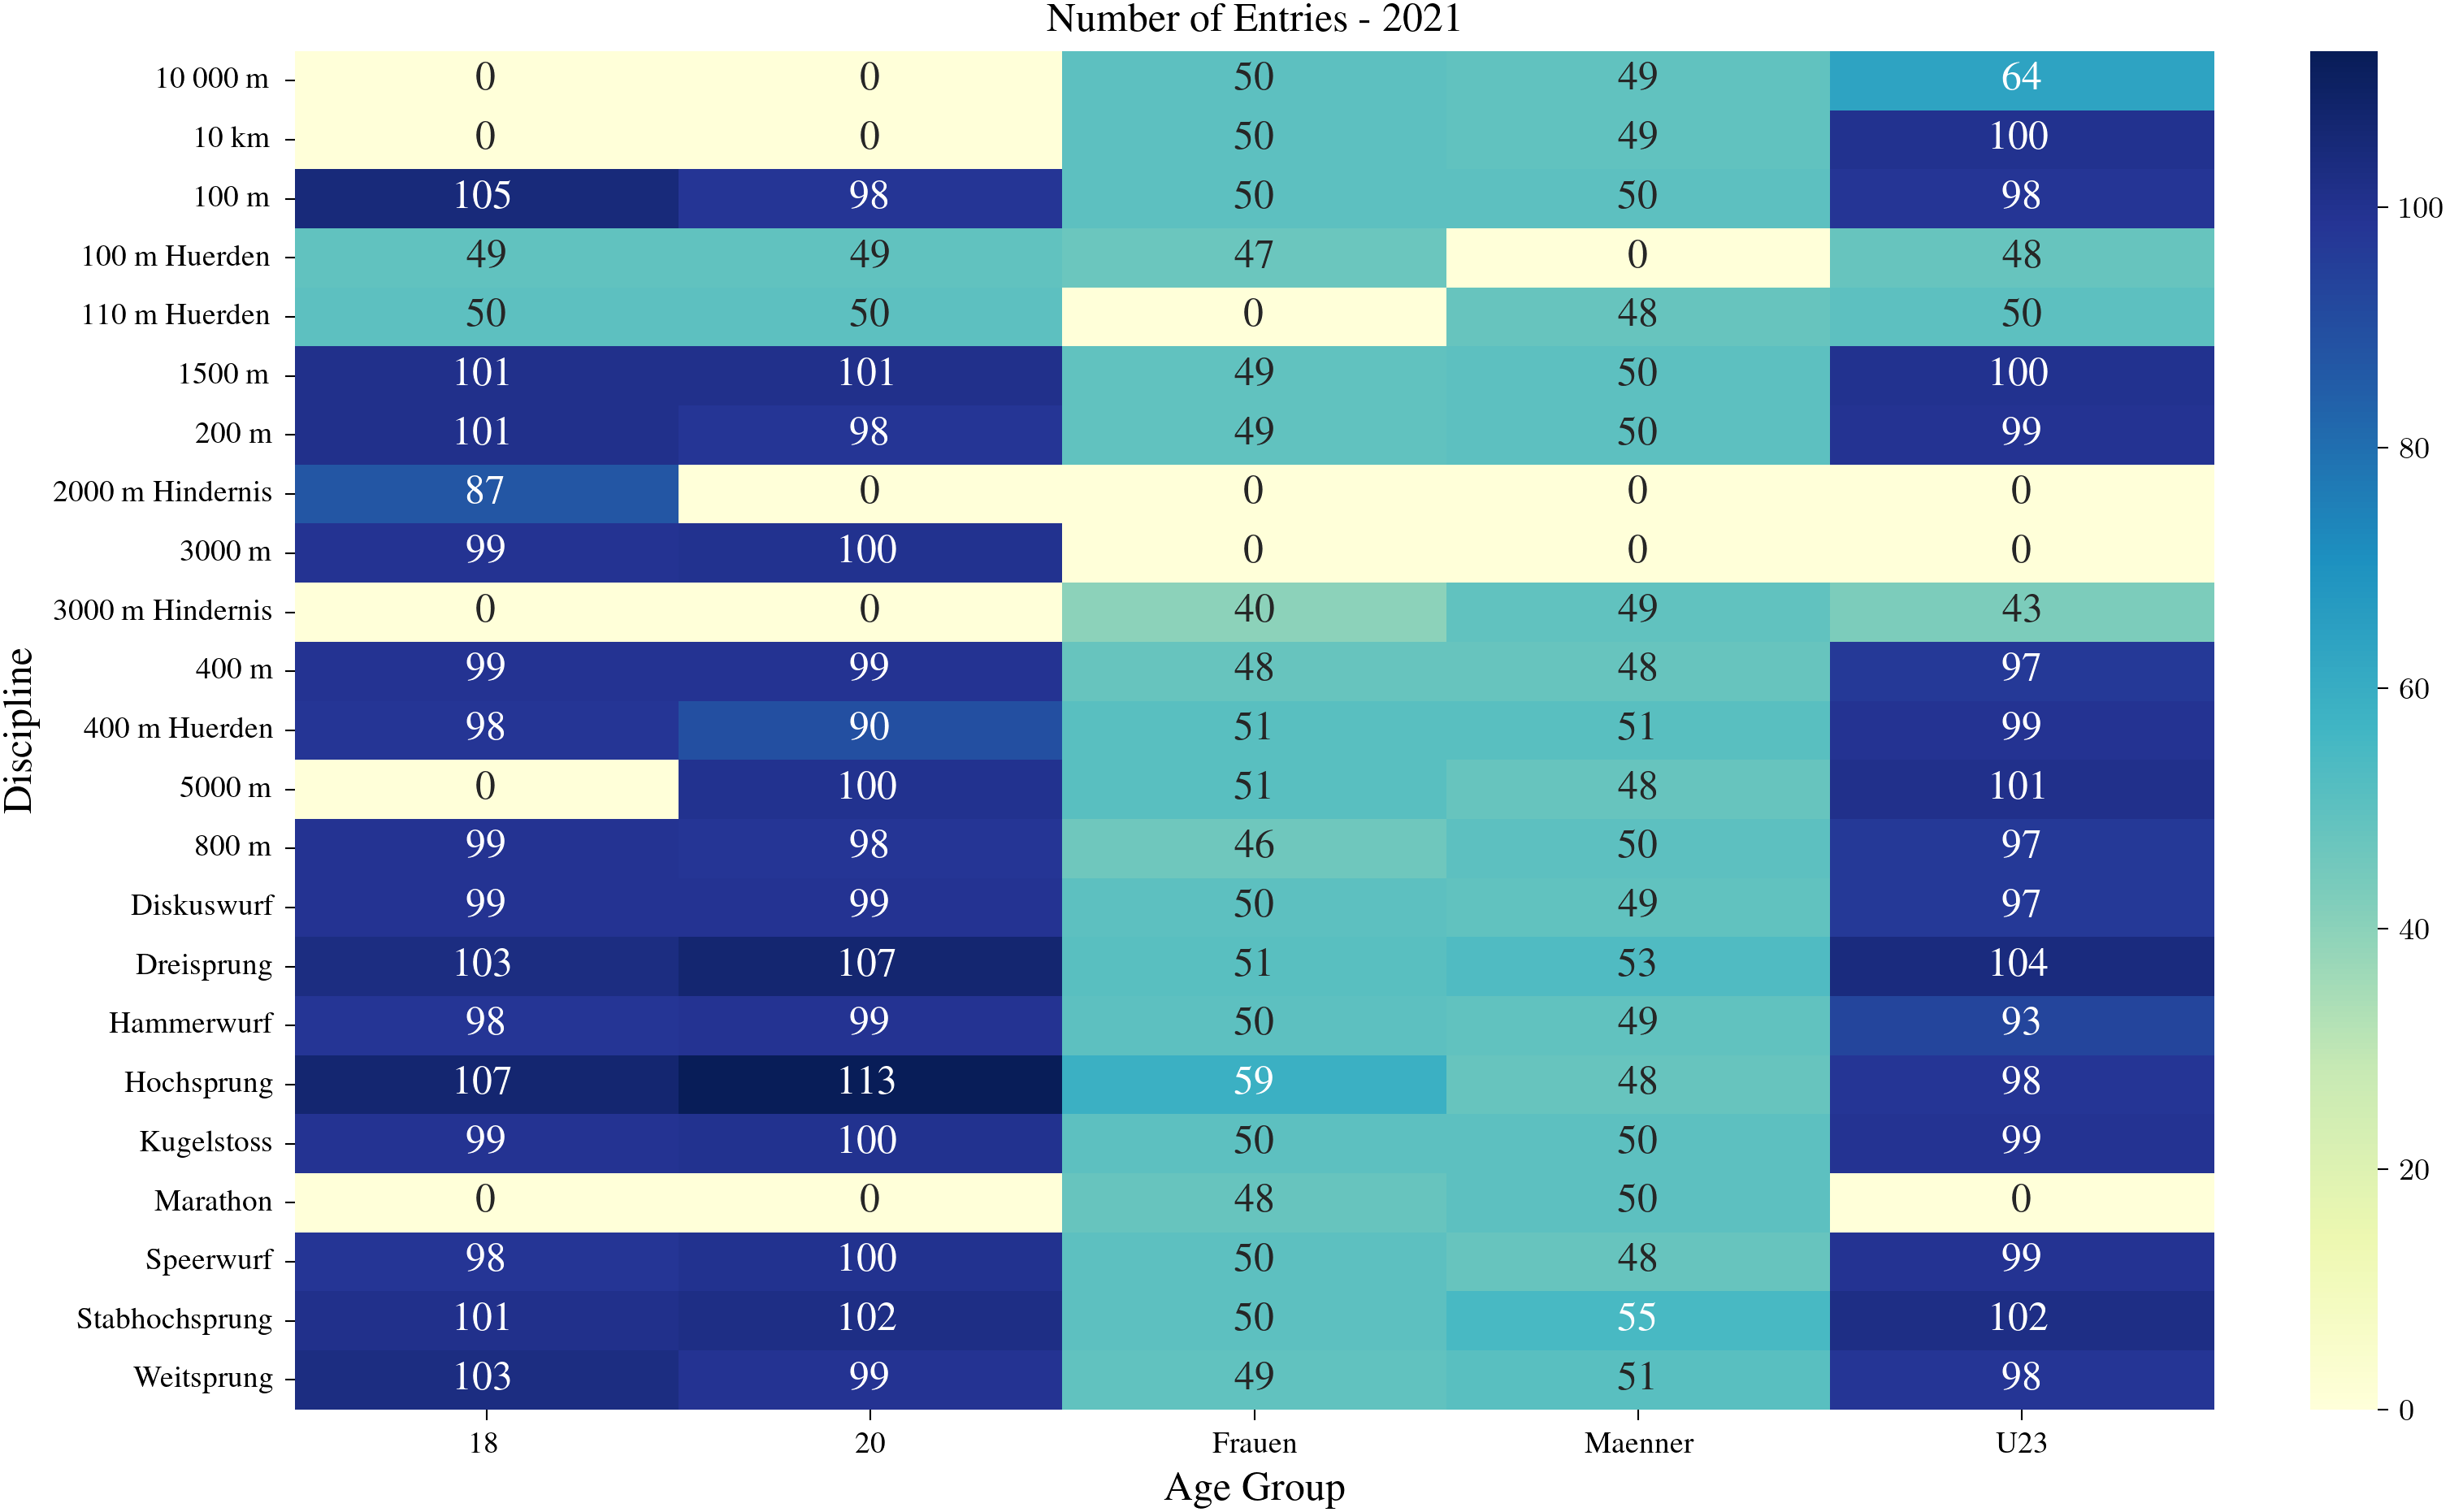

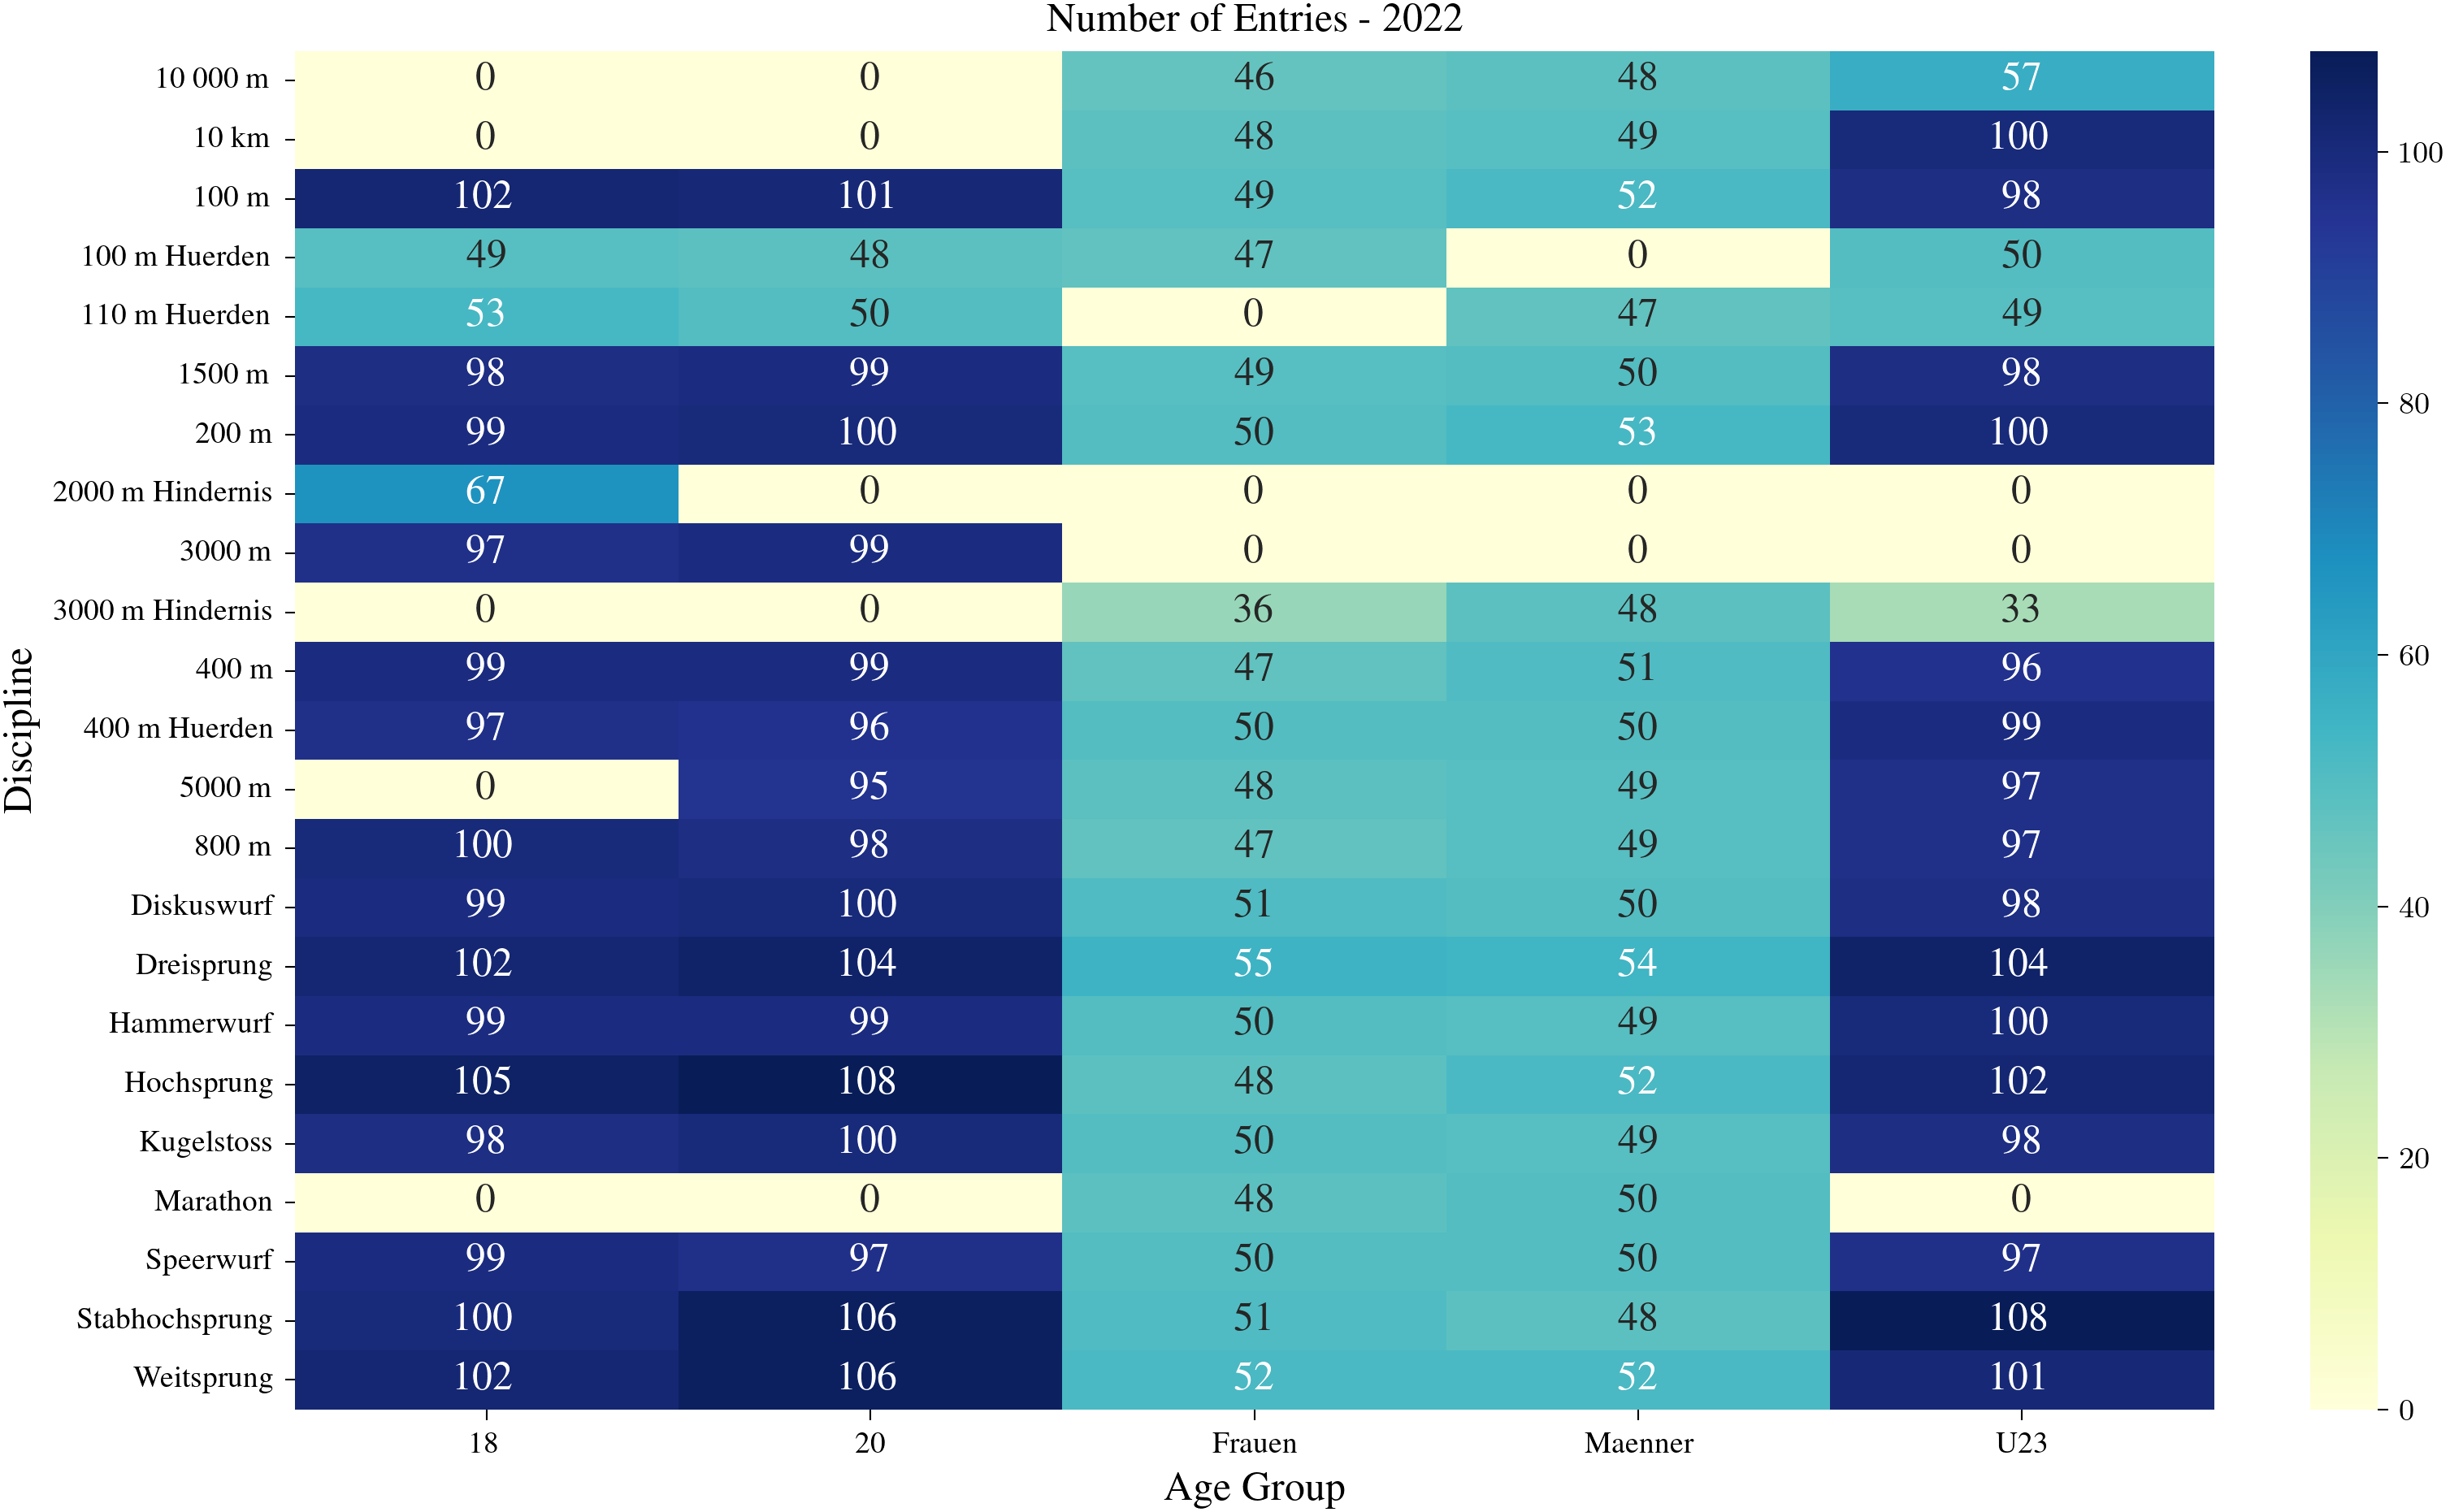

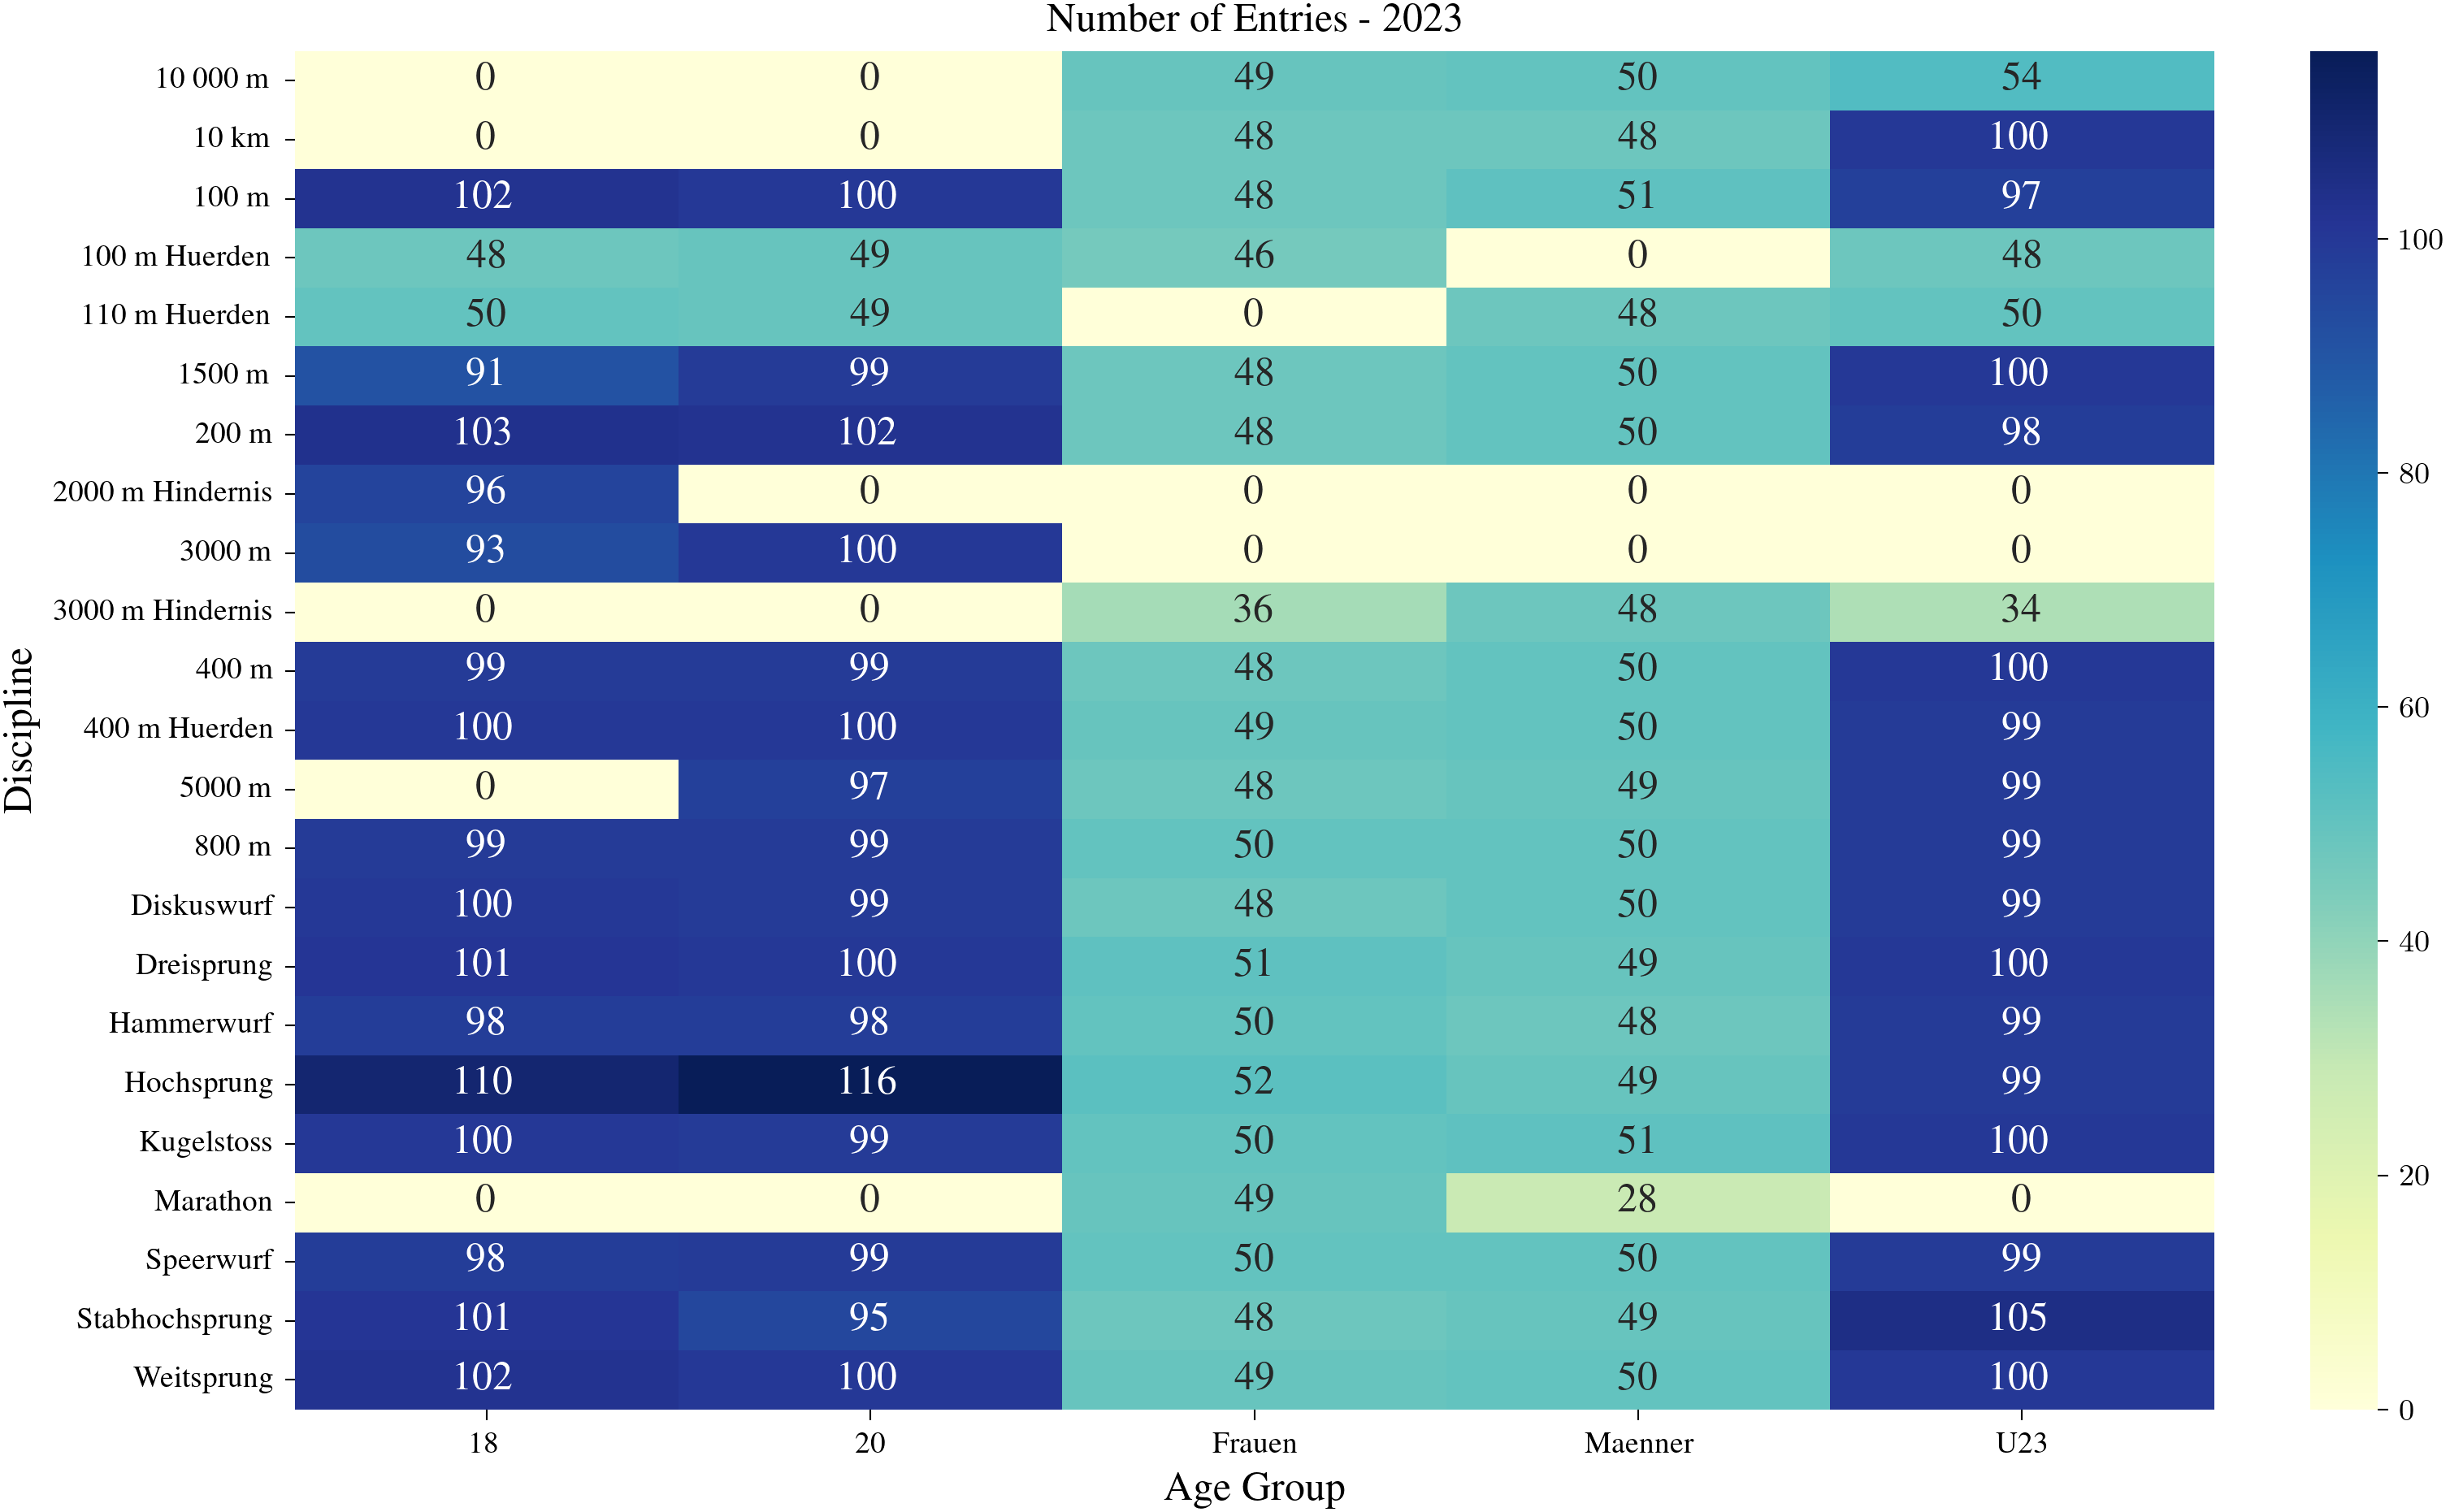

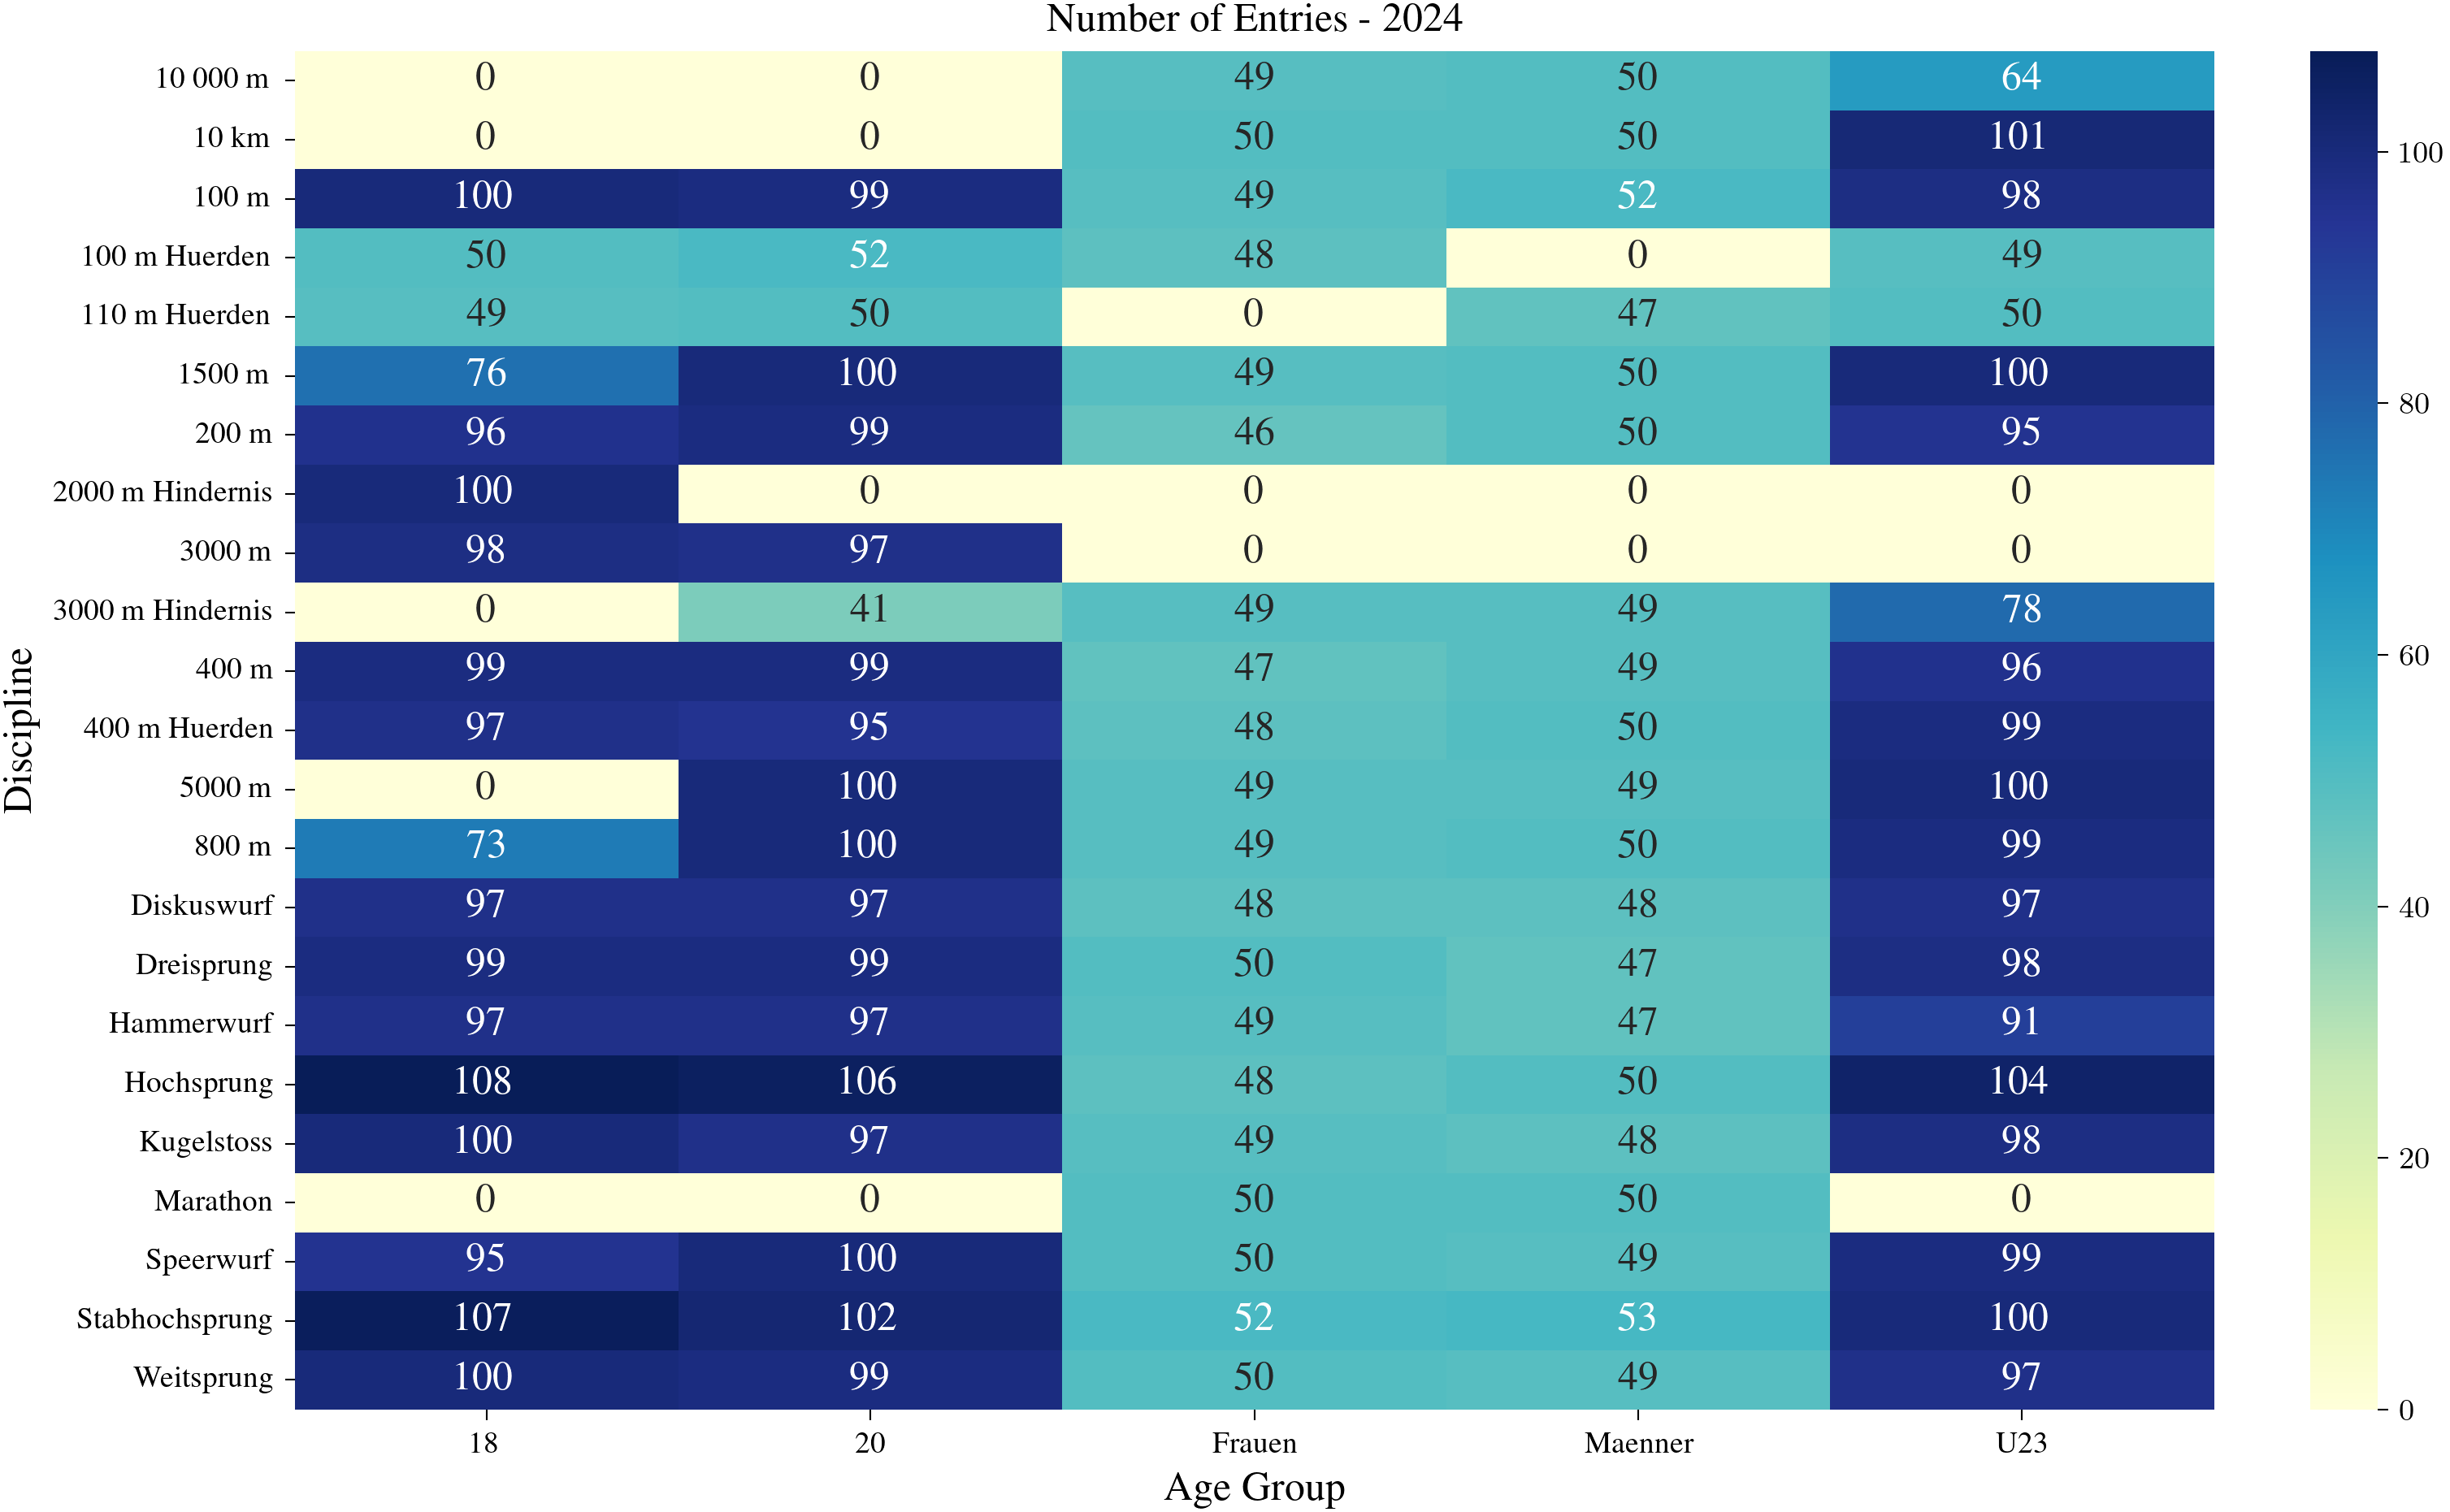

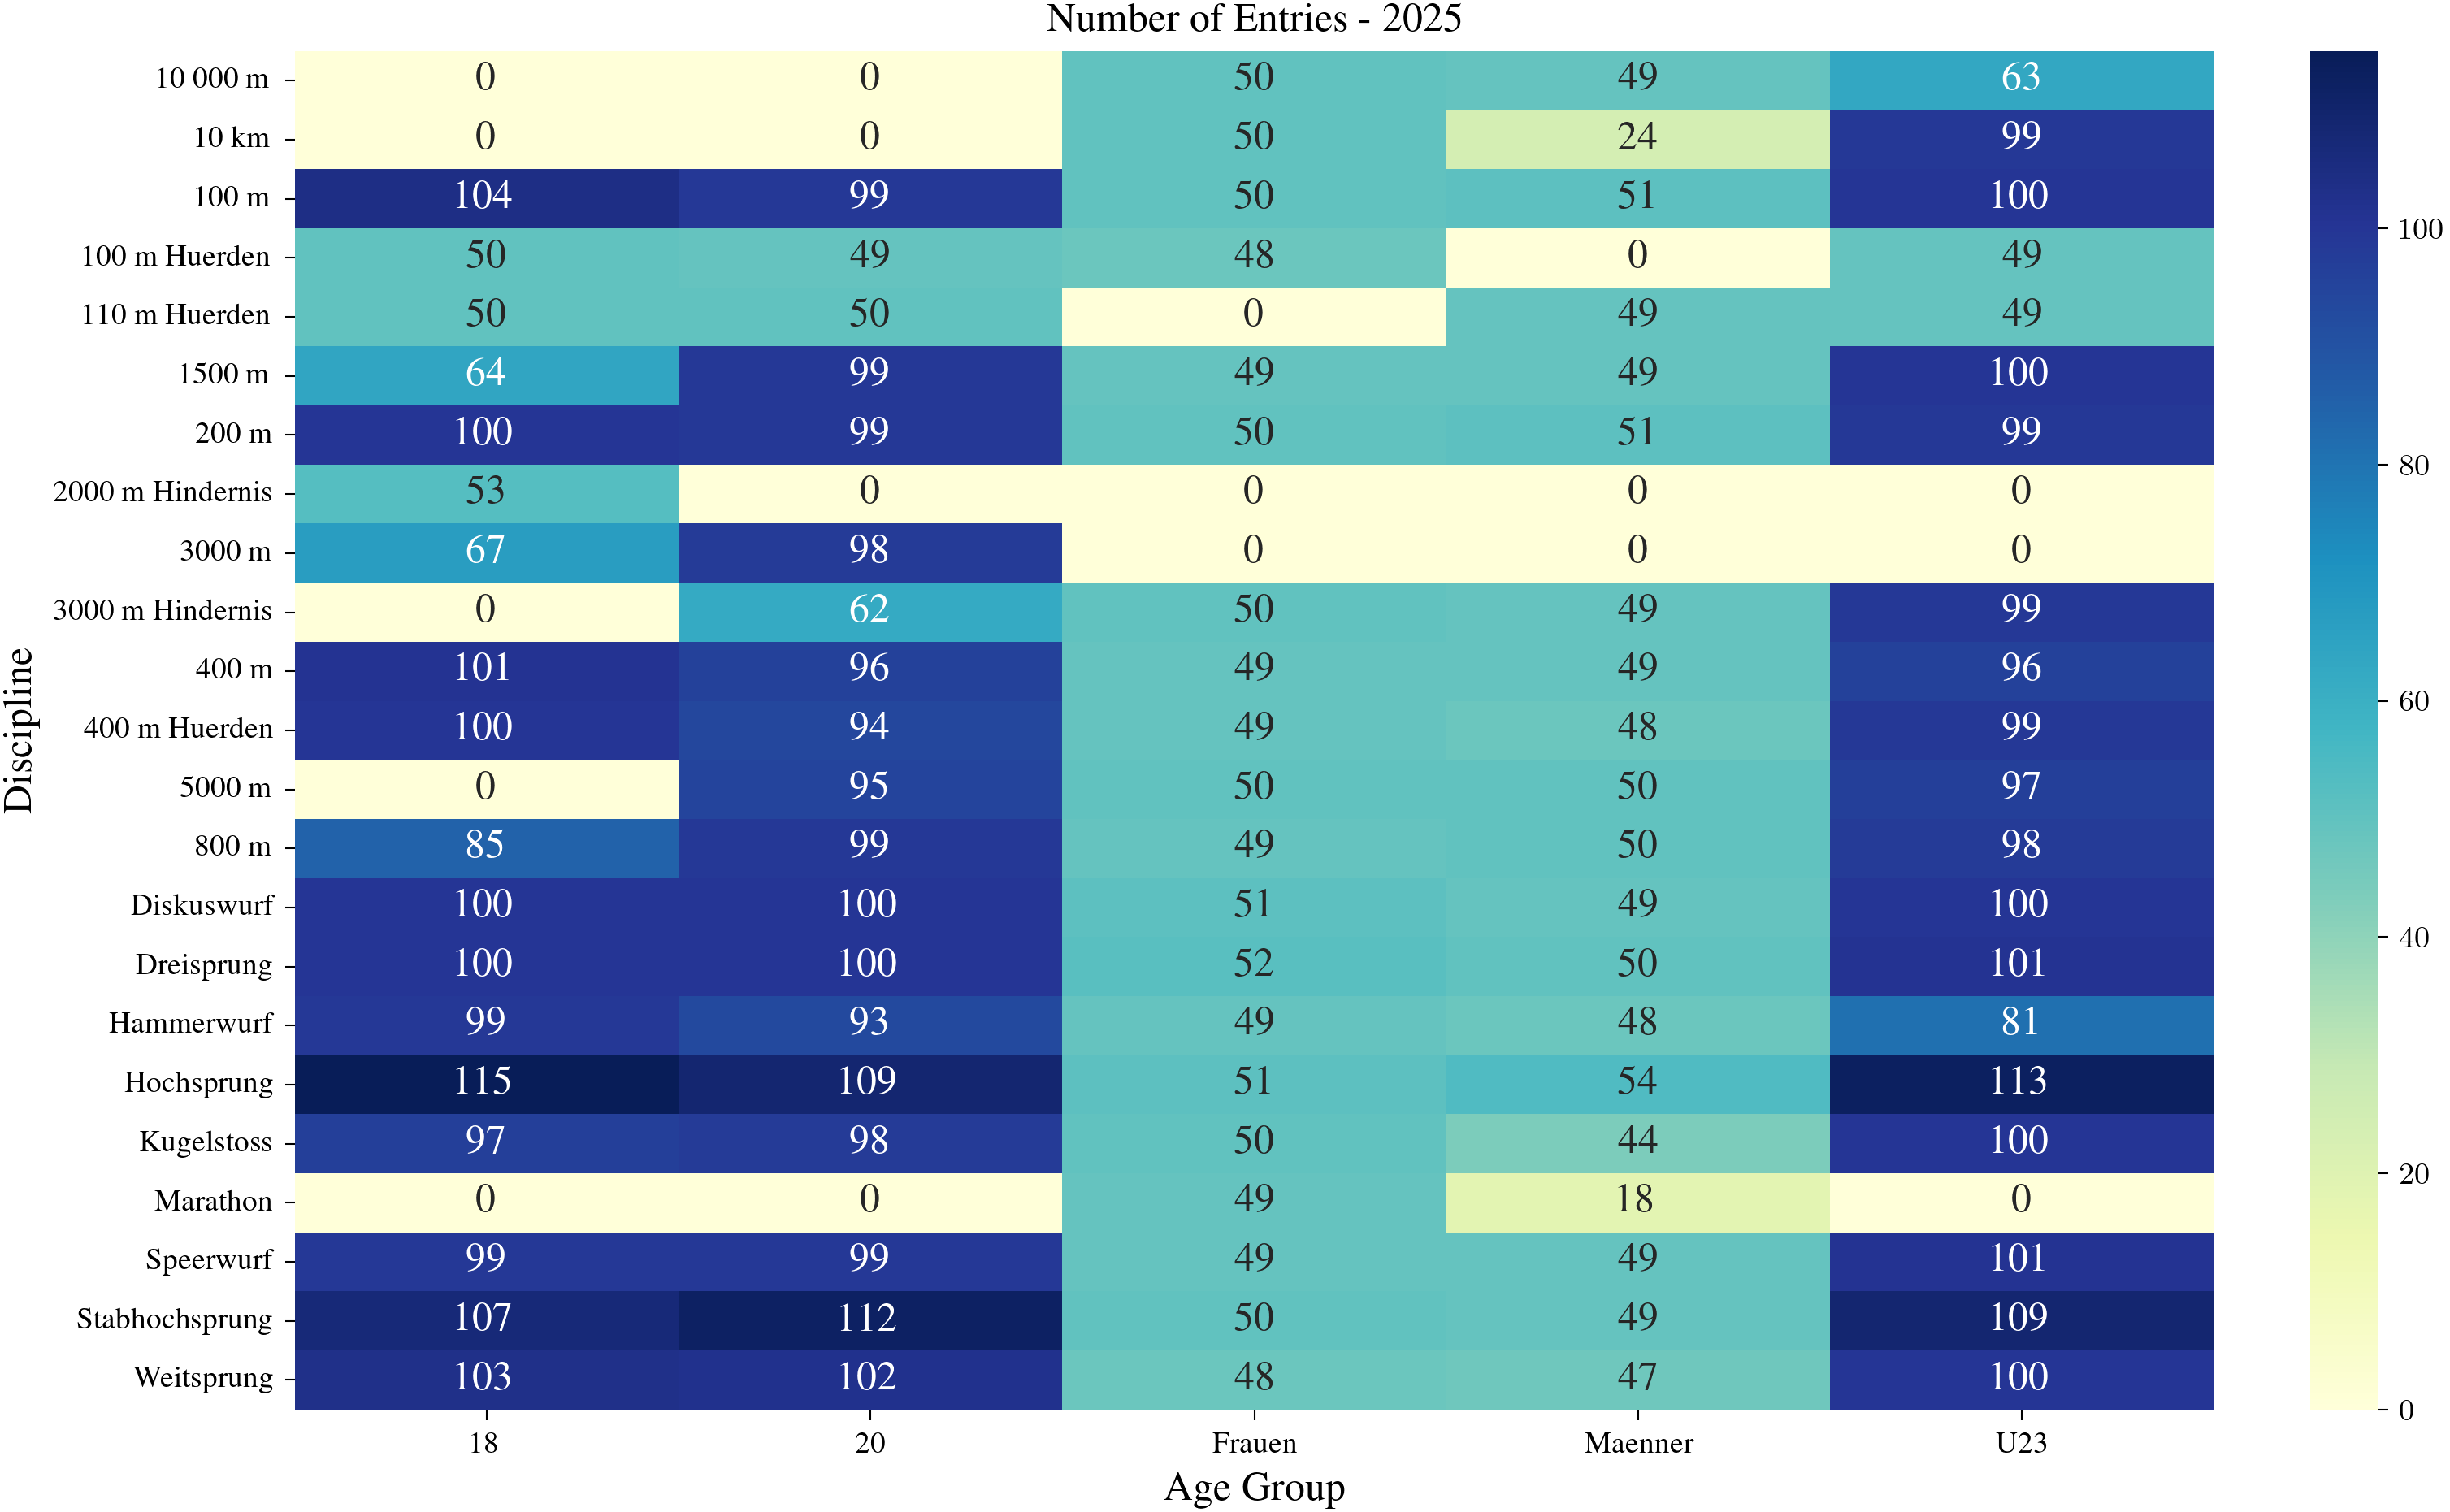

In [ ]:


import seaborn as sns
import numpy as np

years = np.sort(data['jahr'].unique())

# Plot a heatmap for every year
for year in years:
    df_year = data[data['jahr'] == year]
    
    # Pivot: Index=Discipline, Columns=AgeGroup
    table = df_year.groupby(['disziplin', 'altersklasse']).size().unstack(fill_value=0)
    
    plt.bundles.icml2024(column="full")
    with plt.rc_context(plt.increase_figsize(1.5)):
        plt.figure()
        # annot=True plots the numbers
        ax = sns.heatmap(table, annot=True, fmt="d", cmap="YlGnBu")
        
        plt.title(f"Number of Entries - {year}")
        plt.ylabel("Discipline")
        plt.xlabel("Age Group")
        plt.show()